# 16. Time series forecasting

Almost everything we have done so far assumed that the rows of the data are **independent
draws** from one distribution. A time series breaks that assumption on purpose: the
observations come in order, and each one depends on the ones before it. Yesterday's
electricity demand tells you a lot about today's; last December's passenger numbers tell you
about this December's. That dependence is the whole point — it is what makes forecasting
possible — but it also invalidates most of the evaluation machinery of notebook 5 (random
train/test splits, $k$-fold cross-validation) and it calls for models and features that
speak the language of *lags*, *trends* and *seasons*.

This notebook builds the forecasting toolbox from the ground up. We start with the anatomy
of a series (trend, seasonality, noise, stationarity, autocorrelation), then establish the
only honest way to evaluate a forecast — training on the past and testing on the future —
together with the metrics and the baselines that every forecast must be compared with. We
implement the classical methods (exponential smoothing, AR/ARIMA) from scratch, and then
turn to the machine-learning approach: lagged, rolling, calendar and Fourier features feeding
a gradient-boosting model, evaluated with rolling-origin backtesting. Sections 7–9 then do
what every method notebook in this course does: weigh the three families against each other
(including a demonstration of the failure that catches most newcomers — a boosted tree
cannot extrapolate a trend), give a tuning guide with a picture for every parameter, and
run one complete case study.

Two datasets carry the story. The monthly **airline passengers** series (1949–1960) is
*real* — Box and Jenkins' Series G, the standard test case for seasonal forecasting — and
it is the subject of the case study in section 9. Two years of hourly **electricity demand**
with temperature and holidays, for which we forecast 24 hours ahead, is *simulated*
(`course/data/make_datasets.py`): we use it because the machine-learning framing needs
thousands of observations and because knowing the true recipe lets us check what the models
recover. Every claim in this notebook says which of the two it rests on.

**Prerequisites:** notebooks 3 (time-indexed EDA), 5 (evaluation), 6 (linear regression)
and 10 (gradient boosting). `statsmodels` is optional: every method is implemented with
NumPy and pandas, and the `statsmodels` cells only cross-check our implementations when the
library is installed.

## Learning objectives

After working through this notebook you will be able to

- decompose a series into trend, seasonal and remainder components, and explain when an additive or a multiplicative model is appropriate;
- define (weak) stationarity, test for it informally, and use differencing and log transforms to obtain a stationary series;
- compute and read autocorrelation (ACF) and partial autocorrelation (PACF) functions, implemented from scratch;
- evaluate forecasts honestly with a time-ordered hold-out and rolling-origin backtesting, using MAE, RMSE, sMAPE and MASE, and explain why shuffled cross-validation is misleading;
- implement simple, Holt and Holt–Winters exponential smoothing, and fit an AR($p$) model by least squares, then use them to forecast with prediction intervals;
- engineer lag, rolling, calendar and Fourier features *without leakage* and forecast 24 hours ahead with ridge regression and gradient boosting;
- choose between direct and recursive multi-step strategies, and calibrate prediction intervals;
- name the lessons of the M-competitions and know where global models, Prophet-style models and deep learning fit in;
- say what each family of forecaster is good at and where it breaks — and in particular explain, and fix, the failure of a tree ensemble on a trending series;
- tune $\alpha$, $\beta$, $\gamma$, $\phi$, the AR order, the lag set, the rolling windows and the number of Fourier terms by backtesting, reading validation curves and a 2-D heat-map instead of guessing;
- run a complete forecasting project on a real series, from the first plot to the sentence you send to a stakeholder.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns                # (not used in this notebook)
# optimize.minimize fits the smoothing parameters; stats provides the chi-squared and normal distributions
from scipy import optimize, stats

# course helpers: set_style() applies the shared plot style, PALETTE is the list of course colours,
# load_air_passengers() returns the monthly airline series (a pandas Series indexed by month-start dates),
# load_energy_demand() reads the bundled hourly electricity CSV into a DataFrame
from course_utils import set_style, PALETTE, load_air_passengers, load_energy_demand

RANDOM_STATE = 42                          # one fixed seed so every run produces the same random numbers
rng = np.random.default_rng(RANDOM_STATE)  # seeded random-number generator for the simulations and bootstraps
set_style()                                # apply the course-wide matplotlib settings once

# statsmodels is optional: try to import it and record in HAS_SM whether that worked.
# (`# noqa: F401` tells a code checker not to complain that `sm` is never used)
try:
    import statsmodels.api as sm  # noqa: F401  (only used for optional cross-checks)
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print("statsmodels is not installed — the optional cross-checks against statsmodels are skipped "
          "(conda install -c conda-forge statsmodels).")

statsmodels is not installed — the optional cross-checks against statsmodels are skipped (conda install -c conda-forge statsmodels).


## 1. The anatomy of a time series

### 1.1 Two series

A **time series** is a sequence $y_1, y_2, \dots, y_T$ observed at regular intervals
(monthly, hourly, …). We write $T$ for the number of observations and $h$ for the
**forecast horizon**: $\hat{y}_{T+h|T}$ is the forecast of $y_{T+h}$ made with the data up to
time $T$ (the **forecast origin**). Let us load our two examples.

airline passengers: 144 monthly values, Jan 1949 – Dec 1960
energy demand:      17520 hourly values, 2022-01-01 – 2023-12-31


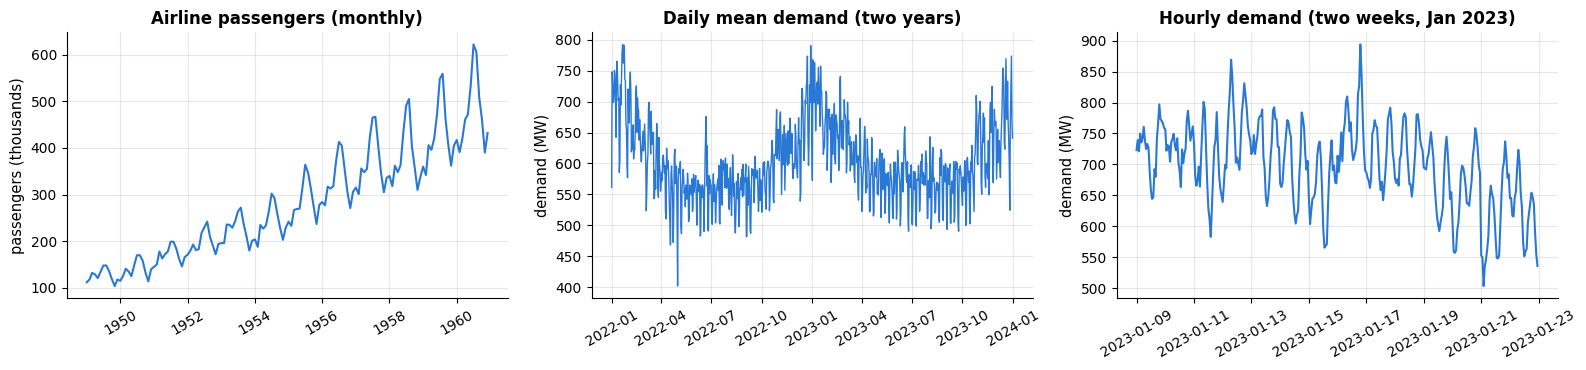

In [2]:
# air: a Series of monthly values with a DatetimeIndex; energy: a DataFrame with one row per hour.
# .set_index("timestamp") turns the timestamp column into the row index, so rows can be selected by date
air = load_air_passengers()                              # monthly totals, in thousands
energy = load_energy_demand().set_index("timestamp")     # hourly demand (MW), temperature (°C), holiday flag

# a format spec on a date uses strftime codes: %b = abbreviated month name, %Y = year, %m = month, %d = day
print(f"airline passengers: {len(air)} monthly values, {air.index[0]:%b %Y} – {air.index[-1]:%b %Y}")
print(f"energy demand:      {len(energy)} hourly values, {energy.index[0]:%Y-%m-%d} – {energy.index[-1]:%Y-%m-%d}")

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))    # one row of three panels
axes[0].plot(air.index, air.values, lw=1.5)          # x = dates, y = values; lw is the line width
axes[0].set_title("Airline passengers (monthly)")
axes[0].set_ylabel("passengers (thousands)")
# .resample("D") groups the hourly rows by calendar day, .mean() averages each day -> one value per day
daily = energy["demand_mw"].resample("D").mean()
axes[1].plot(daily.index, daily.values, lw=1)
axes[1].set_title("Daily mean demand (two years)")
axes[1].set_ylabel("demand (MW)")
# slicing a DatetimeIndex with date strings: both end dates are included (all 24 hours of each day)
two_weeks = energy.loc["2023-01-09":"2023-01-22", "demand_mw"]
axes[2].plot(two_weeks.index, two_weeks.values, lw=1.5)
axes[2].set_title("Hourly demand (two weeks, Jan 2023)")
axes[2].set_ylabel("demand (MW)")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)     # tilt the date labels so they do not overlap
plt.tight_layout()
plt.show()

Both series show the classical **components** (Hyndman & Athanasopoulos, 2021, ch. 3):

- a **trend** $T_t$ — the long-run level (passenger numbers grow; demand creeps up by a
  couple of percent per year);
- **seasonality** $S_t$ — a pattern that repeats with a fixed, known **period** $m$
  (summer peaks with $m = 12$ months; a daily double peak with $m = 24$ hours and a weekend
  dip with $m = 168$ hours — several seasonalities at once);
- **cycles** — rises and falls of *no* fixed period (business cycles, weather regimes);
  in the energy data the temperature-driven winter/summer swings act like a yearly cycle;
- the **remainder** $R_t$ — everything else: noise, holidays, outages, measurement error.

The energy series is synthetic (see `course/data/make_datasets.py`), so we know its true
recipe — a daily double peak, a 12 % weekend dip, a U-shaped temperature effect, holidays,
a 2 %/year trend and autocorrelated noise — and we can check what our models recover.

### 1.2 Additive and multiplicative decompositions

The two ways of combining the components are

$$
y_t = T_t + S_t + R_t \quad \text{(additive)}
\qquad\text{or}\qquad
y_t = T_t \times S_t \times R_t \quad \text{(multiplicative)} .
$$

The airline series is clearly multiplicative: the summer peaks grow *proportionally* with
the level. A logarithm turns a multiplicative model into an additive one,
$\log y_t = \log T_t + \log S_t + \log R_t$, which is why "take logs first" is the standard
advice for series whose variability grows with the level.

**Classical decomposition** (Hyndman & Athanasopoulos, 2021, §3.4) estimates the components
in four steps:

1. **Trend-cycle** $\hat{T}_t$: a centred moving average of length $m$. When $m$ is even, a
   plain $m$-MA is not centred on an observation, so we use the "$2 \times m$-MA" with
   weights $(\tfrac{1}{2}, 1, \dots, 1, \tfrac{1}{2}) / m$ — the first and last observation
   of the window get half weight.
2. **Detrend**: $y_t - \hat{T}_t$ (additive) or $y_t / \hat{T}_t$ (multiplicative).
3. **Seasonal indices**: average the detrended values season by season (all Januaries, all
   Februaries, …) and normalise so that the indices sum to zero (additive) or average to one
   (multiplicative). The seasonal component repeats these $m$ numbers.
4. **Remainder**: what is left, $\hat{R}_t = y_t - \hat{T}_t - \hat{S}_t$ or
   $y_t / (\hat{T}_t \hat{S}_t)$.

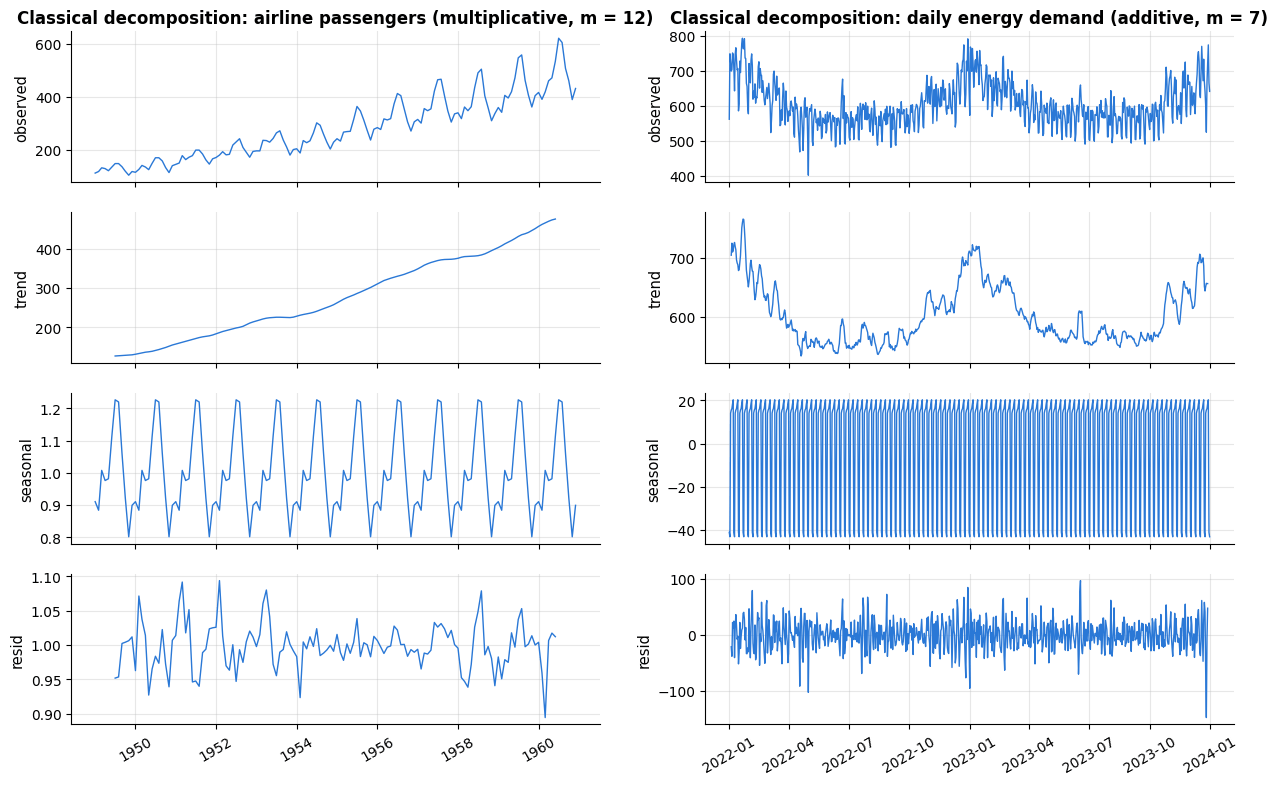

airline seasonal indices (Jan..Dec): [0.91, 0.884, 1.007, 0.976, 0.981, 1.113, 1.227, 1.22, 1.06, 0.922, 0.801, 0.899]
weekday effect on daily demand (Sat..Fri, MW): [-41.2, -43.3, 14.1, 15.5, 16.2, 18.4, 20.3]


In [3]:
def classical_decompose(series, period, model="additive"):
    """Classical trend / seasonal / remainder decomposition (Hyndman & Athanasopoulos, 2021, §3.4).

    series  a pandas Series with a time index
    period  the seasonal period m (12 for monthly data with a yearly pattern, 7 for daily data with a weekly one)
    model   "additive" (y = T + S + R) or "multiplicative" (y = T * S * R)
    Returns a DataFrame with the columns observed, trend, seasonal and resid. The trend and the remainder
    are NaN for the first and last m // 2 points, where the centred moving average does not fit.
    """
    y = series.astype(float)
    m = period
    # 1. trend-cycle: centred moving average (a 2 x m-MA when m is even)
    # np.r_[...] glues its pieces into one array: [0.5, 1, ..., 1, 0.5] / m (m + 1 weights) for even m,
    # otherwise m equal weights 1/m
    weights = np.r_[0.5, np.ones(m - 1), 0.5] / m if m % 2 == 0 else np.ones(m) / m
    half = len(weights) // 2                       # number of points lost at each end of the series
    trend = pd.Series(np.nan, index=y.index)       # start with all-NaN values on the same dates as y
    # np.convolve(a, w, mode="valid") slides the weights along a and keeps only the positions where the whole
    # window fits: len(y) - len(weights) + 1 averages, which belong to the centre positions half .. len(y) - half - 1
    trend.iloc[half:len(y) - half] = np.convolve(y.to_numpy(), weights, mode="valid")
    # 2. detrend
    detrended = y - trend if model == "additive" else y / trend
    # 3. one seasonal index per season, normalised
    season_of = np.arange(len(y)) % m                  # position within the season: 0, 1, ..., m-1, 0, 1, ...
    index = detrended.groupby(season_of).mean()        # average of all values with the same position (NaNs skipped)
    # normalise: the m indices sum to 0 (additive) or average 1 (multiplicative)
    index = index - index.mean() if model == "additive" else index / index.mean()
    # index.to_numpy()[season_of] repeats the m indices along the whole series (fancy indexing)
    seasonal = pd.Series(index.to_numpy()[season_of], index=y.index)
    # 4. remainder
    resid = y - trend - seasonal if model == "additive" else y / (trend * seasonal)
    return pd.DataFrame({"observed": y, "trend": trend, "seasonal": seasonal, "resid": resid})


dec_air = classical_decompose(air, period=12, model="multiplicative")
dec_daily = classical_decompose(daily, period=7, model="additive")      # weekly pattern of daily demand

# 4 rows (one per component) x 2 columns (one per series); sharex="col" gives each column one common time axis
fig, axes = plt.subplots(4, 2, figsize=(15, 9), sharex="col")
# enumerate gives the column number j; each list item unpacks into (decomposition DataFrame, title)
for j, (dec, name) in enumerate([(dec_air, "airline passengers (multiplicative, m = 12)"),
                                 (dec_daily, "daily energy demand (additive, m = 7)")]):
    for i, comp in enumerate(["observed", "trend", "seasonal", "resid"]):
        axes[i, j].plot(dec.index, dec[comp], lw=1)
        axes[i, j].set_ylabel(comp)
    axes[0, j].set_title(f"Classical decomposition: {name}")
    axes[3, j].tick_params(axis="x", rotation=30)
plt.show()

# the seasonal column repeats every m values, so its first m entries are the indices themselves
# (the airline series starts in January; the energy series starts on a Saturday)
print("airline seasonal indices (Jan..Dec):", dec_air["seasonal"].iloc[:12].round(3).tolist())
print("weekday effect on daily demand (Sat..Fri, MW):", dec_daily["seasonal"].iloc[:7].round(1).tolist())

July and August carry about 22 % more passengers than an average month, November about
20 % fewer, and the residual variation is only a few percent — the decomposition explains
almost everything. For the daily energy series the weekly index recovers the weekend dip of
about 40 MW (the series starts on a Saturday, so the first two indices are the weekend; the
seasonal panel is a dense sawtooth because 104 weeks are squeezed into it), and the
*trend-cycle* panel absorbs the temperature-driven yearly swing, because a 7-day moving
average is far too short to remove a yearly pattern. Classical decomposition has known
weaknesses — the trend is undefined at the ends, the seasonal pattern is forced to be
identical every year, and outliers distort it. **STL** (Cleveland et al., 1990) fixes these
with locally weighted regression and is the modern default (`statsmodels.tsa.seasonal.STL`).

In [4]:
if HAS_SM:
    from statsmodels.tsa.seasonal import seasonal_decompose, STL
    sm_dec = seasonal_decompose(air, model="multiplicative", period=12)   # statsmodels' classical decomposition
    # np.allclose(a, b, atol=1e-8) is True when every entry agrees to within 1e-8
    same = np.allclose(sm_dec.seasonal.to_numpy(), dec_air["seasonal"].to_numpy(), atol=1e-8)
    print(f"seasonal component identical to statsmodels.seasonal_decompose: {same}")
    # STL decomposes with locally weighted regression (loess); it is additive, so we give it the logs
    stl = STL(np.log(air), period=12).fit()
    print(f"STL on log(passengers): remainder std = {float(stl.resid.std()):.4f}")
else:
    print("statsmodels not available — skipping the seasonal_decompose / STL cross-check.")

statsmodels not available — skipping the seasonal_decompose / STL cross-check.


### 1.3 Stationarity and differencing

Most classical models assume that the series they see is **stationary**: its statistical
properties do not change over time. Formally, $\{y_t\}$ is *weakly stationary* if
$\mathbb{E}[y_t] = \mu$ and $\operatorname{Var}[y_t] = \sigma^2$ are constant and the
autocovariance $\operatorname{Cov}(y_t, y_{t-k})$ depends only on the lag $k$. A series with
a trend or with seasonality is not stationary (its mean moves); a series whose variance grows
with its level is not stationary either.

The standard remedies are transformations that *remove* the non-stationary structure and
that we can *undo* after forecasting:

- a **log** (or Box–Cox) transform stabilises a variance that grows with the level;
- **first differencing** $y'_t = y_t - y_{t-1}$ removes a trend (a random walk becomes white noise);
- **seasonal differencing** $y'_t = y_t - y_{t-m}$ removes a stable seasonal pattern;
- both can be combined, and the differenced series can be integrated back:
  $y_{T+h} = y_{T+h-m} + y'_{T+h}$.

> **Warning.** Difference only as much as necessary. Every difference amplifies noise and
> introduces negative autocorrelation at lag one; over-differenced series are harder, not
> easier, to model.

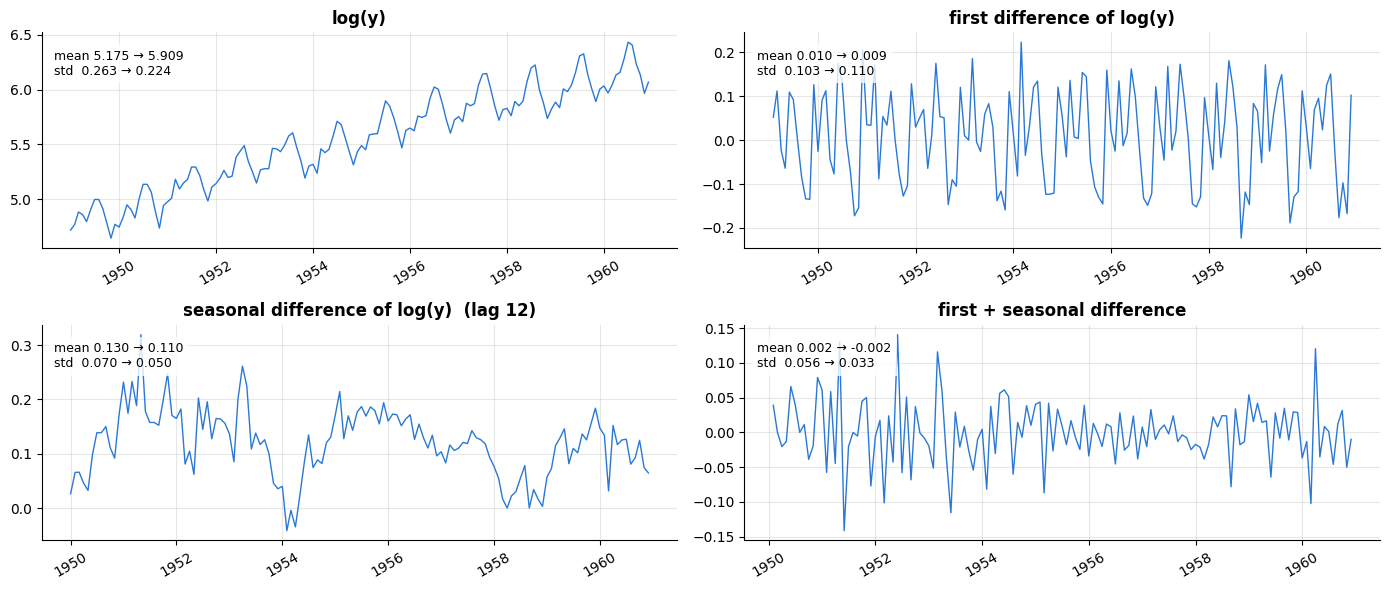

In [5]:
log_air = np.log(air)              # element-wise natural log; the result is still a Series with the same dates
# .diff(k) returns y_t - y_{t-k} (k = 1 by default); the first k values become NaN
transforms = {
    "log(y)": log_air,
    "first difference of log(y)": log_air.diff(),
    "seasonal difference of log(y)  (lag 12)": log_air.diff(12),
    "first + seasonal difference": log_air.diff(12).diff(),     # seasonal difference, then a first difference of that
}
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
# axes.ravel() flattens the 2 x 2 grid of panels into a 1-D array, so zip can pair each panel with one transform
for ax, (name, s) in zip(axes.ravel(), transforms.items()):
    ax.plot(s.index, s.values, lw=1)
    ax.set_title(name)
    ax.tick_params(axis="x", rotation=30)
    # split the series (without the NaNs from differencing) into its first and its second half
    first, second = s.dropna().iloc[:len(s.dropna()) // 2], s.dropna().iloc[len(s.dropna()) // 2:]
    # transform=ax.transAxes: the position (0.02, 0.92) is a fraction of the panel, not a data coordinate;
    # bbox draws a semi-transparent white box behind the text
    ax.text(0.02, 0.92, f"mean {first.mean():.3f} → {second.mean():.3f}\nstd  {first.std():.3f} → {second.std():.3f}",
            transform=ax.transAxes, fontsize=9, va="top", bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))
plt.tight_layout()
plt.show()

if HAS_SM:
    from statsmodels.tsa.stattools import adfuller     # augmented Dickey-Fuller unit-root test
    for name in ["log(y)", "seasonal difference of log(y)  (lag 12)"]:
        # adfuller returns a tuple (statistic, p-value, lags used, ...); [:2] keeps the first two.
        # autolag="AIC" picks the number of lagged differences in the test regression by AIC
        stat, pvalue = adfuller(transforms[name].dropna(), autolag="AIC")[:2]
        # {name:42s} pads the name to 42 characters so the numbers line up; {stat:6.2f} = width 6, 2 decimals
        print(f"ADF test on {name:42s} statistic = {stat:6.2f}, p-value = {pvalue:.3f}")

The annotation in each panel compares the mean and standard deviation of the first and the
second half of the series — a crude but useful stationarity check. Taking logs equalises the
amplitude of the seasonal swings; the seasonal difference of the logs (annual growth rates)
has a roughly constant mean of about 12 % per year and looks stationary. The formal tool is
the **augmented Dickey–Fuller (ADF) test** (Dickey & Fuller, 1979), whose null hypothesis is
"the series has a unit root, i.e. is *not* stationary"; a small $p$-value supports
stationarity. It runs above when `statsmodels` is installed.

### 1.4 Autocorrelation and partial autocorrelation

The **autocorrelation function (ACF)** measures how strongly the series is correlated with
its own past at each lag $k$:

$$
r_k \;=\; \frac{\sum_{t=k+1}^{T} (y_t - \bar{y})(y_{t-k} - \bar{y})}{\sum_{t=1}^{T} (y_t - \bar{y})^2},
\qquad k = 0, 1, 2, \dots
$$

For white noise all $r_k$ ($k \ge 1$) are approximately $\mathcal{N}(0, 1/T)$, so values
outside $\pm 1.96/\sqrt{T}$ are "significant". A trending series has a slowly decaying ACF;
a seasonal series has ACF peaks at multiples of $m$.

The **partial autocorrelation function (PACF)** at lag $k$ is the correlation between $y_t$
and $y_{t-k}$ *after removing the effect of the intermediate lags* $1, \dots, k-1$. The most
transparent definition is through regression: fit
$y_t = c + \phi_{k1} y_{t-1} + \dots + \phi_{kk} y_{t-k}$ by least squares; the PACF at lag
$k$ is the last coefficient $\phi_{kk}$. (The Durbin–Levinson recursion and the Yule–Walker
equations give the same quantity for a stationary series.) The PACF answers "how much does
lag $k$ add once lags $1, \dots, k-1$ are already in the model?", which is exactly what we
need to choose the order of an autoregressive model in section 3.4.

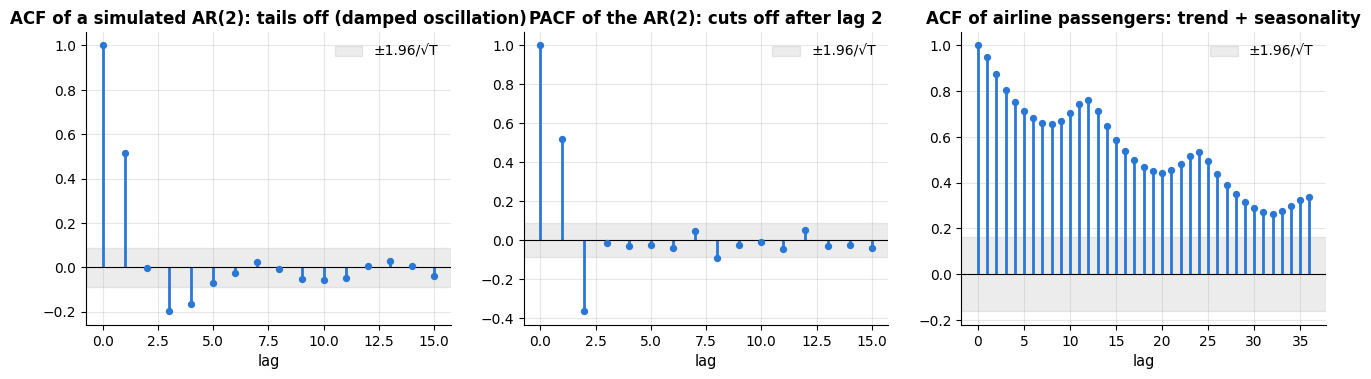

In [6]:
def acf(x, nlags):
    """Sample autocorrelation r_0..r_nlags (biased estimator, as in statsmodels' default).

    x      a 1-D sequence of observations
    nlags  the largest lag k to compute
    Returns an array of length nlags + 1 (r_0 = 1). "Biased" means every lag is divided by the same
    full sum of squares, as in the formula above.
    """
    x = np.asarray(x, dtype=float)         # accept lists, Series or arrays
    x = x - x.mean()                       # centre the series
    denom = np.sum(x * x)                  # sum of squared deviations: the denominator of every r_k
    # x[k:] * x[:-k] pairs every y_t with y_{t-k} (both slices have length len(x) - k); r_0 = 1 by definition
    return np.array([1.0] + [np.sum(x[k:] * x[:-k]) / denom for k in range(1, nlags + 1)])


def pacf(x, nlags):
    """Partial autocorrelation via least-squares regressions on lags 1..k (the 'OLS' method).

    For each k, regress x_t on an intercept and x_{t-1}, ..., x_{t-k} and keep the coefficient of the
    last lag. Returns an array of length nlags + 1 (entry 0 is 1).
    """
    x = np.asarray(x, dtype=float)
    out = [1.0]
    for k in range(1, nlags + 1):
        # design matrix with one row per target x_k .. x_{n-1}: a column of ones (the intercept), then for each
        # j the slice x[k-j : n-j], i.e. the series shifted by j (column j holds x_{t-j}); shape (n - k, k + 1)
        lags = np.column_stack([np.ones(len(x) - k)] + [x[k - j:len(x) - j] for j in range(1, k + 1)])
        beta = np.linalg.lstsq(lags, x[k:], rcond=None)[0]   # least-squares fit; [0] picks the coefficients
        out.append(beta[-1])                                 # the coefficient of lag k = the PACF at lag k
    return np.array(out)


def plot_correlogram(values, ax, title, n_obs):
    """Draw a correlogram on `ax`: one vertical stick per lag plus the ±1.96/√T white-noise band.

    values  the ACF or PACF values for lags 0, 1, 2, ...
    n_obs   T, the length of the series the values come from (it sets the width of the band)
    """
    lags = np.arange(len(values))
    ax.vlines(lags, 0, values, color=PALETTE[0], lw=2)            # vlines(x, ymin, ymax): one vertical stick per lag
    ax.scatter(lags, values, color=PALETTE[0], s=18, zorder=3)    # a dot on each stick; zorder=3 draws it on top
    band = 1.96 / np.sqrt(n_obs)                                  # approximate 95 % range of r_k for white noise
    ax.axhspan(-band, band, color="gray", alpha=0.15, label="±1.96/√T")   # a shaded horizontal stripe
    ax.axhline(0, color="black", lw=0.8)                          # a horizontal line across the whole panel
    ax.set_xlabel("lag")
    ax.set_title(title)
    ax.legend(loc="upper right")


# A simulated AR(2) process: y_t = 0.6 y_{t-1} - 0.3 y_{t-2} + e_t
n_sim = 500
eps = rng.normal(size=n_sim)          # the white-noise shocks e_t (standard normal)
ar2 = np.zeros(n_sim)                 # the first two values stay 0 as starting values
for t in range(2, n_sim):
    ar2[t] = 0.6 * ar2[t - 1] - 0.3 * ar2[t - 2] + eps[t]

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
plot_correlogram(acf(ar2, 15), axes[0], "ACF of a simulated AR(2): tails off (damped oscillation)", n_sim)
plot_correlogram(pacf(ar2, 15), axes[1], "PACF of the AR(2): cuts off after lag 2", n_sim)
plot_correlogram(acf(air, 36), axes[2], "ACF of airline passengers: trend + seasonality", len(air))   # 36 lags = 3 years
plt.show()

if HAS_SM:
    # "import ... as ..." renames on import, so statsmodels' versions do not overwrite our acf and pacf
    from statsmodels.tsa.stattools import acf as sm_acf, pacf as sm_pacf
    print("ACF  agrees with statsmodels:", np.allclose(acf(ar2, 15), sm_acf(ar2, nlags=15), atol=1e-8))
    # method="ols" is the same regression-based PACF as ours; [1:] drops lag 0
    print("PACF (ours vs statsmodels, method='ols'), lags 1-4:",
          pacf(ar2, 4)[1:].round(3), sm_pacf(ar2, nlags=4, method="ols")[1:].round(3))

The simulated AR(2) shows the textbook signature: an ACF that *tails off* (here as a damped
oscillation, because the second coefficient is negative) and a PACF that is significant at
lags 1 and 2 and then drops inside the noise band — the PACF "cuts
off" at the autoregressive order. The airline ACF never decays (trend) and has bumps at
lags 12, 24 and 36 (seasonality): it is the picture of a non-stationary series, and it
tells us to difference before fitting anything.

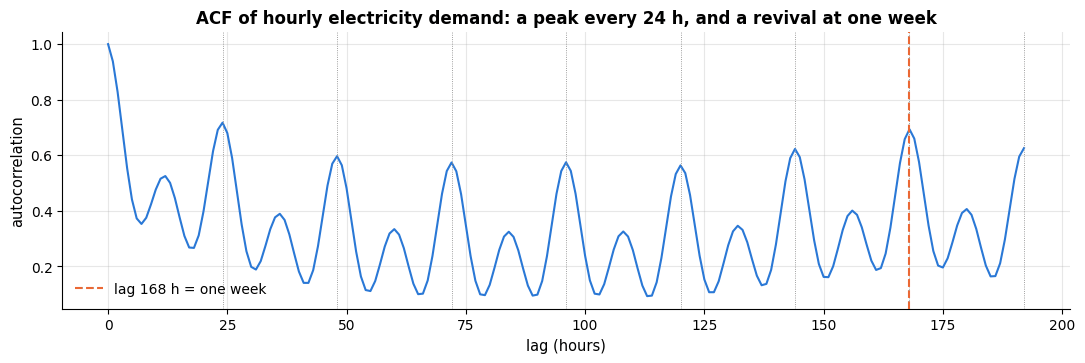

r(1 h) = 0.938   r(24 h) = 0.717   r(48 h) = 0.596   r(168 h) = 0.693


In [7]:
demand = energy["demand_mw"]                    # the hourly demand column as a Series
r_energy = acf(demand.to_numpy(), 24 * 8)       # ACF up to 8 days = 192 hourly lags
fig, ax = plt.subplots(figsize=(13, 3.6))
ax.plot(np.arange(len(r_energy)), r_energy, lw=1.5)    # 193 lags, drawn as a line instead of sticks
for k in range(24, 24 * 8 + 1, 24):             # a dotted vertical line at every multiple of 24 h
    ax.axvline(k, color="gray", lw=0.6, ls=":")
ax.axvline(168, color=PALETTE[1], lw=1.5, ls="--", label="lag 168 h = one week")
ax.set_xlabel("lag (hours)")
ax.set_ylabel("autocorrelation")
ax.set_title("ACF of hourly electricity demand: a peak every 24 h, and a revival at one week")
ax.legend()
plt.show()
print(f"r(1 h) = {r_energy[1]:.3f}   r(24 h) = {r_energy[24]:.3f}   r(48 h) = {r_energy[48]:.3f}   r(168 h) = {r_energy[168]:.3f}")

The hourly demand is strongly autocorrelated at lag 1 (adjacent hours are alike) and at
every multiple of 24 hours (the daily shape), with the daily peaks slowly fading — except at
168 hours, where the correlation jumps back up almost to the lag-24 level: the same hour one
week ago shares both the hour-of-day and the day-of-week effect. These lags are exactly the
features we will engineer in section 4.

## 2. Evaluating forecasts honestly

### 2.1 The forecast origin and the train/test split in time

In notebook 5 we estimated the generalisation error by holding out a random subset of rows.
For a time series the analogous question is *"how well do I predict the future from the
past?"*, and the only honest answer comes from a split **in time**: fit on $y_1, \dots, y_T$,
forecast $y_{T+1}, \dots, y_{T+H}$, compare with what actually happened. The forecast
horizon $h$ matters — one step ahead is much easier than 24 steps ahead — so the evaluation
must be done at the horizon that the application needs.

A single origin $T$ is a single, noisy sample of forecasting performance (was the test
period unusually calm? did it contain a holiday?). The remedy is **rolling-origin
evaluation** (also called time-series cross-validation or backtesting; Hyndman &
Athanasopoulos, 2021, §5.10): repeat the split for many origins
$T_1 < T_2 < \dots$, each time fitting on everything up to the origin and forecasting the
following $H$ steps, then average the errors. The training window can grow (**expanding**
window, the usual choice) or slide (**rolling** window of fixed length, useful when old
data have become irrelevant).

```text
expanding window, H = 3 steps per origin:

origin 1:  train ########........          test ...
origin 2:  train ###########.....             test ...
origin 3:  train ##############..                test ...
                 ------------------------------> time
```

### 2.2 Metrics

Let $e_{T+h} = y_{T+h} - \hat{y}_{T+h|T}$ be the forecast errors over a test window of $H$
steps. The usual scale-dependent metrics are

$$
\text{MAE} = \frac{1}{H}\sum_{h=1}^{H} |e_{T+h}|, \qquad
\text{RMSE} = \sqrt{\frac{1}{H}\sum_{h=1}^{H} e_{T+h}^2},
$$

MAE is minimised by the median forecast, RMSE by the mean forecast, and RMSE punishes large
misses more. Both are in the units of $y$, which is easy to interpret but makes it
impossible to compare across series of different scales. Percentage errors try to fix that:

$$
\text{MAPE} = \frac{100\%}{H}\sum_{h} \frac{|e_{T+h}|}{|y_{T+h}|}, \qquad
\text{sMAPE} = \frac{100\%}{H}\sum_{h} \frac{2\,|e_{T+h}|}{|y_{T+h}| + |\hat{y}_{T+h|T}|} .
$$

MAPE explodes when $y_t$ is near zero and penalises over-forecasts more than
under-forecasts; the *symmetric* MAPE is bounded by 200 % and is the headline metric of the
M3 and M4 competitions, but it is still undefined at $y = \hat{y} = 0$ and not truly
symmetric. Hyndman & Koehler (2006) proposed a cleaner scale-free measure, the **mean
absolute scaled error**: divide the MAE by the in-sample MAE of the seasonal-naive forecast,

$$
\text{MASE} \;=\; \frac{\frac{1}{H}\sum_{h}|e_{T+h}|}{\frac{1}{T-m}\sum_{t=m+1}^{T}|y_t - y_{t-m}|} .
$$

MASE $< 1$ means "better than the naive forecast was on the training data"; it is defined
for any series, symmetric, and comparable across series. It is the primary metric of this
notebook (and of the M4 competition, alongside sMAPE).

In [8]:
def mae(y, f):
    """Mean absolute error between the actual values y and the forecasts f (array-likes of equal length)."""
    # np.asarray(..., float) turns lists or Series into float arrays; float(...) returns a plain Python number
    return float(np.mean(np.abs(np.asarray(y, float) - np.asarray(f, float))))


def rmse(y, f):
    """Root mean squared error: like MAE, but large misses count more."""
    return float(np.sqrt(np.mean((np.asarray(y, float) - np.asarray(f, float)) ** 2)))


def mape(y, f):
    """Mean absolute percentage error, in % (undefined when an actual value is 0)."""
    y, f = np.asarray(y, float), np.asarray(f, float)
    return float(100 * np.mean(np.abs(y - f) / np.abs(y)))


def smape(y, f):
    """Symmetric MAPE, in %: each error relative to the mean of |actual| and |forecast| (at most 200 %)."""
    y, f = np.asarray(y, float), np.asarray(f, float)
    return float(100 * np.mean(2 * np.abs(y - f) / (np.abs(y) + np.abs(f))))


def mase(y, f, y_train, m=1):
    """MAE scaled by the in-sample MAE of the seasonal-naive forecast with period m (Hyndman & Koehler, 2006).

    y, f     the actual values and the forecasts over the test window
    y_train  the training series, used only for the scale
    m        the seasonal period (m = 1 scales by the plain naive forecast)
    A value below 1 means the forecast beats the in-sample error of the seasonal-naive forecast.
    """
    y_train = np.asarray(y_train, float)
    # y_train[m:] - y_train[:-m] = y_t - y_{t-m} for every t from m on: the seasonal-naive errors
    scale = np.mean(np.abs(y_train[m:] - y_train[:-m]))
    return mae(y, f) / scale


def score_table(y_true, forecasts, y_train, m):
    """Table of MAE, RMSE, sMAPE and MASE with one row per forecast.

    y_true      the actual test values
    forecasts   dict {name: forecast array}
    y_train, m  the training series and seasonal period used for the MASE scale
    """
    # dict comprehension {name: {metric: value}}, one entry per forecast
    rows = {name: {"MAE": mae(y_true, f), "RMSE": rmse(y_true, f), "sMAPE %": smape(y_true, f),
                   "MASE": mase(y_true, f, y_train, m)} for name, f in forecasts.items()}
    # a DataFrame built from a dict of dicts has one column per outer key; .T flips it to one row per forecast
    return pd.DataFrame(rows).T.round(2)

### 2.3 Baselines: the forecasts you must beat

Sophisticated models are worthless unless they beat the simple ones, and in forecasting the
simple ones are embarrassingly hard to beat (Makridakis, Spiliotis & Assimakopoulos, 2020).
Four baselines belong in every comparison:

| Baseline | Forecast $\hat{y}_{T+h|T}$ | Optimal for |
|---|---|---|
| **mean** | $\bar{y}$ | i.i.d. data (no dynamics) |
| **naive** (persistence) | $y_T$ | a random walk |
| **seasonal naive** | $y_{T+h-m(k+1)}$, $k = \lfloor (h-1)/m \rfloor$ — the value from one season ago | a seasonal random walk |
| **drift** | $y_T + h\,\frac{y_T - y_1}{T-1}$ — extrapolate the average change | a random walk with drift |

,MAE,RMSE,sMAPE %,MASE
mean,206.34,219.44,57.58,7.22
naive,115.25,137.33,27.75,4.03
seasonal naive,71.25,76.99,17.01,2.49
drift,91.62,115.70,21.20,3.21


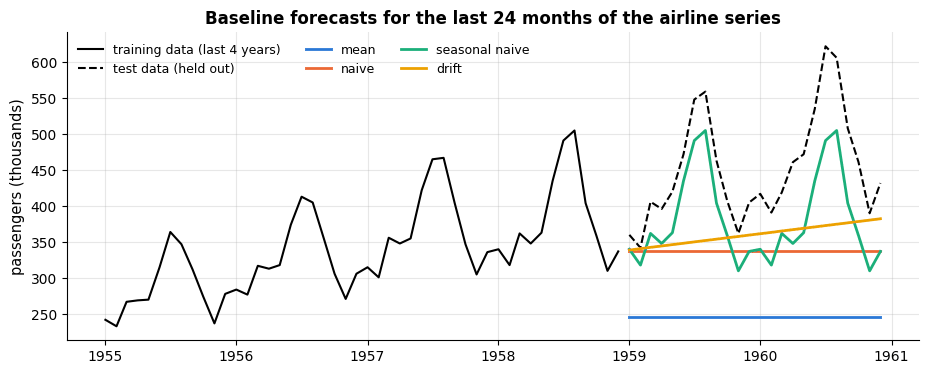

In [9]:
def mean_forecast(y, h, **kw):
    """Mean forecast: the average of the whole history y, repeated for the h future steps.

    Every forecaster below has the form f(history, h, **kw) and returns an array of h forecasts;
    **kw collects (and ignores) extra keyword arguments such as m, so all of them can be called alike.
    """
    return np.repeat(np.mean(y), h)       # np.repeat(value, h): an array holding the value h times


def naive(y, h, **kw):
    """Naive (persistence) forecast: the last observation, repeated h times."""
    return np.repeat(y[-1], h)


def seasonal_naive(y, h, m=12, **kw):
    """Seasonal-naive forecast: every future step copies the last observed value at the same point of the season.

    m  the seasonal period (12 for monthly data)
    """
    # y[len(y) - m:] is the last season; step i (counted from 0) takes its (i % m)-th value, so it repeats
    return np.array([y[len(y) - m + (i % m)] for i in range(h)])


def drift(y, h, **kw):
    """Drift forecast: the last value plus h times the average change per step over the history."""
    slope = (y[-1] - y[0]) / (len(y) - 1)      # average change per step from the first to the last observation
    return y[-1] + slope * np.arange(1, h + 1)   # 1, 2, ..., h steps ahead


H = 24                                      # hold out the last two years (1959-1960)
y_air = air.to_numpy(dtype=float)           # the Series as a plain float array (the forecasters work on arrays)
y_train, y_test = y_air[:-H], y_air[-H:]    # everything except the last 24 months / the last 24 months
t_train, t_test = air.index[:-H], air.index[-H:]   # the matching dates, for plotting

# each baseline sees only the training data and forecasts the 24 test months
baseline_forecasts = {"mean": mean_forecast(y_train, H), "naive": naive(y_train, H),
                      "seasonal naive": seasonal_naive(y_train, H, m=12), "drift": drift(y_train, H)}
display(score_table(y_test, baseline_forecasts, y_train, m=12))   # display() renders a DataFrame as a table in Jupyter

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_train[-48:], y_train[-48:], color="black", lw=1.5, label="training data (last 4 years)")
ax.plot(t_test, y_test, color="black", lw=1.5, ls="--", label="test data (held out)")
for (name, f), c in zip(baseline_forecasts.items(), PALETTE):     # pair each (name, forecast) with one colour
    ax.plot(t_test, f, lw=2, color=c, label=name)
ax.set_title("Baseline forecasts for the last 24 months of the airline series")
ax.set_ylabel("passengers (thousands)")
ax.legend(ncol=3, fontsize=9)               # legend entries in three columns
plt.show()

The seasonal-naive forecast is the one to beat (MASE 2.5 here — it is worse than the
in-sample scale because the series keeps growing, so last year's values are systematically
too low). Note how the mean forecast is absurd for a trending series and how the drift
forecast has the right level but no seasonality. Every method in the rest of this notebook
is judged against this table.

### 2.4 Rolling-origin backtesting

Let us write the backtest loop once, generically: a *forecaster* is any function
`f(y_history, h, **kwargs) -> array of length h`, and the backtest calls it at a sequence of
origins with an expanding window, collecting the errors of each origin.

In [10]:
def rolling_origin_backtest(y, forecaster, horizon, n_origins, step=1, min_train=None, **kwargs):
    """Expanding-window backtest. Returns a DataFrame with one row per origin.

    y           the series to backtest on
    forecaster  any function f(history, h, **kwargs) that returns h forecasts
    horizon     number of steps forecast at every origin
    n_origins   number of forecast origins, `step` observations apart
    min_train   length of the first training window; by default it is chosen so that the forecast
                window of the last origin ends exactly at the end of y
    **kwargs    passed on to the forecaster; kwargs["m"] (default 1) is also the period of the MASE
    The result has the columns MAE and MASE, indexed by the origin (the length of the training window).
    """
    y = np.asarray(y, float)
    min_train = min_train or len(y) - horizon - (n_origins - 1) * step   # `a or b` gives b when a is None
    rows = []
    for k in range(n_origins):
        end = min_train + k * step              # forecast origin: train on y[:end]
        f = forecaster(y[:end], horizon, **kwargs)     # the forecaster only ever sees the past
        actual = y[end:end + horizon]                  # what really happened in the next `horizon` steps
        # kwargs.get("m", 1) reads m if it was passed and falls back to 1 otherwise
        rows.append({"origin": end, "MAE": mae(actual, f), "MASE": mase(actual, f, y[:end], kwargs.get("m", 1))})
    return pd.DataFrame(rows).set_index("origin")      # a list of dicts becomes one row per dict


results = {}
for name, fc in [("naive", naive), ("seasonal naive", seasonal_naive), ("drift", drift)]:
    # 8 origins, 6 months apart, each forecasting 12 months; m=12 reaches the forecaster too (naive and drift ignore it)
    bt = rolling_origin_backtest(y_train, fc, horizon=12, n_origins=8, step=6, m=12)
    # summarise the 8 origins: the mean and the spread (std) of the MAE, and the mean MASE
    results[name] = {"MAE (mean over origins)": bt["MAE"].mean(), "MAE (std)": bt["MAE"].std(),
                     "MASE (mean over origins)": bt["MASE"].mean()}
print("8 origins, 12-month horizon, training data only (the test years stay untouched):")
display(pd.DataFrame(results).T.round(2))

8 origins, 12-month horizon, training data only (the test years stay untouched):


,MAE (mean over origins),MAE (std),MASE (mean over origins)
naive,49.07,13.73,1.81
seasonal naive,36.23,11.67,1.39
drift,50.72,14.54,1.87


scikit-learn's `TimeSeriesSplit` produces the same kind of splits as index arrays, which is
convenient when the forecaster is a scikit-learn model (section 4). Its `test_size` fixes the
length of every test block and `gap` can leave a buffer between training and test data — for
example when the target is only known with a delay.

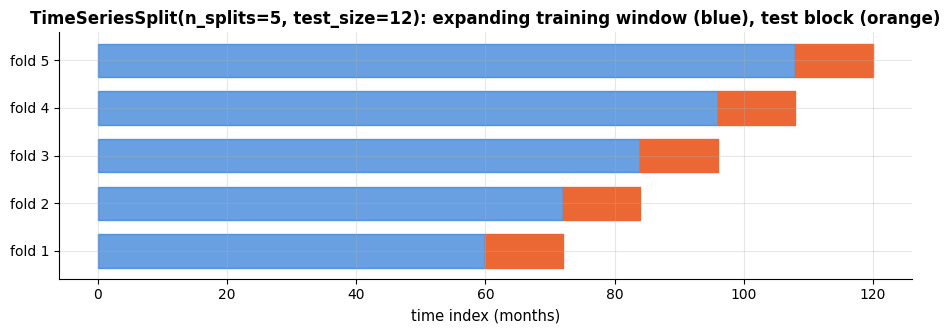

In [11]:
from sklearn.model_selection import TimeSeriesSplit     # cross-validation splitter that respects time order

# 5 folds; every test block holds the 12 observations right after its (growing) training window
tscv = TimeSeriesSplit(n_splits=5, test_size=12)
fig, ax = plt.subplots(figsize=(11, 3.2))
for fold, (tr, te) in enumerate(tscv.split(y_train)):   # .split yields (training indices, test indices) per fold
    # broken_barh([(x_start, width)], (y_bottom, height)) draws horizontal bars: first the training window...
    ax.broken_barh([(tr[0], len(tr))], (fold - 0.35, 0.7), color=PALETTE[0], alpha=0.7)
    ax.broken_barh([(te[0], len(te))], (fold - 0.35, 0.7), color=PALETTE[1])    # ...then the test block
ax.set_yticks(range(5))
ax.set_yticklabels([f"fold {k + 1}" for k in range(5)])
ax.set_xlabel("time index (months)")
ax.set_title("TimeSeriesSplit(n_splits=5, test_size=12): expanding training window (blue), test block (orange)")
plt.show()

> **Warning — random cross-validation on time series.** `KFold(shuffle=True)` scatters test
> points among training points, so the model is evaluated on *interpolation* between known
> neighbours instead of *extrapolation* into the future. Bergmeir & Benítez (2012) studied
> this carefully: whenever the series is non-stationary, or the model does not capture all of
> the serial dependence (its residuals are still autocorrelated), the shuffled estimate is
> optimistically biased — and even when it is not biased it answers the wrong question.
> (Bergmeir, Hyndman & Koo, 2018, show that $k$-fold CV *can* be valid for purely
> autoregressive models with uncorrelated residuals.) We measure the bias in section 4.4.
> The default is: time-ordered splits, always.

## 3. Classical methods

### 3.1 Simple exponential smoothing

The oldest idea in forecasting is to average the past — but to trust recent observations
more. **Simple exponential smoothing** (SES; Brown, 1959) keeps a single state, the
**level** $\ell_t$, and updates it with each new observation:

$$
\ell_t = \alpha\, y_t + (1-\alpha)\, \ell_{t-1}, \qquad \hat{y}_{t+h|t} = \ell_t ,
$$

with a smoothing parameter $0 < \alpha < 1$. Unrolling the recursion shows that the forecast
is a weighted average with geometrically decaying weights,
$\hat{y}_{t+1|t} = \sum_{j=0}^{t-1} \alpha(1-\alpha)^j y_{t-j} + (1-\alpha)^t \ell_0$:
$\alpha \to 1$ gives the naive forecast, $\alpha \to 0$ the mean. The parameter is chosen
by minimising the sum of squared **one-step-ahead errors** $\sum_t (y_t - \hat{y}_{t|t-1})^2$
on the training data.

### 3.2 Holt's linear trend method

SES has no notion of trend: its forecast is flat. Holt (1957) added a second state, the
**slope** $b_t$:

$$
\ell_t = \alpha\, y_t + (1-\alpha)(\ell_{t-1} + b_{t-1}), \qquad
b_t = \beta\,(\ell_t - \ell_{t-1}) + (1-\beta)\, b_{t-1}, \qquad
\hat{y}_{t+h|t} = \ell_t + h\, b_t .
$$

The level is now updated towards the trend-extrapolated previous level, and the slope is a
smoothed version of the recent level changes. Because a linear extrapolation is often too
optimistic far ahead, the **damped trend** variant replaces $h\,b_t$ by
$(\phi + \phi^2 + \dots + \phi^h)\, b_t$ with $0 < \phi < 1$ — one of the most reliable
methods in the M-competitions (Gardner, 1985).

SES:  alpha = 0.999                 test MAE = 115.3   MASE = 4.03
Holt: alpha = 0.999, beta = 0.006   test MAE =  73.0   MASE = 2.55


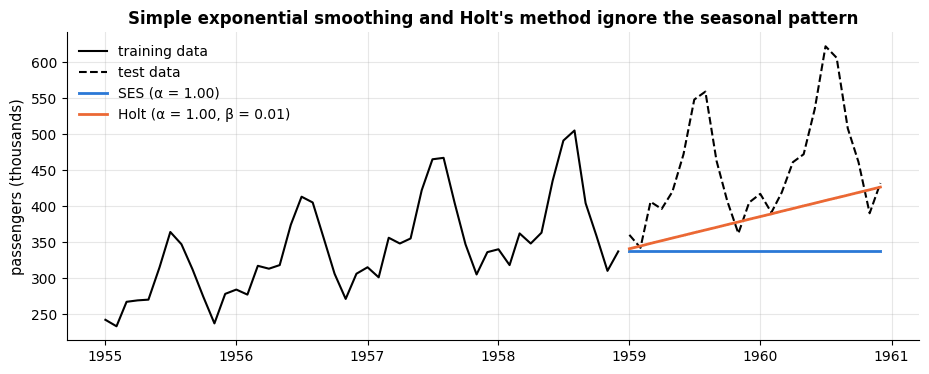

In [12]:
def ses(y, alpha, h):
    """Simple exponential smoothing. Returns one-step in-sample forecasts and the h-step forecast.

    y      the training series (1-D array)
    alpha  the smoothing parameter, between 0 and 1
    h      the forecast horizon
    Returns (fitted, forecast): fitted[t] is the forecast of y[t] made at t-1 (NaN for t = 0), and the
    forecast repeats the final level h times (an SES forecast is flat).
    """
    level = y[0]                                      # start the level at the first observation
    fitted = np.full(len(y), np.nan)                  # an array of len(y) NaNs, filled in below
    for t in range(1, len(y)):
        fitted[t] = level                             # forecast of y_t made at t-1
        level = alpha * y[t] + (1 - alpha) * level    # move the level a fraction alpha towards the new observation
    return fitted, np.repeat(level, h)


def holt(y, alpha, beta, h):
    """Holt's linear trend method.

    Like ses, with a second smoothing parameter beta for the slope. Returns (fitted, forecast), where the
    forecast is the final level plus 1, 2, ..., h times the final slope (a straight line).
    """
    level, slope = y[0], y[1] - y[0]                  # initial level and slope from the first two observations
    fitted = np.full(len(y), np.nan)
    for t in range(1, len(y)):
        fitted[t] = level + slope                     # one-step forecast of y[t] made at t-1
        new_level = alpha * y[t] + (1 - alpha) * (level + slope)      # observation vs. trend-extrapolated level
        slope = beta * (new_level - level) + (1 - beta) * slope       # smoothed version of the latest level change
        level = new_level                             # the old level was needed by the slope update, so swap last
    return fitted, level + slope * np.arange(1, h + 1)


def fit_smoother(method, y, n_params):
    """Choose the smoothing parameters by minimising the in-sample one-step squared error.

    method    ses or holt (any function method(y, *params, h) that returns (fitted, forecast))
    y         the training series
    n_params  how many smoothing parameters `method` takes (1 for ses, 2 for holt)
    Returns the best parameter array, of length n_params.
    """
    def sse(params):
        """Sum of squared one-step errors for one parameter vector: the objective to minimise."""
        fitted, _ = method(y, *params, 1)       # *params unpacks the array into separate arguments; h = 1 (unused)
        return np.nansum((y - fitted) ** 2)     # nansum skips the NaN at fitted[0]
    # optimize.minimize(fun, x0, bounds, method) searches for the parameters that minimise fun, starting at x0;
    # "L-BFGS-B" is a gradient-based method that respects the bounds (every parameter within 0.001 .. 0.999).
    # It runs from three starting points, and min(..., key=lambda r: r.fun) keeps the result with the smallest
    # objective value r.fun, in case one start ends in a poor local minimum
    best = min((optimize.minimize(sse, x0, bounds=[(0.001, 0.999)] * n_params, method="L-BFGS-B")
                for x0 in [np.full(n_params, 0.2), np.full(n_params, 0.5), np.full(n_params, 0.8)]),
               key=lambda r: r.fun)
    return best.x                               # .x holds the parameters that were found


alpha_ses = fit_smoother(ses, y_train, 1)               # an array with a single entry
alpha_holt, beta_holt = fit_smoother(holt, y_train, 2)  # unpack the two fitted parameters
fitted_ses, fc_ses = ses(y_train, *alpha_ses, H)        # rerun with the chosen alpha and forecast the 24 test months
fitted_holt, fc_holt = holt(y_train, alpha_holt, beta_holt, H)
print(f"SES:  alpha = {alpha_ses[0]:.3f}                 test MAE = {mae(y_test, fc_ses):5.1f}   MASE = {mase(y_test, fc_ses, y_train, 12):.2f}")
print(f"Holt: alpha = {alpha_holt:.3f}, beta = {beta_holt:.3f}   test MAE = {mae(y_test, fc_holt):5.1f}   MASE = {mase(y_test, fc_holt, y_train, 12):.2f}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_train[-48:], y_train[-48:], color="black", lw=1.5, label="training data")
ax.plot(t_test, y_test, color="black", lw=1.5, ls="--", label="test data")
ax.plot(t_test, fc_ses, lw=2, label=f"SES (α = {alpha_ses[0]:.2f})")
ax.plot(t_test, fc_holt, lw=2, label=f"Holt (α = {alpha_holt:.2f}, β = {beta_holt:.2f})")
ax.set_title("Simple exponential smoothing and Holt's method ignore the seasonal pattern")
ax.set_ylabel("passengers (thousands)")
ax.legend()
plt.show()

The optimiser pushes $\alpha$ close to one — with strong seasonality, the most recent
observation really is the best guess for the level — and Holt's method extrapolates the
trend sensibly, but neither can express the seasonal swing. Both are roughly as bad as the
naive baselines on this series; they are the right tools for series *without* seasonality
(or after seasonal adjustment).

### 3.3 The Holt–Winters seasonal method

Winters (1960) added the third state: a set of $m$ **seasonal indices** $s_t$. In the
**multiplicative** form (seasonal swing proportional to the level — the airline case), the
recursions are (Hyndman & Athanasopoulos, 2021, §8.3)

$$
\begin{aligned}
\ell_t &= \alpha \frac{y_t}{s_{t-m}} + (1-\alpha)(\ell_{t-1} + b_{t-1}) && \text{(level: deseasonalised observation vs. trend extrapolation)}\\
b_t &= \beta\,(\ell_t - \ell_{t-1}) + (1-\beta)\, b_{t-1} && \text{(slope)}\\
s_t &= \gamma \frac{y_t}{\ell_{t-1} + b_{t-1}} + (1-\gamma)\, s_{t-m} && \text{(seasonal index: observed ratio vs. last year's index)}\\
\hat{y}_{t+h|t} &= (\ell_t + h\, b_t)\; s_{t+h-m(k+1)}, \quad k = \lfloor (h-1)/m \rfloor .
\end{aligned}
$$

The **additive** form replaces every ratio by a difference and every product by a sum. The
states need initial values; the classical heuristic uses the first season: $\ell_m$ = mean of
the first $m$ observations, $b_m$ = (mean of the second season − mean of the first season)$/m$,
and $s_1, \dots, s_m$ = first-season observations divided by (or minus) that mean. The
three smoothing parameters are again chosen by minimising the one-step squared error.

In [13]:
def holt_winters(y, alpha, beta, gamma, m, h, seasonal="multiplicative"):
    """Holt-Winters exponential smoothing (Winters, 1960), FPP3 form. Returns fitted one-step values and the h-step forecast.

    y                   the training series
    alpha, beta, gamma  smoothing parameters of the level, the slope and the seasonal indices
    m                   the seasonal period
    h                   the forecast horizon
    seasonal            "multiplicative" (indices are ratios) or "additive" (indices are differences)
    Returns (fitted, forecast): fitted[t] is the one-step forecast of y[t] (NaN during the first season).
    """
    y = np.asarray(y, float)
    n = len(y)
    level = y[:m].mean()                                  # initial level: mean of the first season
    slope = (y[m:2 * m].mean() - y[:m].mean()) / m        # initial slope: change of the season mean, per step
    # initial seasonal indices: the first-season values relative to that mean. A list, because one new index
    # is appended per time step, so season[i] always belongs to time i
    season = list(y[:m] / level) if seasonal == "multiplicative" else list(y[:m] - level)
    fitted = np.full(n, np.nan)
    for t in range(m, n):                                 # the first season was used up by the initialisation
        s_prev = season[t - m]                            # the index of the same season one period earlier
        if seasonal == "multiplicative":
            fitted[t] = (level + slope) * s_prev                                  # one-step forecast of y[t]
            new_level = alpha * (y[t] / s_prev) + (1 - alpha) * (level + slope)   # deseasonalised obs. vs. trend
            season.append(gamma * (y[t] / (level + slope)) + (1 - gamma) * s_prev)   # new index for time t
        else:
            # additive form: the same updates with differences instead of ratios
            fitted[t] = level + slope + s_prev
            new_level = alpha * (y[t] - s_prev) + (1 - alpha) * (level + slope)
            season.append(gamma * (y[t] - level - slope) + (1 - gamma) * s_prev)
        slope = beta * (new_level - level) + (1 - beta) * slope
        level = new_level
    steps = np.arange(1, h + 1)                           # 1, 2, ..., h steps ahead
    # step i reuses one of the last m indices (season[n-m:]): the one at the same position in the season
    s_future = np.array([season[n - m + (i - 1) % m] for i in steps])
    # trend line times (multiplicative) or plus (additive) the seasonal index
    forecast = (level + slope * steps) * s_future if seasonal == "multiplicative" else level + slope * steps + s_future
    return fitted, forecast


def fit_holt_winters(y, m, seasonal="multiplicative"):
    """Fit (alpha, beta, gamma) of holt_winters by minimising the in-sample one-step SSE, like fit_smoother.

    Runs the optimiser from four starting points and returns the best parameter array (alpha, beta, gamma).
    """
    def sse(params):
        """Sum of squared one-step errors for one (alpha, beta, gamma) triple."""
        fitted, _ = holt_winters(y, *params, m=m, h=1, seasonal=seasonal)
        return np.nansum((y - fitted) ** 2)
    starts = [(0.3, 0.05, 0.3), (0.5, 0.1, 0.5), (0.8, 0.02, 0.2), (0.2, 0.2, 0.8)]   # (alpha, beta, gamma) starts
    best = min((optimize.minimize(sse, x0, bounds=[(0.001, 0.999)] * 3, method="L-BFGS-B") for x0 in starts),
               key=lambda r: r.fun)
    return best.x


hw_params = fit_holt_winters(y_train, m=12, seasonal="multiplicative")   # array (alpha, beta, gamma)
fitted_hw, fc_hw = holt_winters(y_train, *hw_params, m=12, h=H)
hw_log_params = fit_holt_winters(np.log(y_train), m=12, seasonal="additive")   # additive model on the log scale
_, fc_hw_log = holt_winters(np.log(y_train), *hw_log_params, m=12, h=H)        # _ discards the fitted values
fc_hw_log = np.exp(fc_hw_log)                     # back from logs to passenger numbers
print(f"multiplicative HW:      alpha = {hw_params[0]:.3f}, beta = {hw_params[1]:.3f}, gamma = {hw_params[2]:.3f}"
      f"   test MAE = {mae(y_test, fc_hw):5.1f}   MASE = {mase(y_test, fc_hw, y_train, 12):.2f}")
print(f"additive HW on log(y):  alpha = {hw_log_params[0]:.3f}, beta = {hw_log_params[1]:.3f}, gamma = {hw_log_params[2]:.3f}"
      f"   test MAE = {mae(y_test, fc_hw_log):5.1f}   MASE = {mase(y_test, fc_hw_log, y_train, 12):.2f}")

multiplicative HW:      alpha = 0.316, beta = 0.029, gamma = 0.696   test MAE =  33.0   MASE = 1.16
additive HW on log(y):  alpha = 0.345, beta = 0.004, gamma = 0.543   test MAE =  15.8   MASE = 0.55


Holt–Winters cuts the error of the seasonal-naive baseline by more than half, and the
additive version on the log scale — which is the same as a multiplicative model with
multiplicative *errors* — does better still. The parameters are typical: a moderate
$\alpha$, a tiny $\beta$ (the trend is stable) and a large $\gamma$.

**Prediction intervals.** A point forecast without a statement of uncertainty is a guess.
For exponential smoothing there are analytic interval formulas (Hyndman et al., 2002), but a
method that works for *any* forecaster is the **bootstrapped-residual simulation**
(Hyndman & Athanasopoulos, 2021, §5.5): draw future errors by resampling the in-sample
one-step residuals, generate many possible futures step by step (each simulated value is fed
back into the recursion), and read the intervals off the quantiles of the simulated paths.

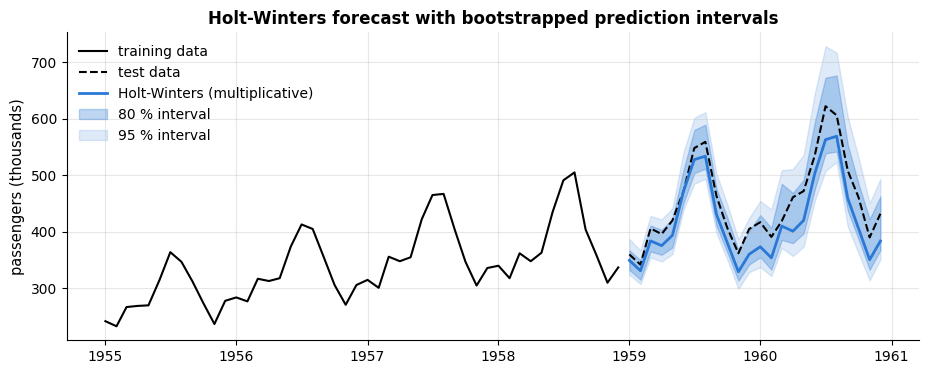

empirical coverage on the 24 test months: 80 % interval → 96%, 95 % interval → 100%


In [14]:
def simulate_hw_paths(y, params, m, h, n_paths, rng, seasonal="multiplicative"):
    """Bootstrap future paths: forecast one step, add a resampled (relative) residual, repeat.

    y, params, m, seasonal  the training series and the Holt-Winters settings (params = (alpha, beta, gamma))
    h                       number of future steps to simulate
    n_paths                 number of simulated futures
    rng                     the NumPy random generator used to draw the residuals
    Returns an array of shape (n_paths, h): one simulated future per row.
    """
    y = np.asarray(y, float)
    fitted, _ = holt_winters(y, *params, m=m, h=1, seasonal=seasonal)
    resid = (y - fitted)[m:]                       # in-sample one-step errors (the first season has no fitted values)
    if seasonal == "multiplicative":
        resid = resid / fitted[m:]                 # relative errors for a multiplicative model
    paths = np.zeros((n_paths, h))
    for i in range(n_paths):
        history = list(y)                          # every path starts from the real data
        for step in range(h):
            # one-step forecast from the history so far (the parameters stay fixed; nothing is refitted)
            _, next_value = holt_winters(np.array(history), *params, m=m, h=1, seasonal=seasonal)
            e = rng.choice(resid)                  # draw one past residual at random
            value = next_value[0] * (1 + e) if seasonal == "multiplicative" else next_value[0] + e
            history.append(value)                  # feed the simulated value back in: the next step builds on it
            paths[i, step] = value
    return paths


paths = simulate_hw_paths(y_train, hw_params, m=12, h=H, n_paths=300, rng=rng)   # shape (300, 24)
# per month (axis=0 = across the 300 paths): the 10th and 90th percentiles. The result has shape (2, 24)
# and unpacks into its two rows, the lower and the upper edge of the 80 % interval
lo80, hi80 = np.percentile(paths, [10, 90], axis=0)
lo95, hi95 = np.percentile(paths, [2.5, 97.5], axis=0)     # the same for the 95 % interval

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_train[-48:], y_train[-48:], color="black", lw=1.5, label="training data")
ax.plot(t_test, y_test, color="black", lw=1.5, ls="--", label="test data")
ax.plot(t_test, fc_hw, lw=2, color=PALETTE[0], label="Holt-Winters (multiplicative)")
ax.fill_between(t_test, lo80, hi80, color=PALETTE[0], alpha=0.3, label="80 % interval")   # shade between two curves
ax.fill_between(t_test, lo95, hi95, color=PALETTE[0], alpha=0.15, label="95 % interval")
ax.set_title("Holt-Winters forecast with bootstrapped prediction intervals")
ax.set_ylabel("passengers (thousands)")
ax.legend(loc="upper left")
plt.show()
# & is the element-wise "and"; the mean of a boolean array is the fraction of True values (the coverage)
cov80 = np.mean((y_test >= lo80) & (y_test <= hi80))
cov95 = np.mean((y_test >= lo95) & (y_test <= hi95))
# the format spec :.0% multiplies by 100 and adds a % sign (0 decimals)
print(f"empirical coverage on the 24 test months: 80 % interval → {cov80:.0%}, 95 % interval → {cov95:.0%}")

The intervals widen with the horizon, as they should: uncertainty accumulates. Here they
are, if anything, too *wide* — the 80 % band contains almost all of the 24 test months —
because the resampled residuals include the noisier early years of the series; with only
24 test points the empirical coverage is a rough check, but it is the check that matters,
and we return to interval calibration in section 4.6. Note also that the point forecast
runs below the 1960 peaks: the growth accelerated, and a method with a small $\beta$
adjusts its trend slowly.

In [15]:
if HAS_SM:
    try:
        from statsmodels.tsa.holtwinters import ExponentialSmoothing
        # additive trend, multiplicative seasonality with period 12 (the model of section 3.3);
        # .fit() estimates the smoothing parameters (and the initial states)
        sm_hw = ExponentialSmoothing(pd.Series(y_train, index=t_train), trend="add", seasonal="mul",
                                     seasonal_periods=12).fit()
        sm_fc = sm_hw.forecast(H).to_numpy()      # forecast the next H months
        print("statsmodels ExponentialSmoothing(trend='add', seasonal='mul'):")
        # the fitted parameters are stored in the dict .params under these names
        print(f"  alpha = {sm_hw.params['smoothing_level']:.3f}, beta = {sm_hw.params['smoothing_trend']:.3f}, "
              f"gamma = {sm_hw.params['smoothing_seasonal']:.3f}")
        print(f"  test MAE = {mae(y_test, sm_fc):.1f} (ours: {mae(y_test, fc_hw):.1f}); statsmodels also optimises the initial states, "
              "so small differences are expected")
    except Exception as exc:  # API differences between statsmodels versions
        print(f"statsmodels Holt-Winters cross-check failed: {type(exc).__name__}: {exc}")
else:
    print("statsmodels not available — skipping the ExponentialSmoothing cross-check.")

statsmodels not available — skipping the ExponentialSmoothing cross-check.


> **Going deeper — ETS state-space models.** Hyndman et al. (2002) showed that every
> exponential smoothing method is the forecast of an *innovations state-space model*
> ("ETS": Error, Trend, Seasonal, each none/additive/multiplicative). That view gives
> likelihoods, information criteria for choosing among the 30 variants, and proper
> prediction intervals; it is what `statsmodels.tsa.exponential_smoothing.ets.ETSModel` and
> R's `forecast::ets` implement. Chapter 8 of Hyndman & Athanasopoulos (2021) is the place
> to read about it.

### 3.4 Autoregressive models and ARIMA

Exponential smoothing describes the *states* of a series; the **ARIMA** family (Box &
Jenkins, 1970; Box et al., 2015) describes its *autocorrelation*. Three building blocks:

- **AR($p$)** — autoregression: the current value is a linear combination of the last $p$
  values plus white noise,
  $y_t = c + \phi_1 y_{t-1} + \dots + \phi_p y_{t-p} + \varepsilon_t$. It is a linear
  regression on lagged copies of the series, and the ACF/PACF signature is the one we saw in
  section 1.4: gradually decaying ACF, PACF cutting off after lag $p$.
- **MA($q$)** — moving average: the current value depends on the last $q$ *shocks*,
  $y_t = c + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q}$;
  the signature is the mirror image (ACF cuts off after lag $q$).
- **I($d$)** — integration: the model is applied to the $d$-th difference of the series.

ARIMA($p, d, q$) combines them, and the seasonal ARIMA($p,d,q$)($P,D,Q$)$_m$ adds seasonal
AR/MA terms at multiples of $m$ and a seasonal difference $D$. The **Box–Jenkins procedure**
is: (1) transform and difference until the series looks stationary, (2) *identify* orders
from the ACF/PACF (or by an information criterion), (3) *estimate* the coefficients,
(4) *check* the residuals — they should be white noise — and (5) forecast, undoing the
differencing. We implement the AR part from scratch: because an AR($p$) model is a linear
regression on lags, least squares gives the coefficients directly (this is the *conditional*
least-squares estimator; maximum likelihood, as in `statsmodels`, differs only in how the
first $p$ observations are treated). Let us apply the recipe to the airline series: log, then
one seasonal difference gives the annual growth rates $z_t = \log y_t - \log y_{t-12}$.

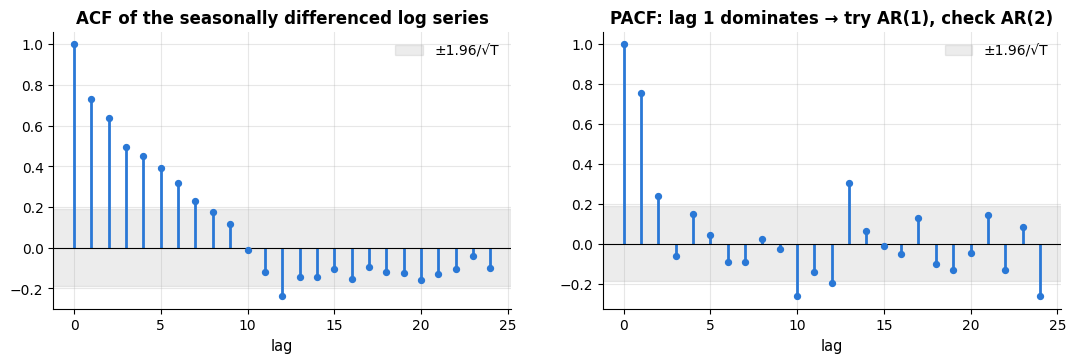

In [16]:
z_log = np.log(y_train)
z = z_log[12:] - z_log[:-12]                     # seasonal difference of the log series: annual growth rates
# (z has 12 values fewer than y_train: the first year has no value one year earlier)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
plot_correlogram(acf(z, 24), axes[0], "ACF of the seasonally differenced log series", len(z))   # 24 lags = 2 years
plot_correlogram(pacf(z, 24), axes[1], "PACF: lag 1 dominates → try AR(1), check AR(2)", len(z))
plt.show()

The ACF decays gradually and the PACF is dominated by lag 1; lag 2 is marginal and the
later lags hover around the band, so AR(1) and AR(2) are the natural candidates. Rather than trusting our eyes we
fit AR($p$) for several $p$ and compare them with the **Akaike information criterion**
$\text{AIC} = n \log(\text{SSE}/n) + 2k$ (with $k = p + 1$ estimated coefficients), which
rewards fit and penalises complexity — and, because in-sample criteria can disagree with
forecast performance, we also look at the test error.

In [17]:
def fit_ar(z, p):
    """AR(p) with intercept by least squares. Returns coefficients (c, phi_1..phi_p) and residuals.

    z  the (stationary) series; p  the number of lags.
    The coefficient array has length p + 1; the residuals cover z[p:], because the first p values
    have no complete set of lags.
    """
    # the same design matrix as in pacf: a column of ones, then z_{t-1}, ..., z_{t-p}; shape (len(z) - p, p + 1)
    lags = np.column_stack([np.ones(len(z) - p)] + [z[p - j:len(z) - j] for j in range(1, p + 1)])
    beta, *_ = np.linalg.lstsq(lags, z[p:], rcond=None)    # *_ collects (and discards) the other values lstsq returns
    return beta, z[p:] - lags @ beta                        # residuals = actual - fitted


def forecast_ar(z, beta, h):
    """Recursive h-step forecast: forecasts are fed back as lagged inputs.

    z     the observed series up to the origin
    beta  the coefficients (c, phi_1, ..., phi_p) from fit_ar
    h     the horizon
    Returns an array of h forecasts of z.
    """
    p = len(beta) - 1
    history = list(z)
    out = []
    for _ in range(h):
        # history[-p:][::-1] = the last p values, most recent first, to line up with phi_1 .. phi_p.
        # p = 0 needs its own case, because history[-0:] would be the whole list
        value = beta[0] + (np.dot(beta[1:], history[-p:][::-1]) if p > 0 else 0.0)
        out.append(value)
        history.append(value)                 # the forecast becomes the newest lag for the next step
    return np.array(out)


def undo_seasonal_log_difference(z_forecast, log_history, m=12):
    """Invert z_t = log y_t - log y_{t-m}: log y_{T+h} = z_{T+h} + log y_{T+h-m}.

    z_forecast   forecasts of the seasonally differenced log series
    log_history  the observed log series up to the origin
    Returns the forecasts on the original scale (the exp of the rebuilt logs).
    """
    log_y = list(log_history)
    for value in z_forecast:
        log_y.append(value + log_y[-m])       # log_y[-m]: the log value one season before the new step
    return np.exp(np.array(log_y[-len(z_forecast):]))    # keep only the new values and undo the log


rows = []
ar_forecasts = {}
for p in [0, 1, 2, 3, 4, 6, 12]:              # candidate orders (p = 0 is a constant growth rate)
    beta, resid = fit_ar(z, p)
    n_res = len(resid)
    # AIC = n log(SSE / n) + 2k with k = p + 1 coefficients (n = len(z) - p shrinks slightly as p grows)
    aic = n_res * np.log(np.sum(resid ** 2) / n_res) + 2 * (p + 1)
    fc = undo_seasonal_log_difference(forecast_ar(z, beta, H), z_log)   # forecast growth rates -> passenger numbers
    ar_forecasts[p] = fc
    rows.append({"p": p, "AIC": aic, "test MAE": mae(y_test, fc), "test MASE": mase(y_test, fc, y_train, 12)})
ar_table = pd.DataFrame(rows).set_index("p").round(2)
display(ar_table)
best_p = int(ar_table["AIC"].idxmin())        # idxmin returns the row label (here the order p) of the smallest AIC
beta_ar, resid_ar = fit_ar(z, best_p)
fc_ar = ar_forecasts[best_p]
# the long-run mean of an AR(1) is c / (1 - phi_1); the format spec :.1% prints it as a percentage
print(f"AIC selects p = {best_p}: z_t = {beta_ar[0]:.4f} + {beta_ar[1]:.3f} z_(t-1) + e_t   "
      f"(an annual growth rate that reverts to {beta_ar[0] / (1 - beta_ar[1]):.1%} per year)")

,AIC,test MAE,test MASE
p,,,
0,-586.19,13.28,0.46
1,-668.70,13.04,0.46
2,-665.63,18.68,0.65
3,-656.70,16.69,0.58
4,-650.23,21.27,0.74
6,-634.47,21.52,0.75
12,-596.56,19.72,0.69


AIC selects p = 1: z_t = 0.0298 + 0.755 z_(t-1) + e_t   (an annual growth rate that reverts to 12.2% per year)


The AIC and the test error agree on **AR(1)**: last year's growth rate, shrunk towards a
long-run average of about 12 % per year, is an excellent forecast of this year's. Undoing the
seasonal difference turns that into a full seasonal forecast, and it beats Holt–Winters —
a two-parameter model with a MASE below 0.5. Higher orders fit the training data better
(lower SSE) but forecast worse: the usual overfitting story, now in time-series clothing.
(The classic "airline model" of Box & Jenkins is a seasonal ARIMA(0,1,1)(0,1,1)$_{12}$ on the
logs, which needs MA terms — that is where a library takes over.)

In [18]:
if HAS_SM:
    try:
        from statsmodels.tsa.statespace.sarimax import SARIMAX
        # our model: AR(1) with constant on the seasonally differenced logs = SARIMA(1,0,0)(0,1,0)_12 with drift
        # order=(p, d, q), seasonal_order=(P, D, Q, m), trend="c" adds a constant; disp=False hides the optimiser's log
        sarima = SARIMAX(z_log, order=(1, 0, 0), seasonal_order=(0, 1, 0, 12), trend="c").fit(disp=False)
        fc_sarima = np.exp(sarima.forecast(H))     # the forecasts are on the log scale -> passengers
        # the classic Box-Jenkins "airline model": MA terms at lags 1 and 12, after a first and a seasonal difference
        airline = SARIMAX(z_log, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False)
        fc_airline = np.exp(airline.forecast(H))
        # params[0] is the constant, params[1] the AR coefficient phi
        print(f"statsmodels SARIMA(1,0,0)(0,1,0)12 + drift: phi = {sarima.params[1]:.3f}, test MAE = {mae(y_test, fc_sarima):.1f}"
              f"  (our least-squares AR(1): {mae(y_test, fc_ar):.1f})")
        print(f"statsmodels 'airline' ARIMA(0,1,1)(0,1,1)12 on logs: test MAE = {mae(y_test, fc_airline):.1f}")
    except Exception as exc:
        print(f"statsmodels SARIMAX cross-check failed: {type(exc).__name__}: {exc}")
else:
    print("statsmodels not available — skipping the SARIMAX cross-check.")

statsmodels not available — skipping the SARIMAX cross-check.


### 3.5 All methods on the hold-out

,MAE,RMSE,sMAPE %,MASE
AR(1) on seasonal diff. of log,13.04,15.91,3.01,0.46
"Holt-Winters (add., log)",15.85,17.69,3.72,0.55
Holt-Winters (mult.),33.03,36.79,7.64,1.16
seasonal naive,71.25,76.99,17.01,2.49
Holt,72.97,97.36,16.38,2.55
drift,91.62,115.70,21.20,3.21
SES,115.28,137.35,27.76,4.03
naive,115.25,137.33,27.75,4.03
mean,206.34,219.44,57.58,7.22


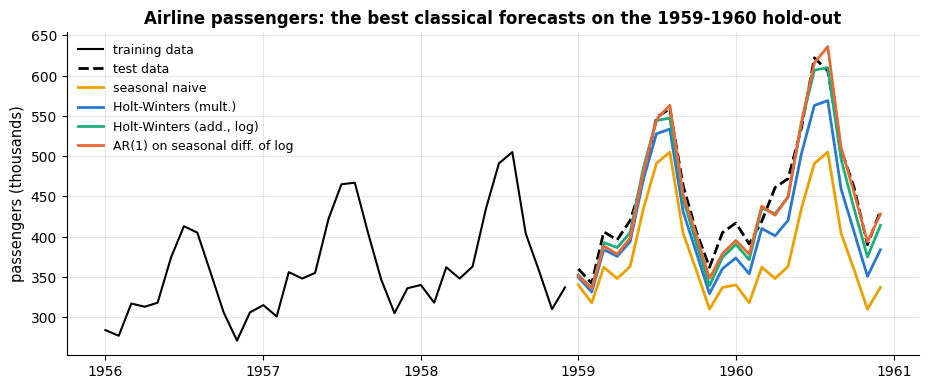

In [19]:
# {**d, ...} copies every entry of the dict d into a new dict and adds the entries that follow
all_forecasts = {**baseline_forecasts, "SES": fc_ses, "Holt": fc_holt, "Holt-Winters (mult.)": fc_hw,
                 "Holt-Winters (add., log)": fc_hw_log, f"AR({best_p}) on seasonal diff. of log": fc_ar}
table = score_table(y_test, all_forecasts, y_train, m=12).sort_values("MASE")    # best (smallest MASE) first
display(table)

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(t_train[-36:], y_train[-36:], color="black", lw=1.5, label="training data")
ax.plot(t_test, y_test, color="black", lw=2, ls="--", label="test data")
for name, c in [("seasonal naive", PALETTE[3]), ("Holt-Winters (mult.)", PALETTE[0]),
                ("Holt-Winters (add., log)", PALETTE[2]), (f"AR({best_p}) on seasonal diff. of log", PALETTE[1])]:
    ax.plot(t_test, all_forecasts[name], lw=2, color=c, label=name)
ax.set_title("Airline passengers: the best classical forecasts on the 1959-1960 hold-out")
ax.set_ylabel("passengers (thousands)")
ax.legend(fontsize=9)
plt.show()

## 4. The machine-learning approach: 24 hours ahead

Classical methods model one series with a handful of parameters. When we have *covariates*
(temperature, holidays), several seasonalities at once (daily, weekly, yearly) and thousands
of observations, it pays to turn forecasting into a **supervised regression problem**:
build a feature vector for every time step from information that is available at the
forecast origin, and let a flexible model (notebook 10's gradient boosting) learn the
mapping. This is how the winners of the M5 competition worked (Makridakis et al., 2022).

### 4.1 Framing the problem and engineering features

We want to forecast hourly demand **24 hours ahead**: at origin $t - 24$ we predict $y_t$.
The golden rule of feature engineering for forecasting is

> **Key idea.** Every feature of the target at time $t$ must be computable at the forecast
> origin $t - h$. Lagged values need a lag of at least $h$; rolling statistics must be
> computed on the series *shifted by $h$*; calendar features of the target time are always
> known; exogenous variables must be known or *forecast* (we use the temperature at the target
> hour, assuming a weather forecast is available — an assumption that must be stated).

The feature families used below:

| Family | Examples | Captures |
|---|---|---|
| **lags** | $y_{t-24}, y_{t-48}, y_{t-168}, y_{t-336}$ | persistence, daily and weekly seasonality |
| **rolling statistics** of the shifted series | mean of the 3 / 24 / 168 hours before the origin, std of the last 24 h | recent level and volatility |
| **calendar** | hour, weekday, month, holiday flag | seasonal shape, special days |
| **Fourier terms** | $\sin(2\pi k t / P), \cos(2\pi k t / P)$ for $P = 24, 168, 8766$ h | smooth seasonal curves for linear models |
| **trend** | $t$ in years | slow growth |
| **exogenous** | temperature at the target hour | weather-driven demand |

Fourier terms deserve a word: $K$ pairs of sines and cosines with period $P$ can represent
any smooth periodic pattern with period $P$ (the first $K$ harmonics), which lets a *linear*
model fit the daily shape without one dummy per hour, and they extend naturally to long
periods such as a year (Hyndman & Athanasopoulos, 2021, §7.4).

In [20]:
HORIZON = 24                         # forecast 24 hours ahead


def make_features(d, horizon=HORIZON, shift_rolling=True):
    """Feature matrix for forecasting demand `horizon` hours ahead. Every feature is known at the origin t - horizon.

    d              the hourly energy DataFrame (columns demand_mw, temperature_c, is_holiday; DatetimeIndex)
    horizon        hours between the forecast origin and the target hour
    shift_rolling  if False, the rolling statistics use the unshifted series (the leaky version of section 4.2)
    Returns (X, y): the feature DataFrame and the target Series, both without the warm-up rows that contain NaNs.
    """
    y = d["demand_mw"]                                                # the target
    X = pd.DataFrame(index=d.index)                                   # empty table on the same hourly index
    for lag in [horizon, horizon + 24, 168, 336]:                     # lags of at least `horizon`
        X[f"lag_{lag}h"] = y.shift(lag)                               # .shift(k): row t holds y_{t-k} (k NaNs first)
    past = y.shift(horizon) if shift_rolling else y                   # the series as known at the origin
    # .rolling(w) is a sliding window over the last w rows (the current row included); .mean() / .std()
    # summarise each window, and the result is NaN until w rows are available
    X["roll_mean_3h"] = past.rolling(3).mean()
    X["roll_mean_24h"] = past.rolling(24).mean()
    X["roll_mean_168h"] = past.rolling(168).mean()
    X["roll_std_24h"] = past.rolling(24).std()
    # calendar parts of each timestamp; dayofweek runs from Monday = 0 to Sunday = 6
    X["hour"], X["dayofweek"], X["month"] = d.index.hour, d.index.dayofweek, d.index.month
    X["is_holiday"] = d["is_holiday"].to_numpy()                      # .to_numpy(): copy the values by position
    X["temperature_c"] = d["temperature_c"].to_numpy()                # assumed available from a weather forecast
    t = np.arange(len(d))                                             # hours since the start of the series
    # (period in hours, number of harmonics K, name): 3 daily, 2 weekly and 1 yearly sine/cosine pair
    for period, K, name in [(24, 3, "day"), (168, 2, "week"), (24 * 365.25, 1, "year")]:
        for k in range(1, K + 1):
            X[f"sin_{name}{k}"] = np.sin(2 * np.pi * k * t / period)  # the k-th harmonic completes k cycles per period
            X[f"cos_{name}{k}"] = np.cos(2 * np.pi * k * t / period)
    X["trend_years"] = t / (24 * 365.25)                              # time in years
    # .notna() marks every non-missing cell; .all(axis=1) is True for rows where all features are present
    keep = X.notna().all(axis=1)                                      # drop the warm-up rows
    return X[keep], y[keep]                                           # boolean indexing keeps the selected rows


X, y = make_features(energy)
TEST_HOURS = 24 * 7 * 12                                              # the last 12 weeks are the test period
# .iloc selects rows by position: everything except the last 12 weeks / the last 12 weeks
X_tr, X_te = X.iloc[:-TEST_HOURS], X.iloc[-TEST_HOURS:]
y_tr, y_te = y.iloc[:-TEST_HOURS], y.iloc[-TEST_HOURS:]
print(f"{X.shape[1]} features; training {X_tr.index[0]:%Y-%m-%d} – {X_tr.index[-1]:%Y-%m-%d} ({len(X_tr)} h), "
      f"test {X_te.index[0]:%Y-%m-%d} – {X_te.index[-1]:%Y-%m-%d} ({len(X_te)} h)")
X.iloc[:3, :9]          # the last expression of a cell is displayed: the first 3 rows and 9 columns

26 features; training 2022-01-15 – 2023-10-08 (15168 h), test 2023-10-09 – 2023-12-31 (2016 h)


,lag_24h,lag_48h,lag_168h,lag_336h,roll_mean_3h,roll_mean_24h,roll_mean_168h,roll_std_24h,hour
timestamp,,,,,,,,,
2022-01-15 00:00:00,683.5,704.0,688.2,523.8,704.3,701.016667,719.254167,39.447860,0
2022-01-15 01:00:00,666.5,679.5,703.7,504.8,683.3,700.475000,718.676190,39.843425,1
2022-01-15 02:00:00,666.0,713.9,709.9,525.3,672.0,698.479167,718.231548,40.338330,2


### 4.2 Leakage in rolling features

The most common forecasting bug is a rolling statistic computed on the *unshifted* series:
`y.rolling(24).mean()` at time $t$ includes $y_t$ itself — the value we are trying to
predict. The model will exploit it, the backtest will look wonderful, and the deployed
model will fail, because in production $y_t$ does not exist yet. Let us measure the damage.

In [21]:
from sklearn.ensemble import HistGradientBoostingRegressor   # fast histogram-based gradient boosting (notebook 10)

X_leaky, y_leaky = make_features(energy, shift_rolling=False)    # the rolling features now include the target hour
# loop over the two (features, target) pairs, labelled by name
for name, (Xf, yf) in {"honest features (shifted by the horizon)": (X, y),
                       "LEAKY rolling features (unshifted)": (X_leaky, y_leaky)}.items():
    # max_iter: the maximum number of boosting iterations (trees); learning_rate: how much each tree contributes.
    # With more than 10 000 training rows, early stopping switches on by default: it holds out a random 10 % of
    # the rows to decide when to stop, and random_state fixes that random split so results are reproducible
    model = HistGradientBoostingRegressor(max_iter=150, learning_rate=0.1, random_state=RANDOM_STATE)
    model.fit(Xf.iloc[:-TEST_HOURS], yf.iloc[:-TEST_HOURS])     # train on everything before the 12 test weeks
    print(f"{name:45s} test MAE = {mae(yf.iloc[-TEST_HOURS:], model.predict(Xf.iloc[-TEST_HOURS:])):.1f} MW")

honest features (shifted by the horizon)      test MAE = 25.4 MW
LEAKY rolling features (unshifted)            test MAE = 11.3 MW


The leaky model looks *twice* as good, and it would be worthless in production. The
`shift(horizon)` before `rolling(...)` is the whole difference. Whenever a time-series
result looks too good, check the features first.

### 4.3 Models, baselines and backtesting

Two models: **ridge regression** on standardised numeric features plus one-hot calendar
features (notebook 6), and **gradient boosting** (`HistGradientBoostingRegressor`), which
needs no scaling and finds interactions (hour × weekday, temperature × hour) on its own.
And two baselines at the 24-hour horizon: the value 24 hours earlier (the seasonal-naive
forecast for a daily period) and the value one week earlier. We first use
`TimeSeriesSplit` with two-week test blocks on the training data.

In [22]:
from sklearn.compose import ColumnTransformer          # applies different preprocessing to different columns
from sklearn.linear_model import Ridge                 # linear regression with an L2 penalty (notebook 6)
from sklearn.model_selection import cross_validate     # fits and scores a model on every fold of a CV splitter
from sklearn.pipeline import make_pipeline             # chains preprocessing steps and a model into one estimator
from sklearn.preprocessing import OneHotEncoder, StandardScaler

calendar_cols = ["hour", "dayofweek", "month"]                       # treated as categories
numeric_cols = [c for c in X.columns if c not in calendar_cols]      # every other column is treated as a number
ridge = make_pipeline(
    # ColumnTransformer([(name, transformer, columns), ...]) preprocesses each group of columns separately:
    # StandardScaler standardises the numeric columns (mean 0, std 1); OneHotEncoder gives one 0/1 column per
    # category, and handle_unknown="ignore" turns a category never seen in training into all zeros, not an error
    ColumnTransformer([("num", StandardScaler(), numeric_cols),
                       ("cal", OneHotEncoder(handle_unknown="ignore"), calendar_cols)]),
    Ridge(alpha=1.0))                                                # alpha: the strength of the L2 penalty
hgb = HistGradientBoostingRegressor(max_iter=150, learning_rate=0.1, random_state=RANDOM_STATE)

tscv = TimeSeriesSplit(n_splits=5, test_size=24 * 14)               # 5 folds with two-week test blocks
cv_rows = {}
for name, model in [("ridge", ridge), ("gradient boosting", hgb)]:
    # cross_validate refits the model on every training fold and scores it on the fold's test block.
    # scikit-learn always maximises scores, so the MAE comes back negated ("neg_..."); one value per fold
    res = cross_validate(model, X_tr, y_tr, cv=tscv, scoring="neg_mean_absolute_error")
    cv_rows[name] = -res["test_score"]                              # flip the sign back to a positive MAE
# the baselines need no fitting: the lag_24h / lag_168h column already is their forecast.
# Same test blocks as above; `_` ignores the training indices
for name, col in [("naive (24 h earlier)", "lag_24h"), ("seasonal naive (1 week earlier)", "lag_168h")]:
    cv_rows[name] = np.array([mae(y_tr.iloc[te], X_tr[col].iloc[te]) for _, te in tscv.split(X_tr)])
cv_table = pd.DataFrame(cv_rows, index=[f"fold {k + 1}" for k in range(5)]).T   # .T: one row per method
cv_table["mean"] = cv_table.mean(axis=1)                            # axis=1: average across each row (over the folds)
display(cv_table.round(1))

,fold 1,fold 2,fold 3,fold 4,fold 5,mean
ridge,37.7,34.8,28.9,26.1,25.4,30.6
gradient boosting,25.0,24.5,25.3,25.2,22.9,24.6
naive (24 h earlier),53.9,44.3,51.7,43.2,41.3,46.9
seasonal naive (1 week earlier),46.5,36.0,36.8,36.9,33.5,37.9


Now the hand-written rolling-origin backtest on the 12-week test period: every Monday we
refit on all data up to that day and forecast the coming week, 24 hours ahead at each hour
— exactly what a weekly retraining schedule would do in production.

In [23]:
step = 24 * 7                                  # refit weekly, forecast the coming week
rows = []
n_train0 = len(X) - TEST_HOURS                 # position of the first test hour
for k in range(TEST_HOURS // step):            # 12 weekly origins (// is integer division)
    end = n_train0 + k * step                  # forecast origin (index into X)
    X_fit, y_fit = X.iloc[:end], y.iloc[:end]                          # all data before the origin
    X_week, y_week = X.iloc[end:end + step], y.iloc[end:end + step]    # the coming week
    row = {"week starting": X_week.index[0].date()}                    # .date() drops the time of day
    for name, model in [("ridge", ridge), ("gradient boosting", hgb)]:
        row[name] = mae(y_week, model.fit(X_fit, y_fit).predict(X_week))   # .fit returns the model, so .predict chains
    row["naive (24 h)"] = mae(y_week, X_week["lag_24h"])               # the baselines come straight from the lag columns
    row["seasonal naive (168 h)"] = mae(y_week, X_week["lag_168h"])
    rows.append(row)
backtest = pd.DataFrame(rows).set_index("week starting")
# backtest.mean() / .std() give one value per column (method); the MASE divides the mean MAE by the in-sample
# MAE of the 24-hour naive forecast (y_t - y_{t-24} on the training period)
summary = pd.DataFrame({"MAE (mean over 12 weeks)": backtest.mean(), "MAE (std)": backtest.std(),
                        "MASE": backtest.mean() / np.mean(np.abs(y_tr.to_numpy()[24:] - y_tr.to_numpy()[:-24]))})
display(summary.round(2))
# idxmax returns the row label (the week) of the largest value
print("worst week for gradient boosting:", backtest["gradient boosting"].idxmax(),
      f"(MAE {backtest['gradient boosting'].max():.1f} MW)")

,MAE (mean over 12 weeks),MAE (std),MASE
ridge,30.43,5.34,0.63
gradient boosting,25.66,2.92,0.53
naive (24 h),53.56,9.33,1.10
seasonal naive (168 h),54.60,18.71,1.12


worst week for gradient boosting: 2023-10-23 (MAE 30.2 MW)


Gradient boosting halves the error of the best baseline (MASE ≈ 0.5), and ridge is not far
behind — the Fourier and lag features carry most of the signal, and the tree model adds the
interactions. The week-to-week spread (the standard deviation column) is the reason to
backtest over many origins: a single week could have told us anything between 20 and
30 MW.

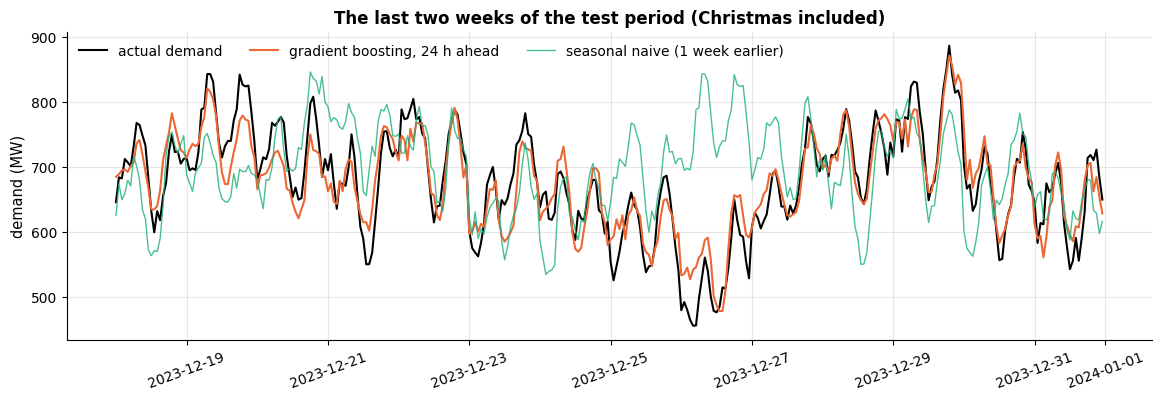

In [24]:
# refit both models on the whole training period (the backtest loop left them fitted on its last window)
hgb.fit(X_tr, y_tr)
ridge.fit(X_tr, y_tr)
last = slice(-24 * 14, None)          # a slice object, the same as [-336:]; reusable as an index below
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_te.index[last], y_te.iloc[last], color="black", lw=1.5, label="actual demand")
ax.plot(y_te.index[last], hgb.predict(X_te.iloc[last]), lw=1.5, color=PALETTE[1], label="gradient boosting, 24 h ahead")
ax.plot(y_te.index[last], X_te["lag_168h"].iloc[last], lw=1, color=PALETTE[2], alpha=0.8, label="seasonal naive (1 week earlier)")
ax.set_title("The last two weeks of the test period (Christmas included)")
ax.set_ylabel("demand (MW)")
ax.tick_params(axis="x", rotation=20)
ax.legend(loc="upper left", ncol=3)
plt.show()

Christmas Day and Boxing Day (25–26 December) show why the holiday flag matters: the model
has seen exactly one previous Christmas (2022), which is enough to learn that demand drops,
whereas the seasonal-naive forecast copies an ordinary Monday.

### 4.4 Random cross-validation versus time-ordered cross-validation

We can now quantify the warning of section 2.4. The same gradient-boosting model, the same
training data, two cross-validation schemes.

In [25]:
from sklearn.model_selection import KFold     # ordinary k-fold splitter; shuffle=True assigns rows to folds at random

model = HistGradientBoostingRegressor(max_iter=100, learning_rate=0.1, random_state=RANDOM_STATE)
schemes = {"TimeSeriesSplit (test blocks in the future)": TimeSeriesSplit(n_splits=4, test_size=24 * 14),
           "KFold(shuffle=True) (test points scattered in time)": KFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)}
for name, cv in schemes.items():
    # the same model and training data, only the splitter changes; the minus sign turns the scores back into MAE
    scores = -cross_validate(model, X_tr, y_tr, cv=cv, scoring="neg_mean_absolute_error")["test_score"]
    print(f"{name:55s} CV MAE = {scores.mean():5.1f} MW  (folds: {np.round(scores, 1)})")
# the reference: hgb (fitted on the training period above) scored on the real future
print(f"{'actual 24-h-ahead error on the future test period':55s}     MAE = {mae(y_te, hgb.predict(X_te)):5.1f} MW")

TimeSeriesSplit (test blocks in the future)             CV MAE =  24.5 MW  (folds: [24.2 25.2 25.5 23. ])
KFold(shuffle=True) (test points scattered in time)     CV MAE =  20.3 MW  (folds: [20.1 20.6 19.9 20.5])
actual 24-h-ahead error on the future test period           MAE =  25.4 MW


The shuffled estimate is about 20 % too optimistic. The mechanism: demand has a slowly
varying component (weather regimes, autocorrelated noise), and a test hour whose
neighbours — one hour earlier and later, with nearly identical features and targets — sit
in the training set is much easier than a test hour in an unseen future week. The
time-ordered estimate matches the error we actually observe on the future.

### 4.5 Direct versus recursive multi-step forecasting

So far we trained one model for the one horizon we need ($h = 24$): the **direct**
strategy. The alternative is **recursive** forecasting: train a one-step-ahead model (lags
1, 2, …, 24 and 168) and iterate it, feeding each prediction back as the lag-1 input for
the next step, 24 times. Recursive forecasting needs only one model for every horizon and
uses the most recent data, but errors accumulate along the chain; the direct strategy
avoids error feedback but needs one model per horizon and cannot use lags shorter than $h$.
(A third option, **multi-output**, predicts all 24 hours at once.) Let us compare them on
the test period — with a single training origin here, to keep the computation short.

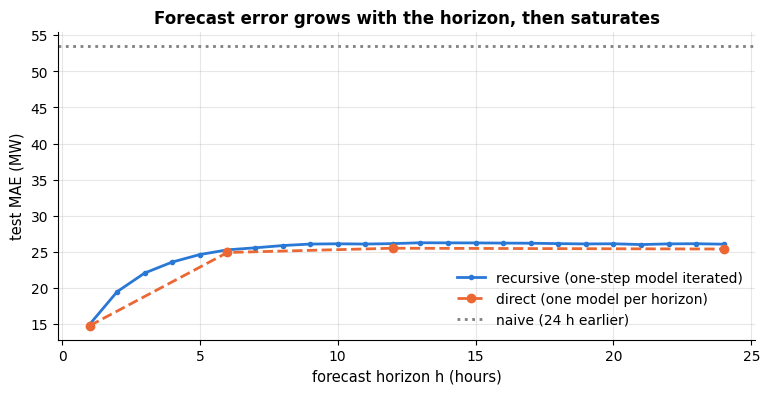

MAE at h = 24: recursive 26.0 MW, direct 25.4 MW


In [26]:
y_all = energy["demand_mw"].to_numpy()       # the whole hourly demand series as an array
idx_all = energy.index                       # its timestamps
n_all = len(energy)
split = n_all - TEST_HOURS                   # position of the first test hour
ONE_STEP_LAGS = list(range(1, 25)) + [168]   # lags 1, 2, ..., 24 h and one week


def context_features(t):
    """Calendar, Fourier, trend and temperature features for target positions t (known at any origin).

    t  an integer array of positions in the series. Returns a dict {feature name: array of len(t)}.
    """
    times = idx_all[t]                       # the timestamps at those positions
    # [t] picks the values at the target positions (fancy indexing)
    f = {"hour": times.hour, "dayofweek": times.dayofweek, "month": times.month,
         "is_holiday": energy["is_holiday"].to_numpy()[t], "temperature_c": energy["temperature_c"].to_numpy()[t],
         "trend_years": t / (24 * 365.25)}
    for period, K, name in [(24, 3, "day"), (168, 2, "week")]:      # as in make_features, without the yearly pair
        for k in range(1, K + 1):
            # tuple assignment: the sine and the cosine column in one line
            f[f"sin_{name}{k}"], f[f"cos_{name}{k}"] = np.sin(2 * np.pi * k * t / period), np.cos(2 * np.pi * k * t / period)
    return f


def one_step_features(t, known=None):
    """Lags 1..24 and 168 for targets t. `known` maps step -> predictions used in place of unknown lags.

    t      integer array of target positions
    known  None when every lag is observed (training). During the recursion it is the dict of predictions:
           known["step"] = the current step s, and known[j] = the predictions made at step j < s
    Returns a DataFrame with one row per target.
    """
    f = {}
    for j in ONE_STEP_LAGS:
        # the target is origin + s, so lag j points to origin + s - j: still observed when j >= s,
        # otherwise it is the prediction made at step s - j
        f[f"lag_{j}h"] = y_all[t - j] if known is None or j >= known["step"] else known[known["step"] - j]
    f.update(context_features(t))            # .update adds all entries of the other dict
    return pd.DataFrame(f)


t_fit = np.arange(336, split)                # training targets, starting two weeks in so every lag exists
t_test = np.arange(split, n_all)             # test targets as positions (this replaces the airline dates in t_test)
one_step_model = HistGradientBoostingRegressor(max_iter=150, learning_rate=0.1, random_state=RANDOM_STATE)
one_step_model.fit(one_step_features(t_fit), y_all[t_fit])     # a one-step-ahead model: lag 1 is an input

# recursive: from every origin o = t - 24, roll the one-step model forward 24 times (vectorised over origins)
origins = t_test - HORIZON                   # the forecast origin of every test hour
preds = {}                                   # becomes {"step": s, 1: predictions of step 1, 2: ..., s: ...}
recursive_mae_by_h = []
for s in range(1, HORIZON + 1):
    preds["step"] = s
    preds[s] = one_step_model.predict(one_step_features(origins + s, known=preds))   # all origins at once
    recursive_mae_by_h.append(mae(y_all[origins + s], preds[s]))                     # the error at horizon s

# direct: one model per horizon (a few horizons only, to keep the runtime short)
direct_mae_by_h = {}
for h in [1, 6, 12, 24]:
    Xh, yh = make_features(energy, horizon=h)      # every lag is now at least h
    model_h = HistGradientBoostingRegressor(max_iter=150, learning_rate=0.1, random_state=RANDOM_STATE)
    model_h.fit(Xh.iloc[:-TEST_HOURS], yh.iloc[:-TEST_HOURS])
    direct_mae_by_h[h] = mae(yh.iloc[-TEST_HOURS:], model_h.predict(Xh.iloc[-TEST_HOURS:]))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, HORIZON + 1), recursive_mae_by_h, marker=".", label="recursive (one-step model iterated)")
# list(dict) gives the keys (the horizons), list(dict.values()) the MAEs
ax.plot(list(direct_mae_by_h), list(direct_mae_by_h.values()), marker="o", ls="--", label="direct (one model per horizon)")
ax.axhline(mae(y_te, X_te["lag_24h"]), color="gray", ls=":", label="naive (24 h earlier)")
ax.set_xlabel("forecast horizon h (hours)")
ax.set_ylabel("test MAE (MW)")
ax.set_title("Forecast error grows with the horizon, then saturates")
ax.legend()
plt.show()
print(f"MAE at h = 24: recursive {recursive_mae_by_h[-1]:.1f} MW, direct {direct_mae_by_h[24]:.1f} MW")

Both strategies agree closely here, and both curves tell the same story: the last few hours
carry information that decays quickly (the error grows from about 15 MW at $h = 1$ to about
25 MW at $h \approx 8$), after which the forecast rests on the seasonal shape, the calendar
and the temperature alone. Recursive forecasting is the cheap default; direct models are
worth it when the one-step model's errors are strongly autocorrelated or when the horizon
of interest is long.

### 4.6 Prediction intervals with quantile regression — and their calibration

Gradient boosting can forecast *quantiles* instead of the mean by minimising the pinball
loss (`loss="quantile"`): two models, for the 5 % and 95 % quantiles, give a nominal 90 %
prediction interval. Whether the interval is honest is an empirical question, so we check
its **coverage** — the fraction of test observations inside — and, if it is too narrow, we
widen it with a simple **conformal-style correction**: on a calibration window held out from
training, compute the residual quantile that would have achieved the desired coverage, and
add that margin to the interval.

nominal 90 % interval: coverage on the training hours = 90.2%, on the calibration weeks = 81.1%
                       coverage on the test period = 74.9%, mean width = 84 MW
after adding the conformal margin of 9.7 MW: coverage on the test period = 84.6%, mean width = 103 MW


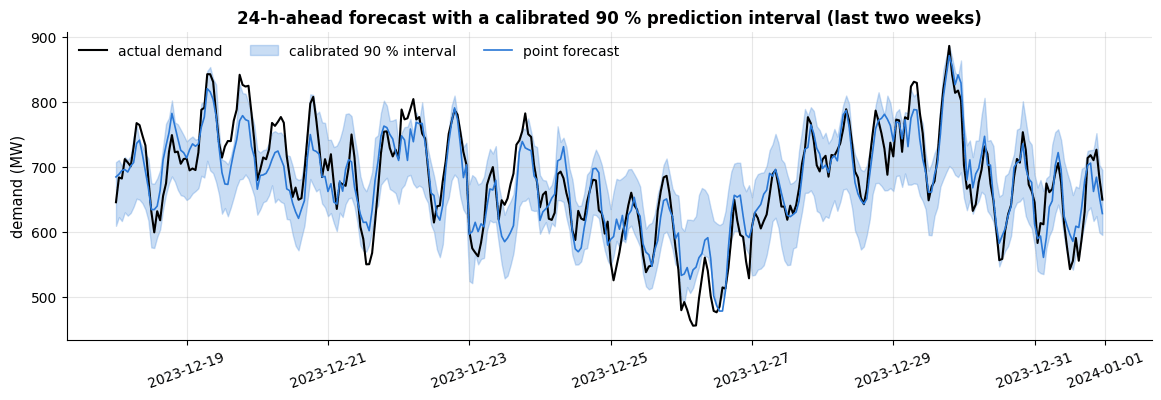

In [27]:
calib_hours = 24 * 7 * 4                                  # the last 4 weeks of training data for calibration
X_fit, y_fit = X_tr.iloc[:-calib_hours], y_tr.iloc[:-calib_hours]    # the quantile models train on the rest
X_cal, y_cal = X_tr.iloc[-calib_hours:], y_tr.iloc[-calib_hours:]
# loss="quantile" with quantile=q makes the model predict the q-quantile instead of the mean (pinball loss).
# A dict comprehension {q: fitted model} for q = 0.05 and 0.95 -> together a nominal 90 % interval
quantile_models = {q: HistGradientBoostingRegressor(loss="quantile", quantile=q, max_iter=200, learning_rate=0.08,
                                                    random_state=RANDOM_STATE).fit(X_fit, y_fit) for q in (0.05, 0.95)}
# a generator that yields two prediction arrays, unpacked into the lower and the upper edge
lo_te, hi_te = (quantile_models[q].predict(X_te) for q in (0.05, 0.95))
coverage_raw = np.mean((y_te >= lo_te) & (y_te <= hi_te))   # fraction of test hours inside the interval

# conformal-style margin: how far outside the interval do calibration points fall?
lo_cal, hi_cal = (quantile_models[q].predict(X_cal) for q in (0.05, 0.95))
scores_cal = np.maximum(lo_cal - y_cal, y_cal - hi_cal)   # positive = outside the interval (negative = inside)
margin = np.quantile(scores_cal, 0.90)     # widening both edges by this much would cover 90 % of the calibration hours
coverage_adj = np.mean((y_te >= lo_te - margin) & (y_te <= hi_te + margin))
# coverage on the hours the models were trained on, and on the calibration weeks
coverage_fit = np.mean((y_fit >= quantile_models[0.05].predict(X_fit)) & (y_fit <= quantile_models[0.95].predict(X_fit)))
coverage_cal = np.mean((y_cal >= lo_cal) & (y_cal <= hi_cal))
print(f"nominal 90 % interval: coverage on the training hours = {coverage_fit:.1%}, on the calibration weeks = {coverage_cal:.1%}")
print(f"                       coverage on the test period = {coverage_raw:.1%}, mean width = {np.mean(hi_te - lo_te):.0f} MW")
print(f"after adding the conformal margin of {margin:.1f} MW: coverage on the test period = {coverage_adj:.1%}, "
      f"mean width = {np.mean(hi_te - lo_te) + 2 * margin:.0f} MW")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_te.index[last], y_te.iloc[last], color="black", lw=1.5, label="actual demand")
# the widened interval over the last two weeks (`last` is the slice defined in section 4.3)
ax.fill_between(y_te.index[last], (lo_te - margin)[last], (hi_te + margin)[last], color=PALETTE[0], alpha=0.25,
                label="calibrated 90 % interval")
ax.plot(y_te.index[last], hgb.predict(X_te.iloc[last]), color=PALETTE[0], lw=1.2, label="point forecast")
ax.set_title("24-h-ahead forecast with a calibrated 90 % prediction interval (last two weeks)")
ax.set_ylabel("demand (MW)")
ax.tick_params(axis="x", rotation=20)
ax.legend(loc="upper left", ncol=3)
plt.show()

The raw quantile models are over-confident: their "90 %" interval covers 90 % of the
*training* hours but only about 83 % of the calibration weeks and about 75 % of the test
hours. The margin repairs the in-sample optimism, but the test period — the heating season,
October to December — is more volatile than the early-autumn calibration weeks, so
coverage climbs only to a little above 80 %. This is non-stationarity again: a calibration
window must resemble the deployment period (the same season a year earlier, or a rolling
recalibration as new actuals arrive), and coverage must be monitored after deployment.
*Always report the empirical coverage of your intervals.*

## 5. Global models, deep learning, Prophet and the M-competitions

**Global models.** Everything above fits *one* series. A retailer has thousands (one per
product and store), a utility has one per substation. A **global model** pools them: one
regression model trained on the stacked feature tables of all series, with the series
identity as a feature. It learns shared structure (holiday effects, promotion responses)
that short individual series cannot reveal, and it is how the M5 competition was won —
gradient-boosted trees (LightGBM) over lag, calendar and price features of 42 840 series
(Makridakis et al., 2022).

**Deep learning.** Recurrent networks, temporal convolutions and transformers are global models by construction, and they shine when there are many long series with rich
covariates; Lim & Zohren (2021) survey the architectures. The M4 winner was a hybrid of
exponential smoothing and an LSTM (Smyl, 2020) — the smoothing handled level and
seasonality per series, the network learned the shared non-linear dynamics. For a single
series of a few thousand points, the models of section 4 are as good and far cheaper.

**Prophet-style additive models.** Taylor & Letham (2018) model
$y_t = g(t) + s(t) + h(t) + \varepsilon_t$ with a piecewise-linear trend $g$ with automatic
changepoints, Fourier seasonalities $s$ and holiday effects $h$, fitted as a Bayesian
regression. It is robust to missing data and outliers and easy to use, which made it
popular for business series; in the M-competitions it did not beat well-tuned smoothing.

```py
# The Prophet API (optional: conda install -c conda-forge prophet)
from prophet import Prophet
m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True)
m.add_regressor("temperature_c")
m.fit(pd.DataFrame({"ds": energy.index, "y": energy["demand_mw"], "temperature_c": energy["temperature_c"]}))
future = m.make_future_dataframe(periods=24, freq="h")          # + the temperature forecast
```

**Lessons from the M-competitions** (Makridakis et al., 2020, 2022): (1) simple methods —
seasonal naive, damped exponential smoothing, "theta" — are hard to beat and must be
reported; (2) combinations (averages) of methods are consistently better than their
components; (3) machine-learning models win when they can *cross-learn* from many series
and when features are engineered carefully, and lose when applied naively to single short
series; (4) prediction intervals are usually too narrow — everybody is over-confident.

## 6. Residual diagnostics, anomalies and deployment

**Residual checks.** A model that has captured the dynamics leaves residuals that look like
white noise: no autocorrelation, constant variance, zero mean. The **Ljung–Box test**
(Ljung & Box, 1978) aggregates the first $L$ residual autocorrelations,

$$
Q = T(T+2) \sum_{k=1}^{L} \frac{r_k^2}{T-k}, \qquad Q \sim \chi^2_{L - p} \ \text{under the white-noise hypothesis},
$$

where $p$ is the number of fitted parameters; a small $p$-value means "there is still
structure to model".

Ljung-Box, Holt-Winters (mult.)           Q =   44.2, p-value = 0.002
Ljung-Box, AR(1) on seasonal diff.        Q =   49.1, p-value = 0.001
Ljung-Box, white noise (reference)        Q =   28.9, p-value = 0.225


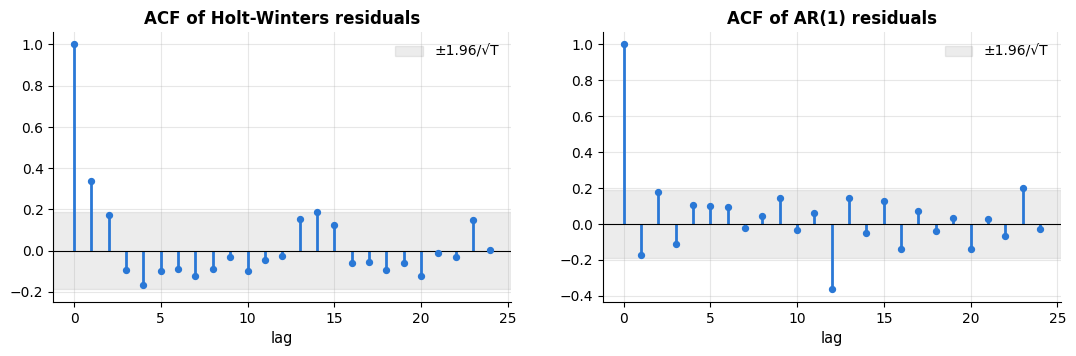

In [28]:
def ljung_box(resid, lags=24, n_params=0):
    """Ljung-Box test for autocorrelation left in the residuals.

    resid     the residual series
    lags      L, the number of residual autocorrelations combined into Q
    n_params  the number of fitted model parameters, subtracted from the degrees of freedom
    Returns (Q, p-value); a small p-value means the residuals are not white noise.
    """
    resid = np.asarray(resid, float)
    T = len(resid)
    r = acf(resid, lags)[1:]                       # r_1 .. r_L (r_0 = 1 is dropped)
    q = T * (T + 2) * np.sum(r ** 2 / (T - np.arange(1, lags + 1)))   # Q = T(T+2) * sum over k of r_k^2 / (T - k)
    # chi2.sf(x, df) is the survival function P(chi-squared with df degrees of freedom > x): the p-value
    return q, stats.chi2.sf(q, lags - n_params)


hw_resid = (y_train - fitted_hw)[12:]          # in-sample one-step residuals (the first season has no fitted values)
# (label, residuals, number of fitted parameters); simulated white noise is a reference that should pass
for name, resid, k in [("Holt-Winters (mult.)", hw_resid, 3), (f"AR({best_p}) on seasonal diff.", resid_ar, best_p + 1),
                       ("white noise (reference)", rng.normal(size=len(hw_resid)), 0)]:
    q, p = ljung_box(resid, lags=24, n_params=k)
    print(f"Ljung-Box, {name:30s} Q = {q:6.1f}, p-value = {p:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
plot_correlogram(acf(hw_resid, 24), axes[0], "ACF of Holt-Winters residuals", len(hw_resid))
plot_correlogram(acf(resid_ar, 24), axes[1], f"ACF of AR({best_p}) residuals", len(resid_ar))
plt.show()

Both classical models leave structure behind (the Ljung–Box $p$-values are small) while
the simulated white noise passes. The residual ACFs say *what* is missing: the Holt–Winters
residuals are positively correlated at lag 1 (the level adapts a little too slowly), and the
AR(1) residuals have a strong negative spike at lag 12 — the fingerprint of the seasonal
moving-average term that the airline model adds and our pure AR model lacks. Diagnostics like
these tell you *whether* to keep improving a model — not how good its forecasts are; that is
what the backtest is for.

**Anomalies on residuals.** Forecast residuals are also the natural input for anomaly
detection (notebook 13): an observation that the model — which knows the calendar, the
weather and the recent past — did not expect is worth a look. We inject an artificial
six-hour outage into the test period and flag hours whose standardised residual exceeds 3.

In [29]:
y_test_anom = y_te.copy()                     # a copy, so the real test data stay untouched
outage = slice("2023-11-15 10:00", "2023-11-15 15:00")          # a label slice: .loc includes both ends -> 6 hours
y_test_anom.loc[outage] *= 0.7                                  # a 30 % drop for six hours
resid_te = y_test_anom - hgb.predict(X_te)                      # actual minus the 24-h-ahead forecast
# MAD = median of the absolute deviations from the median; multiplied by 1.4826 it estimates the std of normal data
sigma = np.median(np.abs(resid_te - resid_te.median())) * 1.4826     # robust std (MAD), so outliers do not inflate it
z_scores = (resid_te - resid_te.median()) / sigma               # robust z-score of every hour's residual
flagged = z_scores[np.abs(z_scores) > 3]                        # keep the hours more than 3 robust stds away
print(f"{len(flagged)} hours flagged with |z| > 3; the injected outage covers 6 hours:")
print(flagged.round(1).to_string())                             # .to_string() prints every row, without truncation

8 hours flagged with |z| > 3; the injected outage covers 6 hours:
timestamp
2023-10-12 14:00:00   -3.5
2023-10-23 18:00:00    3.1
2023-11-15 10:00:00   -5.4
2023-11-15 11:00:00   -4.9
2023-11-15 12:00:00   -5.2
2023-11-15 13:00:00   -4.8
2023-11-15 14:00:00   -5.2
2023-11-15 15:00:00   -5.2


The six outage hours stand out with $|z| \approx 5$; a handful of ordinary hours sit just
above the threshold — with about 2 000 test hours and residuals that have heavier tails than
a Gaussian, a few alarms at $|z| = 3$ are expected. Raising the threshold or requiring two
consecutive hits trades sensitivity for fewer false alarms; notebook 13 has the tools for
a more principled choice.

**Deployment.** A forecasting model in production is a *process*, not a file: a
**retraining cadence** (weekly, as in our backtest, or whenever the backtest error
deteriorates), a **monitoring** loop that compares yesterday's forecasts with today's
actuals (the labels arrive with a delay of exactly $h$), **drift** detection on the inputs
and the errors, and a fallback (the seasonal-naive forecast) when the model or its
features fail. Notebook 18 builds this machinery.

## 7. Strengths, weaknesses and when to use each family

Three families of forecaster have appeared in this notebook, and they fail in different
ways. Before the tuning guide and the case study, here is the honest verdict on each —
followed by a demonstration of the single most important failure mode, which is *not* the
one beginners expect.

### 7.1 Baselines: naive, seasonal naive, drift and mean

| | |
|---|---|
| **Assumptions / inductive bias** | the future looks exactly like the most recent observation (naive), like the same point one season ago (seasonal naive), or like a straight-line continuation of the historical average change (drift); no parameters are estimated |
| **Strengths** | zero parameters, so nothing can overfit; instantaneous to compute and to explain; define the scale of MASE; the seasonal naive is genuinely hard to beat on short, noisy, strongly seasonal series; the ideal production fallback when a feature pipeline breaks |
| **Weaknesses / failure modes** | no notion of uncertainty beyond residual resampling; the naive forecast ignores seasonality, the seasonal naive ignores trend (its error grows with every year of growth — MASE 2.5 on our hold-out in section 2.3); the mean forecast is absurd for anything that trends; all of them ignore covariates |
| **Data it suits** | any series, any length — including series too short (< 2 seasons) for anything else |
| **Complexity** | $O(1)$ training, $O(h)$ prediction, $O(m)$ memory |
| **Interpretability** | total: the forecast *is* a past observation |
| **Use it when** | as the baseline in every comparison, as a production fallback, and as the final answer when nothing beats it |
| **Avoid it when** | as the only model, whenever a trend, covariates or a calibrated interval matter |

### 7.2 Exponential smoothing (SES, Holt, Holt–Winters) and ARIMA

| | |
|---|---|
| **Assumptions / inductive bias** | the series is generated by a small number of slowly-evolving states (level, slope, seasonal indices) or by a stationary linear autocorrelation structure after differencing; errors are (near-)Gaussian and homoscedastic on the modelling scale |
| **Strengths** | 1–4 parameters, so they work on 3–5 years of monthly data where an ML model has nothing to learn from; **they extrapolate a trend** by construction; principled prediction intervals (analytic for ETS, simulated for anything); the states are interpretable — you can read the current level, slope and seasonal profile off the fitted model; decades of competition evidence that they are hard to beat on single series (Makridakis et al., 2020) |
| **Weaknesses / failure modes** | one model per series, so no cross-learning; only one seasonal period in the classical form (hourly data with daily *and* weekly *and* yearly cycles needs Fourier terms or a TBATS-style extension); no covariates in the plain form (ARIMA needs the "X" of SARIMAX); linear — a temperature effect that is U-shaped cannot be expressed; ARIMA needs the series to be made stationary first, and the order choice is fiddly; a linear trend extrapolated far ahead is over-confident unless damped |
| **Data it suits** | one series, $T$ from ~2 seasons upward; a single dominant seasonality; no or few covariates |
| **Complexity** | smoothing: $O(T)$ per likelihood evaluation, $O(T \cdot \text{iters})$ to fit, $O(h)$ to forecast; ARIMA by maximum likelihood: $O(T (p+q+P+Q)^2)$ per iteration |
| **Interpretability** | excellent: $\alpha, \beta, \gamma$, the current states and the seasonal indices all have plain-language meanings |
| **Use it when** | you have one series, a clear seasonal period, few covariates, and you need intervals you can defend |
| **Avoid it when** | you have many related series, several seasonalities, strong non-linear covariate effects, or event/holiday structure |

### 7.3 Machine learning on lag features

| | |
|---|---|
| **Assumptions / inductive bias** | the target is a (possibly non-linear) function of features computable at the forecast origin; rows are exchangeable *given those features* — that is, the model learns a mapping, not a dynamic |
| **Strengths** | covariates, calendars, holidays and several seasonalities come for free as columns; non-linear effects and interactions (temperature × hour) learned automatically; one **global** model can pool thousands of series, which is how the M5 competition was won; the whole supervised toolbox applies — cross-validation, quantile losses for intervals, feature importance (notebook 17) |
| **Weaknesses / failure modes** | **tree ensembles cannot extrapolate**: no boosted or bagged tree will ever predict a value outside the range of its training targets (demonstrated in 7.4); leakage is easy and catastrophic (section 4.2); needs thousands of rows — on 120 monthly observations there is nothing to learn; recursive multi-step forecasting compounds errors; the model must be re-engineered for every horizon (direct) or iterated (recursive); the fitted object says nothing about level, trend or season |
| **Data it suits** | $T$ from a few thousand upward, or many series pooled; rich covariates; multiple seasonalities |
| **Complexity** | training $O(M d T)$ for histogram boosting (notebook 10); prediction $O(M \cdot \text{depth})$ per step, $\times h$ for recursive forecasting |
| **Interpretability** | none directly; permutation importance and partial dependence on the *lag* features (notebook 17) recover some of it |
| **Use it when** | many observations or many series, covariates that matter, and a horizon fixed by the application |
| **Avoid it when** | the series is short, the dominant signal is a trend, or you need an interval you can justify analytically |

> **The verdict in one paragraph.** Always compute the baselines; they are free and they
> calibrate everything else. On a single series of a few hundred points with one seasonal
> period, start with Holt–Winters or an ARIMA — they will usually win, and their intervals
> are defensible. Reach for the machine-learning framing when you have covariates that
> matter, several seasonalities, thousands of observations, or many series to pool — and
> when you do, **remove the trend before the model sees it**. The next subsection shows why
> that last clause is not a detail.

### 7.4 The failure that matters most: a tree cannot extrapolate a trend

The tables assert; these two experiments show. A regression tree predicts the mean of the
training targets in whichever leaf a row falls into. Every prediction is therefore a
weighted average of observed targets, and **an average can never exceed the largest one**.
No amount of boosting changes that: a sum of piecewise-constant functions is still
piecewise constant, and flat at infinity. On i.i.d. tabular data that rarely matters,
because test rows look like training rows. On a *trending* time series it is fatal, because
every future value lies outside the training range by construction.

First the controlled version: a purely trending series with no seasonality at all, where
Holt's linear-trend method (section 3.2) is exactly the right model and a gradient-boosting
forecaster on lag features is exactly the wrong one.

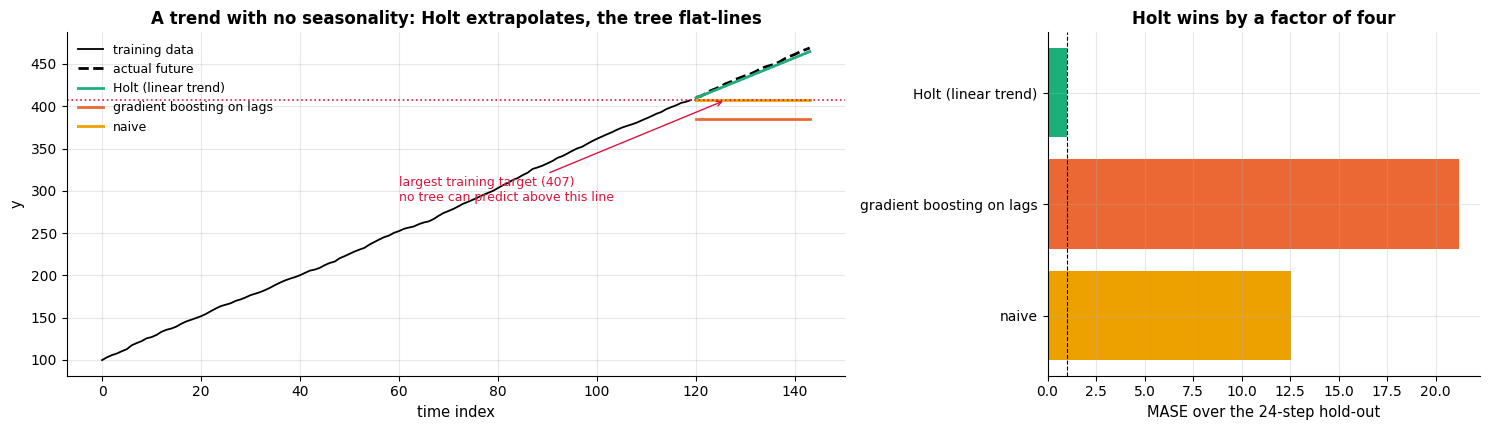

Holt (linear trend)          MASE  1.01   maximum forecast   464.7 (training maximum 407.4, actual maximum 469.0)
gradient boosting on lags    MASE 21.23   maximum forecast   384.9 (training maximum 407.4, actual maximum 469.0)
naive                        MASE 12.54   maximum forecast   407.4 (training maximum 407.4, actual maximum 469.0)


In [30]:
AIR_LAGS = [1, 2, 3, 11, 12, 13]      # the last three months and the months around "same month last year"


def gb_lag_forecast(y_hist, h, lags=AIR_LAGS, seasonal_feature=True, **kw):
    """Train a one-step gradient-boosting model on lag (+ calendar + trend) features and iterate it h steps.

    y_hist            the training series
    h                 the horizon
    lags              which lags of y to use as features
    seasonal_feature  if True, add the month (0 = January ... 11 = December) as a feature
    Returns an array of h forecasts (**kw swallows extra arguments such as m).
    """
    y_hist = np.asarray(y_hist, float)
    start = max(lags)                                        # the first position that has every lag
    pos = np.arange(start, len(y_hist))                      # target positions with a full set of lags
    design = pd.DataFrame({f"lag_{L}": y_hist[pos - L] for L in lags})   # one column per lag: y at positions pos - L
    if seasonal_feature:
        design["month"] = pos % 12                           # the airline series starts in January 1949
    design["t"] = pos                                        # a linear time index
    model = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, random_state=RANDOM_STATE)
    model.fit(design, y_hist[pos])
    history, out = list(y_hist), []
    for _ in range(h):                                       # recursive: feed each prediction back as a lag
        k = len(history)                                     # the position of the value to predict next
        row = {f"lag_{L}": [history[k - L]] for L in lags}   # a one-row table: every value wrapped in a list
        if seasonal_feature:
            row["month"] = [k % 12]
        row["t"] = [k]
        value = float(model.predict(pd.DataFrame(row))[0])   # predict returns an array of length 1
        history.append(value)
        out.append(value)
    return np.array(out)


# a trend with autocorrelated noise and no seasonality: 120 training points, 24 to forecast
trend_noise = np.cumsum(rng.normal(0, 1.2, 144)) * 0.5      # cumulative sum of random steps = a random walk
trend_series = 100 + 2.5 * np.arange(144) + trend_noise     # a straight line rising 2.5 per step, plus that noise
tr_train, tr_test = trend_series[:120], trend_series[120:]
trend_fits = {
    # fit alpha and beta, unpack them into holt, and keep [1], the forecast part of (fitted, forecast)
    "Holt (linear trend)": holt(tr_train, *fit_smoother(holt, tr_train, 2), H)[1],
    "gradient boosting on lags": gb_lag_forecast(tr_train, H, lags=(1, 2, 3), seasonal_feature=False),
    "naive": naive(tr_train, H),
}

# gridspec_kw={"width_ratios": [1.8, 1]} makes the left panel 1.8 times as wide as the right one
fig, axes = plt.subplots(1, 2, figsize=(15, 4.4), gridspec_kw={"width_ratios": [1.8, 1]})
axes[0].plot(np.arange(120), tr_train, color="black", lw=1.3, label="training data")
axes[0].plot(np.arange(120, 144), tr_test, color="black", lw=2, ls="--", label="actual future")
for (name, f), c in zip(trend_fits.items(), [PALETTE[2], PALETTE[1], PALETTE[3]]):
    axes[0].plot(np.arange(120, 144), f, lw=2, color=c, label=name)
axes[0].axhline(tr_train.max(), color="crimson", lw=1.2, ls=":")     # the largest training value
# annotate(text, xy=the point the arrow points at, xytext=where the text sits, arrowprops=the arrow's style)
axes[0].annotate(f"largest training target ({tr_train.max():.0f})\nno tree can predict above this line",
                 xy=(126, tr_train.max()), xytext=(60, tr_train.max() - 120), fontsize=9, color="crimson",
                 arrowprops=dict(arrowstyle="->", color="crimson", lw=1))
axes[0].set_xlabel("time index")
axes[0].set_ylabel("y")
axes[0].set_title("A trend with no seasonality: Holt extrapolates, the tree flat-lines")
axes[0].legend(fontsize=9, loc="upper left")
trend_scores = {k: mase(tr_test, v, tr_train, 1) for k, v in trend_fits.items()}   # m = 1: scaled by the naive error
# [::-1] reverses both lists, so the first method ends up at the top of the bar chart
axes[1].barh(list(trend_scores)[::-1], list(trend_scores.values())[::-1],
             color=[PALETTE[3], PALETTE[1], PALETTE[2]])
axes[1].axvline(1.0, color="black", lw=0.8, ls="--")       # MASE = 1 reference line
axes[1].set_xlabel("MASE over the 24-step hold-out")
axes[1].set_title("Holt wins by a factor of four")
plt.tight_layout()
plt.show()
for name, f in trend_fits.items():
    print(f"{name:28s} MASE {mase(tr_test, f, tr_train, 1):5.2f}   maximum forecast {f.max():7.1f} "
          f"(training maximum {tr_train.max():.1f}, actual maximum {tr_test.max():.1f})")

The boosted forecast is a flat line at the level of the last observations; Holt's two
parameters carry the slope forward and land on the future. Note that the tree is not even
beaten by a *little*: its MASE is several times Holt's, and the whole of its error is a
systematic downward bias that grows with the horizon.

Now the same failure on the real series. The airline data have both a trend and a strong
seasonality, so the boosted model has something real to learn — the seasonal shape — and it
learns it well. It still cannot climb.

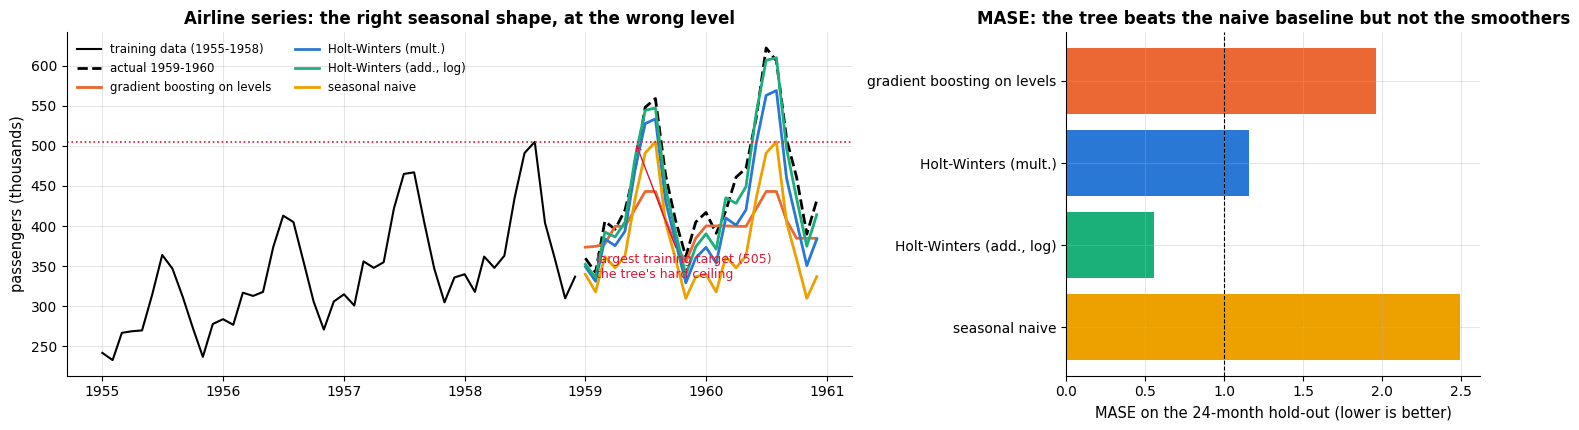

maximum of the training data: 505   maximum of the test data: 622
maximum the boosted model ever predicts: 443
mean forecast error, first 12 months:  +31.9   second 12 months:  +70.4  (always the same sign)


In [31]:
fc_gb_levels = gb_lag_forecast(y_train, H)       # default AIR_LAGS plus the month, on the raw passenger numbers
air_test_idx = air.index[-H:]                                # (section 4.5 reassigned `t_test`)
failure = {"gradient boosting on levels": fc_gb_levels, "Holt-Winters (mult.)": fc_hw,
           "Holt-Winters (add., log)": fc_hw_log, "seasonal naive": baseline_forecasts["seasonal naive"]}

fig, axes = plt.subplots(1, 2, figsize=(15, 4.4), gridspec_kw={"width_ratios": [1.9, 1]})
axes[0].plot(t_train[-48:], y_train[-48:], color="black", lw=1.5, label="training data (1955-1958)")
axes[0].plot(air_test_idx, y_test, color="black", lw=2, ls="--", label="actual 1959-1960")
for (name, f), c in zip(failure.items(), [PALETTE[1], PALETTE[0], PALETTE[2], PALETTE[3]]):
    axes[0].plot(air_test_idx, f, lw=2, color=c, label=name)
axes[0].axhline(y_train.max(), color="crimson", lw=1.2, ls=":")
axes[0].annotate(f"largest training target ({y_train.max():.0f})\nthe tree's hard ceiling",
                 xy=(air_test_idx[5], y_train.max()), xytext=(air_test_idx[1], y_train.max() - 170),
                 fontsize=9, color="crimson", arrowprops=dict(arrowstyle="->", color="crimson", lw=1))
axes[0].set_ylabel("passengers (thousands)")
axes[0].set_title("Airline series: the right seasonal shape, at the wrong level")
axes[0].legend(fontsize=8.5, loc="upper left", ncol=2)
scores = {name: mase(y_test, f, y_train, 12) for name, f in failure.items()}
axes[1].barh(list(scores)[::-1], list(scores.values())[::-1],
             color=[PALETTE[3], PALETTE[2], PALETTE[0], PALETTE[1]])
axes[1].axvline(1.0, color="black", lw=0.8, ls="--")
axes[1].set_xlabel("MASE on the 24-month hold-out (lower is better)")
axes[1].set_title("MASE: the tree beats the naive baseline but not the smoothers")
plt.tight_layout()
plt.show()
print(f"maximum of the training data: {y_train.max():.0f}   maximum of the test data: {y_test.max():.0f}")
print(f"maximum the boosted model ever predicts: {fc_gb_levels.max():.0f}")
# mean of actual minus forecast; the + in {...:+6.1f} always prints the sign (positive = forecast too low)
print(f"mean forecast error, first 12 months: {np.mean(y_test[:12] - fc_gb_levels[:12]):+6.1f}   "
      f"second 12 months: {np.mean(y_test[12:] - fc_gb_levels[12:]):+6.1f}  (always the same sign)")

Read the numbers carefully, because the honest version of this story is more instructive
than a caricature. The boosted model is *not* the worst forecast in the table — it
reproduces the summer peak and the November trough, which is enough to beat the
seasonal-naive baseline. But its highest prediction is 443, against an actual maximum of
622, and its error has the same sign in every single month and grows from the first year to
the second. That is not noise, it is the ceiling: the model has no mechanism for "higher
than anything I have seen". Holt–Winters, with three parameters, does, and it halves the
error.

### 7.5 The cure: let the model see a stationary target

The fix is the oldest idea in the notebook: **difference first**. Give the boosted model the
seasonally differenced log series $z_t = \log y_t - \log y_{t-12}$ — annual growth rates,
which *are* stationary and therefore live inside the training range — and integrate its
forecast back afterwards, exactly as we did for the AR model in section 3.4.

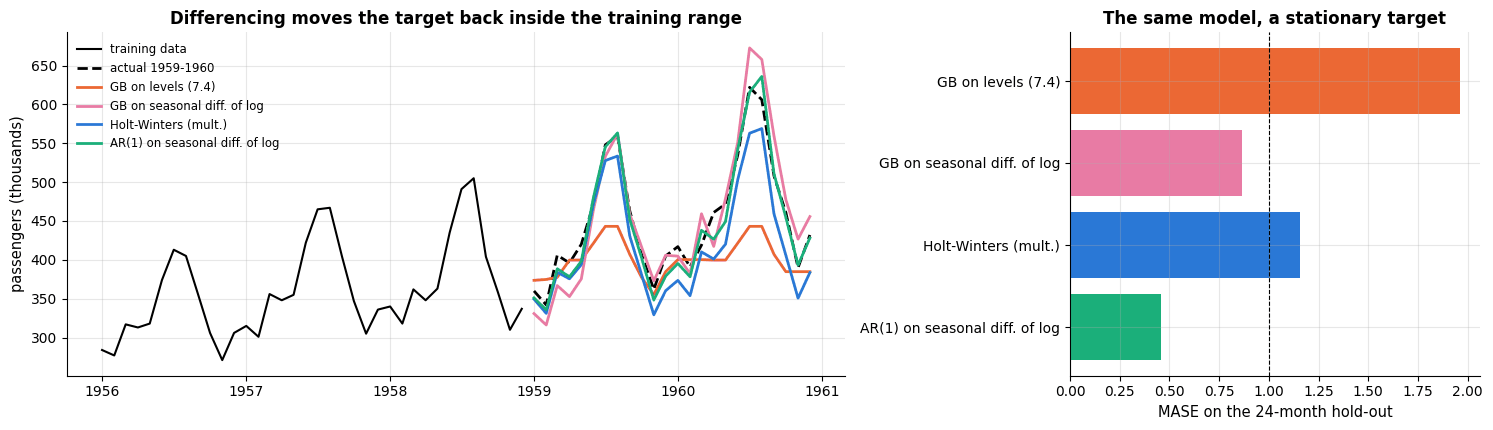

GB on levels (7.4)               MASE 1.96   sMAPE 12.2 %
GB on seasonal diff. of log      MASE 0.86   sMAPE 5.5 %
Holt-Winters (mult.)             MASE 1.16   sMAPE 7.6 %
AR(1) on seasonal diff. of log   MASE 0.46   sMAPE 3.0 %


In [32]:
def gb_diff_forecast(y_hist, h, lags=(1, 2, 3, 12), **kw):
    """The same boosted model, but fitted to the seasonally differenced logs and integrated back.

    y_hist  the training series (original scale); h  the horizon; lags  the lags of z used as features
    Returns h forecasts on the original scale (**kw swallows extra arguments such as m).
    """
    log_hist = np.log(np.asarray(y_hist, float))
    zz = log_hist[12:] - log_hist[:-12]                      # stationary target: annual growth rates
    start = max(lags)
    pos = np.arange(start, len(zz))
    design = pd.DataFrame({f"zlag_{L}": zz[pos - L] for L in lags})
    design["month"] = (pos + 12) % 12          # zz[i] belongs to original position i + 12; its month is (i + 12) % 12
    # min_samples_leaf=5 (the default is 20) allows smaller leaves: the training set is tiny (96 rows for y_train)
    model = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05,
                                          min_samples_leaf=5, random_state=RANDOM_STATE)
    model.fit(design, zz[pos])
    history, out = list(zz), []
    for _ in range(h):                                       # recursive, exactly as in gb_lag_forecast
        k = len(history)
        # {**a, "month": ...} merges the dict of lag columns and the month column into one dict
        row = pd.DataFrame({**{f"zlag_{L}": [history[k - L]] for L in lags}, "month": [(k + 12) % 12]})
        value = float(model.predict(row)[0])
        history.append(value)
        out.append(value)
    return undo_seasonal_log_difference(np.array(out), log_hist)   # growth-rate forecasts -> passenger numbers


fc_gb_diff = gb_diff_forecast(y_train, H)
cure = {"GB on levels (7.4)": fc_gb_levels, "GB on seasonal diff. of log": fc_gb_diff,
        "Holt-Winters (mult.)": fc_hw, f"AR({best_p}) on seasonal diff. of log": fc_ar}

fig, axes = plt.subplots(1, 2, figsize=(15, 4.4), gridspec_kw={"width_ratios": [1.9, 1]})
axes[0].plot(t_train[-36:], y_train[-36:], color="black", lw=1.5, label="training data")
axes[0].plot(air_test_idx, y_test, color="black", lw=2, ls="--", label="actual 1959-1960")
for (name, f), c in zip(cure.items(), [PALETTE[1], PALETTE[4], PALETTE[0], PALETTE[2]]):
    axes[0].plot(air_test_idx, f, lw=2, color=c, label=name)
axes[0].set_ylabel("passengers (thousands)")
axes[0].set_title("Differencing moves the target back inside the training range")
axes[0].legend(fontsize=8.5, loc="upper left")
cure_scores = {name: mase(y_test, f, y_train, 12) for name, f in cure.items()}
axes[1].barh(list(cure_scores)[::-1], list(cure_scores.values())[::-1],
             color=[PALETTE[2], PALETTE[0], PALETTE[4], PALETTE[1]])
axes[1].axvline(1.0, color="black", lw=0.8, ls="--")
axes[1].set_xlabel("MASE on the 24-month hold-out")
axes[1].set_title("The same model, a stationary target")
plt.tight_layout()
plt.show()
for name, f in cure.items():
    print(f"{name:32s} MASE {mase(y_test, f, y_train, 12):.2f}   sMAPE {smape(y_test, f):.1f} %")

One line of preprocessing more than halves the error of the boosted model and moves it past
Holt–Winters. Nothing about the trees changed — the same algorithm, the same lag features,
the same number of iterations — only the question they were asked: "what will the level be?"
became "what will the annual growth rate be?", and growth rates, unlike levels, stay inside
their historical range. (The two-parameter AR(1) on the same differenced series is still
ahead; on 120 observations that is exactly what section 7.6 predicts.) **The practical rule:
before putting a tree ensemble on a time series, difference, detrend or model the residuals
of a trend model; and always check whether your test targets lie outside the training
range.** (A linear model does not have this problem: ridge on a time index extrapolates a
straight line. That is one good reason to keep a linear model in a forecasting ensemble.)

### 7.6 The other side of the coin: machine learning needs data

The airline series is short, and that is the second reason the boosted model struggled.
The following experiment refits each family on progressively longer histories and forecasts
the next 12 months, so we can watch the ML model close the gap — or fail to.

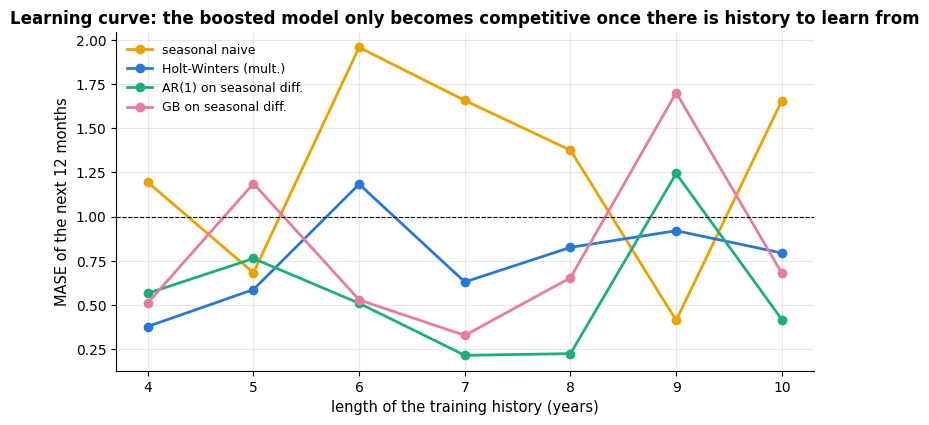

MASE at 4 years of history: {'seasonal naive': np.float64(1.19), 'Holt-Winters (mult.)': np.float64(0.38), 'AR(1) on seasonal diff.': np.float64(0.56), 'GB on seasonal diff.': np.float64(0.51)}
MASE at 10 years of history: {'seasonal naive': np.float64(1.66), 'Holt-Winters (mult.)': np.float64(0.79), 'AR(1) on seasonal diff.': np.float64(0.42), 'GB on seasonal diff.': np.float64(0.68)}


In [33]:
def hw_point_forecast(y_hist, h, **kw):
    """Multiplicative Holt-Winters (m = 12): fit the parameters on y_hist, return the h-step forecast."""
    # [1] keeps the forecast part of the (fitted, forecast) pair
    return holt_winters(y_hist, *fit_holt_winters(np.asarray(y_hist, float), m=12), m=12, h=h)[1]


def ar_point_forecast(y_hist, h, p=1, **kw):
    """AR(p) on the seasonally differenced logs of y_hist; returns h forecasts on the original scale."""
    log_hist = np.log(np.asarray(y_hist, float))
    zz = log_hist[12:] - log_hist[:-12]
    beta, _ = fit_ar(zz, p)
    return undo_seasonal_log_difference(forecast_ar(zz, beta, h), log_hist)


lengths = [48, 60, 72, 84, 96, 108, 120]                     # training histories of 4 to 10 years (in months)
# every method has the form f(history, h); the lambda fixes m = 12 for the seasonal naive
methods = {"seasonal naive": lambda yh, h: seasonal_naive(yh, h, m=12),
           "Holt-Winters (mult.)": hw_point_forecast,
           "AR(1) on seasonal diff.": ar_point_forecast,
           "GB on seasonal diff.": gb_diff_forecast}
curve = {name: [] for name in methods}                       # one list of scores per method
for L in lengths:
    hist, future = y_air[:L], y_air[L:L + 12]                # the first L months, and the 12 months after them
    for name, fn in methods.items():
        curve[name].append(mase(future, fn(hist, 12), hist, 12))

fig, ax = plt.subplots(figsize=(9, 4.4))
for (name, values), c in zip(curve.items(), [PALETTE[3], PALETTE[0], PALETTE[2], PALETTE[4]]):
    ax.plot(np.array(lengths) / 12, values, marker="o", lw=2, color=c, label=name)   # months -> years
ax.axhline(1.0, color="black", lw=0.8, ls="--")
ax.set_xlabel("length of the training history (years)")
ax.set_ylabel("MASE of the next 12 months")
ax.set_title("Learning curve: the boosted model only becomes competitive once there is history to learn from")
ax.legend(fontsize=9)
plt.show()
# v[0] is the score for the shortest history (4 years), v[-1] for the longest (10 years)
print("MASE at 4 years of history:", {k: round(v[0], 2) for k, v in curve.items()})
print("MASE at 10 years of history:", {k: round(v[-1], 2) for k, v in curve.items()})

With four years of history the boosted model has roughly 36 usable rows and six features:
it is fitting noise, and the two-parameter smoothing method beats it easily. As the history
grows the gap narrows but does not close — 120 monthly observations is still a tiny
training set. On the energy data of section 4 (17 000 hourly observations, temperature,
holidays and three seasonalities) the ordering is reversed, and gradient boosting halves the
error of the best baseline. **Sample size, not fashion, decides which family wins.**

## 8. Tuning guide

Every forecaster in this notebook has knobs. This section says which ones matter, in what
order to turn them, and — because a number without a picture is a number you cannot argue
with — shows a validation curve or a heat-map for each. The one rule that governs all of
them: **choose hyper-parameters by backtesting at the horizon you care about**, never by
in-sample fit and never by shuffled cross-validation.

### 8.1 What each knob does

**Exponential smoothing**

| Parameter | Controls | Range / scale | Effect of increasing | Default / typical |
|---|---|---|---|---|
| $\alpha$ (`smoothing_level`) | how fast the **level** follows the data | $(0, 1)$, linear | tracks recent data more, noisier level | 0.1–0.3 for smooth series, → 1 for noisy-but-persistent ones |
| $\beta$ (`smoothing_trend`) | how fast the **slope** adapts | $(0, 1)$, linear (usually $\ll \alpha$) | trend chases recent changes; long-horizon forecasts get wild | 0.01–0.1 |
| $\gamma$ (`smoothing_seasonal`) | how fast the **seasonal indices** adapt | $(0, 1)$, linear | seasonality follows the last year closely | 0.1–0.5 |
| $\phi$ (`damping_trend`) | how much the trend is **damped** with the horizon | $(0.8, 1]$, linear | less damping; $\phi = 1$ is the undamped Holt method | 0.9–0.98 |
| seasonal form | additive vs. multiplicative | — | multiplicative when the swing grows with the level | choose by plotting, or model $\log y$ |
| $m$ | the seasonal period | known from the calendar | — | **not a tuning parameter** — 12 for monthly, 24/168 for hourly |

**ARIMA**

| Parameter | Controls | Range / scale | Effect of increasing | Default / typical |
|---|---|---|---|---|
| $d$, $D$ | differencing (ordinary / seasonal) | 0–2, 0–1 | removes trend / seasonality; over-differencing adds noise | choose by eye + unit-root test, then stop |
| $p$, $P$ | autoregressive order | 0–5, 0–2 | fits more of the ACF; overfits quickly | read the PACF, confirm with AIC **and** a backtest |
| $q$, $Q$ | moving-average order | 0–5, 0–2 | models shock persistence | read the ACF |
| trend / constant | drift in the differenced series | on/off | adds a deterministic slope | on when the differenced series has a non-zero mean |

**Machine-learning forecaster** (tree knobs — `learning_rate`, `max_iter`, `max_leaf_nodes` — are exactly those of notebook 10; the *forecasting* knobs are new)

| Parameter | Controls | Range / scale | Effect of increasing | Default / typical |
|---|---|---|---|---|
| lag set | which past values the model sees | $\{h, h+1, \dots\} \cup \{m, 2m\}$ | more memory, more parameters, more warm-up rows lost | the horizon, the horizon + 1, one season, two seasons |
| rolling-window sizes | how much smoothing of the recent past | 3 … several seasons, **log** | the feature becomes a slow level instead of a fast one | one short (3–6), one seasonal ($m$), one long ($7m$) |
| Fourier terms $K$ per period | smoothness of the seasonal curve | 1–10, linear | more wiggle; overfits above ~$m/2$ | 2–3 for a daily double peak, 1–2 for a weekly cycle, 5–10 for a yearly one |
| horizon $h$ | what the model is trained to predict | fixed by the application | error grows, then saturates | — |
| direct vs. recursive | one model per horizon, or one iterated model | — | direct: no error feedback, more models; recursive: cheap, errors compound | recursive by default, direct for long horizons |
| training-window length | how much history to fit on | expanding vs. rolling | expanding uses everything; rolling forgets regime changes | expanding, unless the process has clearly changed |

### 8.2 Tune in this order

1. **Get the target right first.** Transformation (log?), differencing, and the seasonal
   period $m$. Nothing downstream can repair a non-stationary target given to a tree
   (section 7.4) or a multiplicative series modelled additively.
2. **Exponential smoothing:** $\alpha$ first — it dominates. Then $\gamma$ if the series is
   seasonal. $\beta$ and $\phi$ last and *together*: they interact strongly, because a large
   $\beta$ with $\phi = 1$ is what makes long-horizon forecasts explode. A useful shortcut:
   fit $\alpha, \beta, \gamma$ by in-sample likelihood/SSE (section 3.3) and then check only
   $\phi$ and $\alpha$ by backtesting.
3. **ARIMA:** $d$ and $D$ from the plots, then $p$ and $q$ from the PACF/ACF, confirmed by
   AIC, confirmed again by a backtest. Orders above 2–3 almost never survive the backtest.
4. **ML forecaster:** the *features* are the hyper-parameters that matter — lag set, then
   Fourier terms, then rolling windows. The tree parameters come last and buy little
   (learning rate 0.05 with a few hundred iterations is fine); see notebook 10.

### 8.3 $\alpha$: a validation curve from backtesting

`fit_holt_winters` minimises the one-step in-sample error. That is a different objective
from "forecast the next twelve months well". Let us plot the backtested MASE as a function
of $\alpha$ with $\beta$ and $\gamma$ held at their in-sample optima, over six rolling
origins, and compare the two choices.

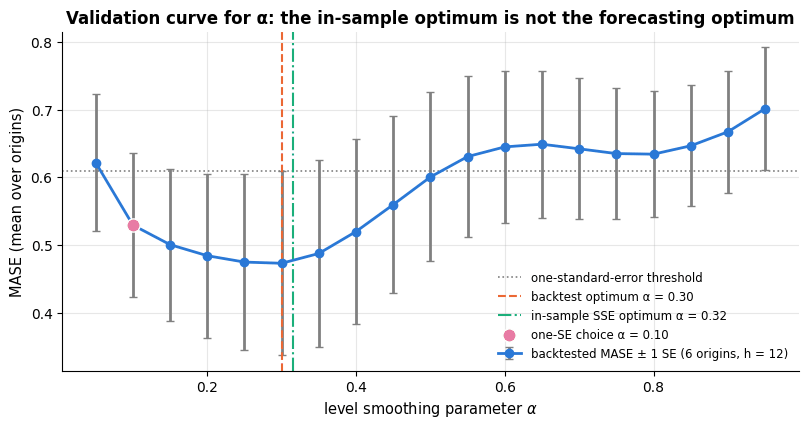

backtested MASE at the in-sample α: 0.475; at the backtest optimum: 0.473


In [34]:
def hw_forecaster(y, h, params=(0.3, 0.05, 0.3), m=12, seasonal="multiplicative", **kw):
    """Holt-Winters wrapped in the forecaster interface expected by `rolling_origin_backtest`.

    params is a fixed (alpha, beta, gamma) triple: nothing is fitted here. Returns only the h-step forecast.
    """
    return holt_winters(y, *params, m=m, h=h, seasonal=seasonal)[1]


def hw_backtest(params, y=None, horizon=12, n_origins=6, step=6):
    """Mean and standard error of the backtested MASE for one parameter triple.

    params  (alpha, beta, gamma); y  the series to backtest on (default: y_train)
    Returns (mean MASE over the origins, its standard error = std / sqrt(number of origins)).
    """
    # params and m are passed on to hw_forecaster; m = 12 also sets the period of the MASE
    bt = rolling_origin_backtest(y_train if y is None else y, hw_forecaster, horizon, n_origins,
                                 step=step, params=tuple(params), m=12)
    return bt["MASE"].mean(), bt["MASE"].std(ddof=1) / np.sqrt(len(bt))     # ddof=1: sample std (divides by n - 1)


alphas = np.linspace(0.05, 0.95, 19)            # 19 values in steps of 0.05
# beta and gamma stay at their in-sample optimum; shape (19, 2): column 0 = mean MASE, column 1 = its standard error
alpha_curve = np.array([hw_backtest((a, hw_params[1], hw_params[2])) for a in alphas])
best_i = int(np.argmin(alpha_curve[:, 0]))      # position of the lowest mean MASE
one_se = alpha_curve[best_i, 0] + alpha_curve[best_i, 1]           # best score plus one standard error
# alpha_curve[:, 0] <= one_se is a boolean array; argmax returns the position of its first True
simplest = alphas[np.argmax(alpha_curve[:, 0] <= one_se)]          # smallest alpha within one SE

fig, ax = plt.subplots(figsize=(9.5, 4.4))
# errorbar: points joined by a line (fmt="o-") with ± yerr bars; capsize is the width of the bar ends
ax.errorbar(alphas, alpha_curve[:, 0], yerr=alpha_curve[:, 1], fmt="o-", color=PALETTE[0],
            ecolor="gray", capsize=3, label="backtested MASE ± 1 SE (6 origins, h = 12)")
ax.axhline(one_se, color="gray", ls=":", lw=1.2, label="one-standard-error threshold")
ax.axvline(alphas[best_i], color=PALETTE[1], ls="--", lw=1.5, label=f"backtest optimum α = {alphas[best_i]:.2f}")
ax.axvline(hw_params[0], color=PALETTE[2], ls="-.", lw=1.5, label=f"in-sample SSE optimum α = {hw_params[0]:.2f}")
ax.scatter([simplest], [alpha_curve[np.argmax(alpha_curve[:, 0] <= one_se), 0]], s=90, zorder=5,
           color=PALETTE[4], edgecolor="white", label=f"one-SE choice α = {simplest:.2f}")
ax.set_xlabel(r"level smoothing parameter $\alpha$")
ax.set_ylabel("MASE (mean over origins)")
ax.set_title("Validation curve for α: the in-sample optimum is not the forecasting optimum")
ax.legend(fontsize=8.5)
plt.show()
print(f"backtested MASE at the in-sample α: {hw_backtest(hw_params)[0]:.3f}; "
      f"at the backtest optimum: {alpha_curve[best_i, 0]:.3f}")

The curve is U-shaped and shallow near its minimum, which is the usual picture: a broad
range of $\alpha$ forecasts about equally well, and the **one-standard-error rule** —
choose the simplest (here: the smallest, i.e. most smoothing) value whose score is within
one standard error of the best — protects you from chasing noise in the backtest.

### 8.4 $\alpha$ and $\beta$ interact: a two-dimensional heat-map

$\alpha$ and $\beta$ are the pair that must be looked at together. A fast level ($\alpha$
large) makes the level jump, and a fast slope ($\beta$ large) then amplifies those jumps
into the forecast; the two together determine how far ahead the method dares to extrapolate.

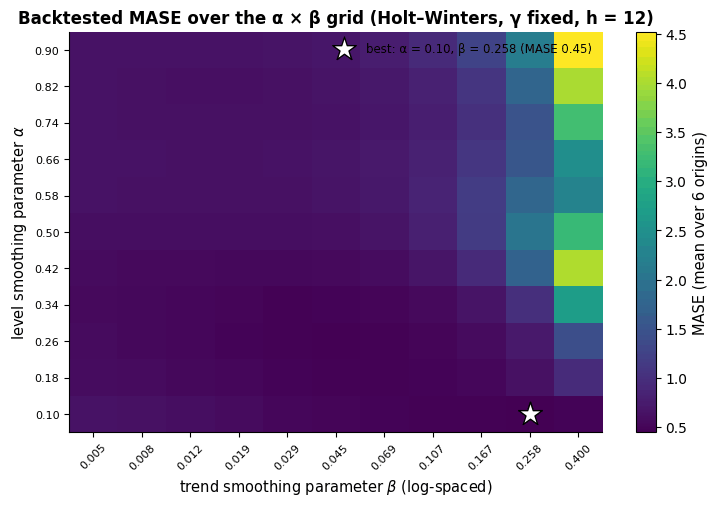

MASE range over the grid: 0.45 – 4.52; the worst corner is α = 0.90, β = 0.400


In [35]:
# np.logspace(a, b, n): n values from 10**a to 10**b, evenly spaced on a log scale (here 0.005 .. 0.4)
betas = np.round(np.logspace(np.log10(0.005), np.log10(0.4), 11), 4)
alpha_grid = np.round(np.linspace(0.1, 0.9, 11), 3)
# nested comprehension: one row per alpha, one column per beta -> shape (11, 11); [0] keeps the mean MASE
heat = np.array([[hw_backtest((a, b, hw_params[2]))[0] for b in betas] for a in alpha_grid])
# argmin returns a position in the flattened array; unravel_index turns it into (row, column) = (alpha, beta)
ia, ib = np.unravel_index(np.argmin(heat), heat.shape)

fig, ax = plt.subplots(figsize=(8.6, 5.2))
# draw the matrix as coloured cells; origin="lower" puts row 0 at the bottom, aspect="auto" fills the panel
im = ax.imshow(heat, origin="lower", cmap="viridis", aspect="auto")
# in imshow coordinates x is the column (beta) index and y the row (alpha) index
ax.scatter([ib], [ia], marker="*", s=320, color="white", edgecolor="black", zorder=5,
           label=f"best: α = {alpha_grid[ia]:.2f}, β = {betas[ib]:.3f} (MASE {heat[ia, ib]:.2f})")
ax.set_xticks(range(len(betas)))
ax.set_xticklabels([f"{b:.3f}" for b in betas], rotation=45, fontsize=8)
ax.set_yticks(range(len(alpha_grid)))
ax.set_yticklabels([f"{a:.2f}" for a in alpha_grid], fontsize=8)
ax.set_xlabel(r"trend smoothing parameter $\beta$ (log-spaced)")
ax.set_ylabel(r"level smoothing parameter $\alpha$")
ax.set_title("Backtested MASE over the α × β grid (Holt–Winters, γ fixed, h = 12)")
ax.grid(False)
plt.colorbar(im, ax=ax, label="MASE (mean over 6 origins)")     # the colour scale next to the panel
ax.legend(loc="upper right", fontsize=8.5)
plt.show()
print(f"MASE range over the grid: {heat.min():.2f} – {heat.max():.2f}; "
      f"the worst corner is α = {alpha_grid[np.unravel_index(np.argmax(heat), heat.shape)[0]]:.2f}, "
      f"β = {betas[np.unravel_index(np.argmax(heat), heat.shape)[1]]:.3f}")

The diagonal structure is the interaction: the damage done by a large $\beta$ depends on
$\alpha$. The safe region — the dark band — is "moderate level adaptation, slow trend
adaptation", which is exactly the folklore advice $\beta \ll \alpha$, now measured rather
than asserted.

### 8.5 $\gamma$ and the damping parameter $\phi$

$\gamma$ decides how quickly the seasonal profile is allowed to change. With $\gamma$ near
zero the indices are frozen at their initial estimate; with $\gamma$ near one the model
believes last year's seasonality completely. $\phi$ is the one parameter that only shows its
effect *far ahead*, so it cannot be tuned at a one-step horizon at all. We implement the
damped variant and check that $\phi = 1$ reproduces section 3.3 exactly.

phi = 1 reproduces the undamped holt_winters: True


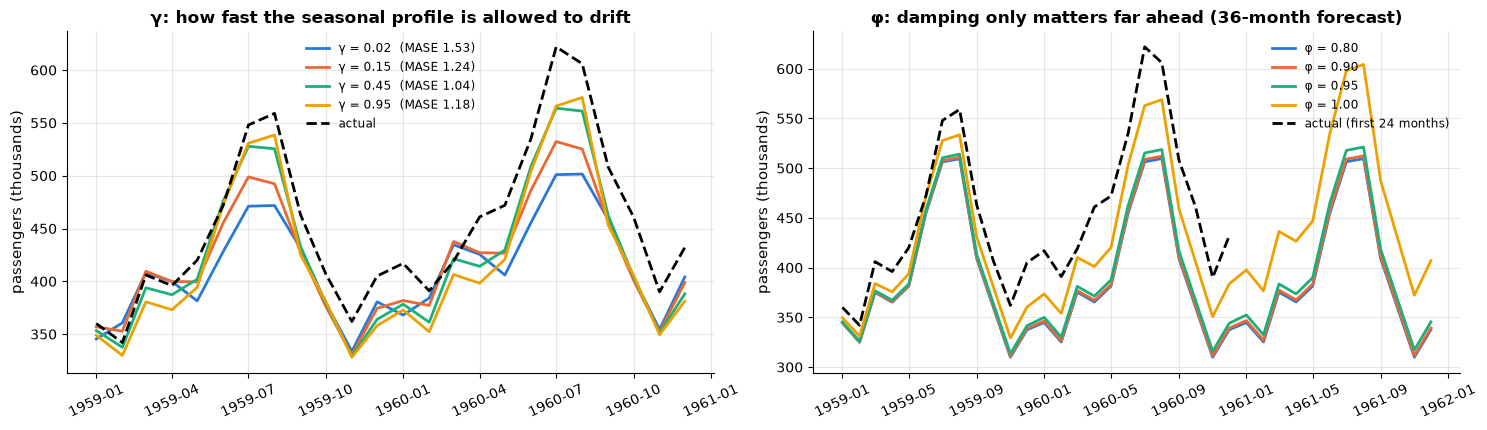

phi = 0.80: MASE over the 24-month hold-out = 2.18
phi = 0.90: MASE over the 24-month hold-out = 2.13
phi = 0.95: MASE over the 24-month hold-out = 2.01
phi = 1.00: MASE over the 24-month hold-out = 1.16


In [36]:
def holt_winters_damped(y, alpha, beta, gamma, phi, m, h, seasonal="multiplicative"):
    """Holt-Winters with a damped trend (Gardner & McKenzie, 1985); phi = 1 is the undamped method.

    The same arguments and return value as holt_winters, plus the damping parameter phi (0 < phi <= 1):
    the slope is multiplied by phi at every step, so the forecast trend flattens out with the horizon.
    """
    y = np.asarray(y, float)
    n = len(y)
    level = y[:m].mean()
    slope = (y[m:2 * m].mean() - y[:m].mean()) / m
    season = list(y[:m] / level) if seasonal == "multiplicative" else list(y[:m] - level)
    fitted = np.full(n, np.nan)
    for t in range(m, n):
        s_prev, trend = season[t - m], phi * slope           # the damped slope phi * b_{t-1} replaces b_{t-1} below
        if seasonal == "multiplicative":
            fitted[t] = (level + trend) * s_prev
            new_level = alpha * (y[t] / s_prev) + (1 - alpha) * (level + trend)
            season.append(gamma * (y[t] / (level + trend)) + (1 - gamma) * s_prev)
        else:
            fitted[t] = level + trend + s_prev
            new_level = alpha * (y[t] - s_prev) + (1 - alpha) * (level + trend)
            season.append(gamma * (y[t] - level - trend) + (1 - gamma) * s_prev)
        slope = beta * (new_level - level) + (1 - beta) * trend
        level = new_level
    steps = np.arange(1, h + 1)
    damp = np.cumsum(phi ** steps)                       # phi + phi^2 + ... + phi^h
    s_future = np.array([season[n - m + (i - 1) % m] for i in steps])
    forecast = ((level + damp * slope) * s_future if seasonal == "multiplicative"
                else level + damp * slope + s_future)
    return fitted, forecast


# positional arguments: alpha, beta, gamma (from hw_params), phi = 1.0, m = 12, h = H
check = holt_winters_damped(y_train, *hw_params, 1.0, 12, H)[1]
print("phi = 1 reproduces the undamped holt_winters:", np.allclose(check, fc_hw))

gammas = [0.02, 0.15, 0.45, 0.95]
phis = [0.80, 0.90, 0.95, 1.00]
LONG = 36                                                # a three-year horizon, to make damping visible
fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))
for g, c in zip(gammas, PALETTE):                        # zip stops at the shorter list: one colour per gamma
    fc_g = holt_winters(y_train, hw_params[0], hw_params[1], g, m=12, h=H)[1]   # only gamma changes
    axes[0].plot(air_test_idx, fc_g, lw=2, color=c,
                 label=f"γ = {g:.2f}  (MASE {mase(y_test, fc_g, y_train, 12):.2f})")
axes[0].plot(air_test_idx, y_test, color="black", lw=2, ls="--", label="actual")
axes[0].set_ylabel("passengers (thousands)")
axes[0].set_title("γ: how fast the seasonal profile is allowed to drift")
axes[0].legend(fontsize=8.5)
# pd.date_range(start, periods, freq="MS") makes month-start dates: 36 dates from Jan 1959 to Dec 1961;
# step 1 of the forecast is the first hold-out month air.index[-H], so the first 24 dates equal air_test_idx
future_idx = pd.date_range(air.index[-H], periods=LONG, freq="MS")
for p, c in zip(phis, PALETTE):
    fc_p = holt_winters_damped(y_train, *hw_params, p, 12, LONG)[1]     # 36-month forecast with phi = p
    axes[1].plot(future_idx, fc_p, lw=2, color=c, label=f"φ = {p:.2f}")
axes[1].plot(air_test_idx, y_test, color="black", lw=2, ls="--", label="actual (first 24 months)")
axes[1].set_title("φ: damping only matters far ahead (36-month forecast)")
axes[1].set_ylabel("passengers (thousands)")
axes[1].legend(fontsize=8.5)
for ax in axes:
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()
for p in phis:
    fc_p = holt_winters_damped(y_train, *hw_params, p, 12, H)[1]
    print(f"phi = {p:.2f}: MASE over the 24-month hold-out = {mase(y_test, fc_p, y_train, 12):.2f}")

The $\gamma$ panel shows the mechanism: a tiny $\gamma$ keeps the 1949–1950 seasonal shape
and mis-sizes the 1960 summer peak, while a large $\gamma$ copies the most recent year and
overshoots. The $\phi$ panel shows why damping is a horizon-dependent decision: over 24
months the four curves are almost indistinguishable, but by month 36 the undamped forecast
is noticeably higher. On a *growing* series like this one, damping costs a little accuracy;
on the many M-competition series whose trends flatten out, it is the single most reliable
improvement you can make (Gardner, 1985).

### 8.6 The autoregressive order $p$

Section 3.4 chose $p$ by AIC. AIC is an in-sample criterion with an asymptotic
justification; a backtest is a direct measurement. Here they are side by side.

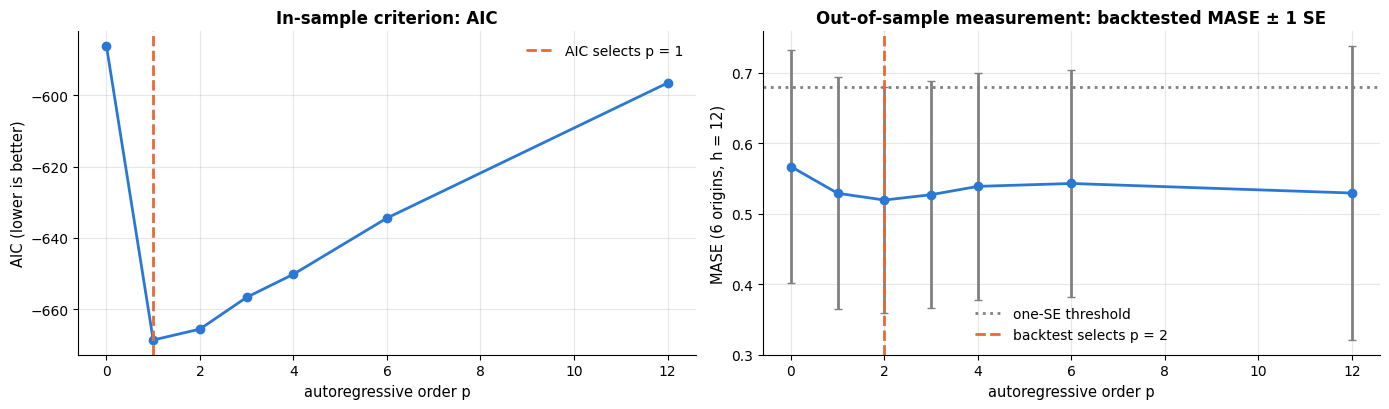

backtested MASE by order p: {0: np.float64(0.567), 1: np.float64(0.529), 2: np.float64(0.519), 3: np.float64(0.527), 4: np.float64(0.539), 6: np.float64(0.543), 12: np.float64(0.529)}


In [37]:
def ar_forecaster(y, h, p=1, m=12, **kw):
    """AR(p) on the seasonally differenced log series, integrated back — as a backtestable forecaster.

    p is the AR order. m is not used (the seasonal difference is always 12); it arrives because
    rolling_origin_backtest passes its keyword arguments, including the MASE period m, to the forecaster.
    """
    log_hist = np.log(np.asarray(y, float))
    zz = log_hist[12:] - log_hist[:-12]
    beta, _ = fit_ar(zz, p)
    return undo_seasonal_log_difference(forecast_ar(zz, beta, h), log_hist)


p_grid = [0, 1, 2, 3, 4, 6, 12]
p_rows = []
for p in p_grid:
    # horizon 12, 6 origins 6 months apart; p and m are passed on to ar_forecaster
    bt = rolling_origin_backtest(y_train, ar_forecaster, 12, 6, step=6, p=p, m=12)
    p_rows.append((bt["MASE"].mean(), bt["MASE"].std(ddof=1) / np.sqrt(len(bt))))   # (mean, standard error)
p_bt = np.array(p_rows)                         # shape (7, 2): one row per order
p_best = int(np.argmin(p_bt[:, 0]))             # a position in p_grid, not the order itself

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].plot(ar_table.index, ar_table["AIC"], marker="o", color=PALETTE[0])     # the AIC table of section 3.4
axes[0].axvline(best_p, color=PALETTE[1], ls="--", label=f"AIC selects p = {best_p}")
axes[0].set_xlabel("autoregressive order p")
axes[0].set_ylabel("AIC (lower is better)")
axes[0].set_title("In-sample criterion: AIC")
axes[0].legend()
axes[1].errorbar(p_grid, p_bt[:, 0], yerr=p_bt[:, 1], fmt="o-", color=PALETTE[0], ecolor="gray", capsize=3)
axes[1].axhline(p_bt[p_best, 0] + p_bt[p_best, 1], color="gray", ls=":", label="one-SE threshold")
axes[1].axvline(p_grid[p_best], color=PALETTE[1], ls="--", label=f"backtest selects p = {p_grid[p_best]}")
axes[1].set_xlabel("autoregressive order p")
axes[1].set_ylabel("MASE (6 origins, h = 12)")
axes[1].set_title("Out-of-sample measurement: backtested MASE ± 1 SE")
axes[1].legend()
plt.tight_layout()
plt.show()
print("backtested MASE by order p:", {p: round(v, 3) for p, v in zip(p_grid, p_bt[:, 0])})

Both criteria agree on a very low order, and both curves rise steeply afterwards: with
about 100 usable observations, an AR(12) has twelve coefficients to estimate and no data to
estimate them with. When AIC and the backtest *disagree*, trust the backtest — it measures
what you are being paid for.

### 8.7 The features are the hyper-parameters (energy data)

For the machine-learning forecaster the tree parameters matter far less than the feature
table. We hold out the last six weeks of the *training* period as a validation block (never
the test period) and ablate the feature families, then sweep the rolling-window size.

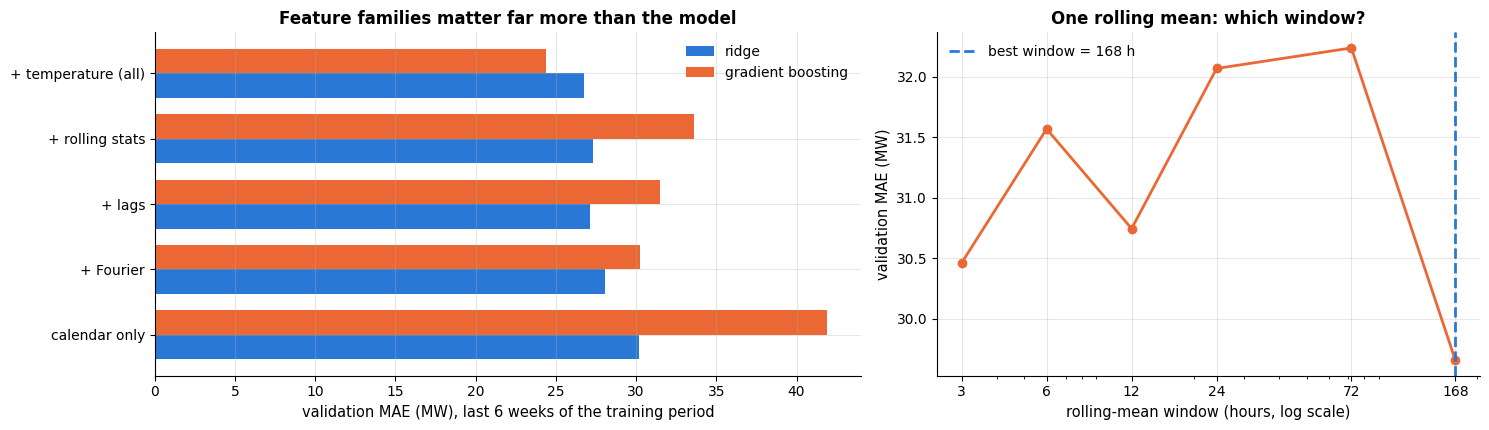

,ridge,gradient boosting
calendar only,30.2,41.9
+ Fourier,28.0,30.3
+ lags,27.1,31.5
+ rolling stats,27.3,33.6
+ temperature (all),26.8,24.4


In [38]:
VAL_HOURS = 24 * 7 * 6                          # six weeks
# fit on the training period minus its last six weeks, validate on those six weeks (the test period stays unused)
X_fit_v, y_fit_v = X_tr.iloc[:-VAL_HOURS], y_tr.iloc[:-VAL_HOURS]
X_val_v, y_val_v = X_tr.iloc[-VAL_HOURS:], y_tr.iloc[-VAL_HOURS:]
lag_cols = [c for c in X.columns if c.startswith("lag_")]           # pick the columns by their name prefix
roll_cols = [c for c in X.columns if c.startswith("roll_")]
fourier_cols = [c for c in X.columns if c.startswith(("sin_", "cos_"))]   # startswith accepts a tuple of prefixes
cal_cols = ["hour", "dayofweek", "month", "is_holiday", "trend_years"]

# every set adds one feature family to the previous one
feature_sets = {"calendar only": cal_cols,
                "+ Fourier": cal_cols + fourier_cols,
                "+ lags": cal_cols + fourier_cols + lag_cols,
                "+ rolling stats": cal_cols + fourier_cols + lag_cols + roll_cols,
                "+ temperature (all)": list(X.columns)}


def validate(cols, model):
    """Validation MAE of `model` trained on the given columns (time-ordered split, no leakage).

    cols   the list of feature columns to use
    model  a scikit-learn estimator; it is (re)fitted on the fitting block and scored on the validation block
    """
    return mae(y_val_v, model.fit(X_fit_v[cols], y_fit_v).predict(X_val_v[cols]))


def ridge_on(cols):
    """Ridge pipeline for the columns `cols`: one-hot encode hour/weekday/month, standardise all other columns."""
    # the calendar columns to one-hot encode (is_holiday and trend_years are treated as numbers)
    cal = [c for c in cal_cols if c in cols and c in ("hour", "dayofweek", "month")]
    num = [c for c in cols if c not in cal]
    return make_pipeline(ColumnTransformer([("num", StandardScaler(), num),
                                            ("cal", OneHotEncoder(handle_unknown="ignore"), cal)]), Ridge(alpha=1.0))


# fewer, larger boosting steps than before: quicker for the many refits of this section
small_gb = HistGradientBoostingRegressor(max_iter=80, learning_rate=0.15, random_state=RANDOM_STATE)
ablation = pd.DataFrame({"ridge": [validate(c, ridge_on(c)) for c in feature_sets.values()],
                         "gradient boosting": [validate(c, small_gb) for c in feature_sets.values()]},
                        index=list(feature_sets))          # rows = feature sets, columns = models

windows = [3, 6, 12, 24, 72, 168]                          # rolling-mean window sizes to try (hours)
window_mae = []
for w in windows:
    past = energy["demand_mw"].shift(HORIZON)              # the series as known at the origin (no leakage)
    col = past.rolling(w).mean().reindex(X.index)          # .reindex(X.index): keep only X's timestamps, in X's order
    cols_w = cal_cols + fourier_cols + lag_cols
    Xw = X[cols_w].assign(roll_mean=col)                   # .assign returns a copy with one extra column, roll_mean
    # the same rows as X_fit_v / X_val_v
    fitw, valw = Xw.iloc[:len(X_fit_v)], Xw.iloc[len(X_fit_v):len(X_fit_v) + VAL_HOURS]
    window_mae.append(mae(y_val_v, small_gb.fit(fitw, y_fit_v).predict(valw)))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.4), gridspec_kw={"width_ratios": [1.3, 1]})
# pandas plotting: one group of horizontal bars per row (feature set), one bar per column (model)
ablation.plot.barh(ax=axes[0], color=[PALETTE[0], PALETTE[1]], width=0.75)
axes[0].set_xlabel("validation MAE (MW), last 6 weeks of the training period")
axes[0].set_title("Feature families matter far more than the model")
axes[0].legend(title="")
axes[1].plot(windows, window_mae, marker="o", color=PALETTE[1])
axes[1].set_xscale("log")
axes[1].set_xticks(windows)                    # ticks at the window sizes, labelled with the plain numbers
axes[1].set_xticklabels(windows)
axes[1].axvline(windows[int(np.argmin(window_mae))], color=PALETTE[0], ls="--",
                label=f"best window = {windows[int(np.argmin(window_mae))]} h")
axes[1].set_xlabel("rolling-mean window (hours, log scale)")
axes[1].set_ylabel("validation MAE (MW)")
axes[1].set_title("One rolling mean: which window?")
axes[1].legend()
plt.tight_layout()
plt.show()
display(ablation.round(1))

Two lessons. First, the ranking of feature *families* is identical for a linear model and a
tree ensemble, and the jumps are much larger than anything the tree hyper-parameters would
buy: lags are worth more than everything else combined. Second, the rolling-window sweep is
flat over a wide range — evidence that one short and one seasonal window is enough, and that
adding five more is wasted effort.

### 8.8 How many Fourier harmonics?

Fourier terms are the knob that separates linear models from trees. For a *linear* model,
$K$ harmonics of period 24 are the only way to express the daily double peak; a tree carves
the same shape out of the integer `hour` feature and barely notices. To see the effect
cleanly we use a purely numeric ridge model (no hour/weekday dummies) so that the harmonics
carry the whole seasonal signal.

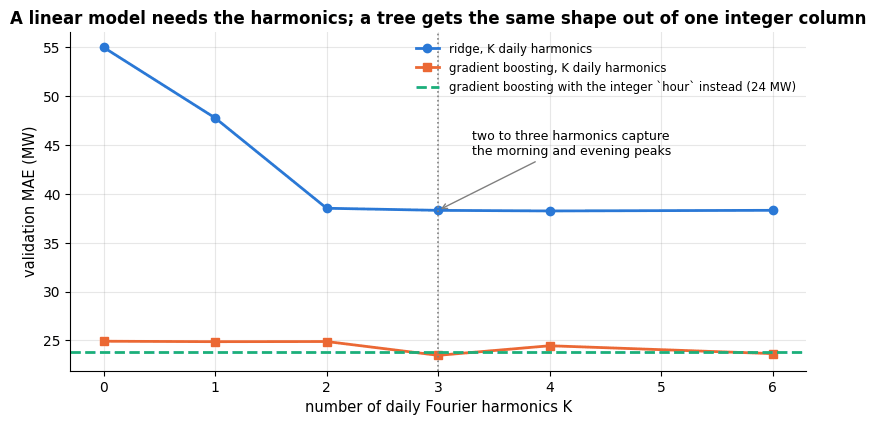

ridge validation MAE by K:            {0: 55.0, 1: 47.8, 2: 38.5, 3: 38.3, 4: 38.3, 6: 38.3}
gradient boosting by K:               {0: 24.9, 1: 24.9, 2: 24.9, 3: 23.5, 4: 24.5, 6: 23.6}
gradient boosting with `hour` only:   23.8 MW


In [39]:
# make_features dropped the warm-up rows at the start, so X's rows are positions len(energy) - len(X) onwards
POS = np.arange(len(energy) - len(X), len(energy))            # position of each row in the original series
# Deliberately *no* lag features here: the daily shape must come from the harmonics alone,
# otherwise lag_24h would hand the daily profile to both models for free.
# (the trailing \ continues the statement on the next line)
numeric_base = ["is_holiday", "temperature_c", "trend_years"] + \
               [c for c in X.columns if c.startswith(("sin_week", "cos_week", "sin_year", "cos_year"))]


def with_k_harmonics(K):
    """Feature table: the numeric_base columns plus K daily sine/cosine pairs (K = 0: no daily information at all)."""
    cols = {f"sin_day{k}": np.sin(2 * np.pi * k * POS / 24) for k in range(1, K + 1)}   # computed at each row's position
    cols.update({f"cos_day{k}": np.cos(2 * np.pi * k * POS / 24) for k in range(1, K + 1)})
    # pd.concat(..., axis=1) puts the two tables side by side (they share X's index)
    return pd.concat([X[numeric_base], pd.DataFrame(cols, index=X.index)], axis=1)


k_grid = [0, 1, 2, 3, 4, 6]
ridge_numeric = make_pipeline(StandardScaler(), Ridge(alpha=1.0))     # plain numeric ridge: no one-hot calendar columns
ridge_k, gb_k = [], []
for K in k_grid:
    Xk = with_k_harmonics(K)
    fitk, valk = Xk.iloc[:len(X_fit_v)], Xk.iloc[len(X_fit_v):len(X_fit_v) + VAL_HOURS]   # same split as in 8.7
    ridge_k.append(mae(y_val_v, ridge_numeric.fit(fitk, y_fit_v).predict(valk)))
    gb_k.append(mae(y_val_v, small_gb.fit(fitk, y_fit_v).predict(valk)))

# the tree's alternative to harmonics: the raw integer `hour` column, no Fourier terms at all
X_hour = X[numeric_base].assign(hour=X["hour"])
gb_hour = mae(y_val_v, small_gb.fit(X_hour.iloc[:len(X_fit_v)], y_fit_v)
              .predict(X_hour.iloc[len(X_fit_v):len(X_fit_v) + VAL_HOURS]))     # the method chain continues inside ( )

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.plot(k_grid, ridge_k, marker="o", lw=2, color=PALETTE[0], label="ridge, K daily harmonics")
ax.plot(k_grid, gb_k, marker="s", lw=2, color=PALETTE[1], label="gradient boosting, K daily harmonics")
ax.axhline(gb_hour, color=PALETTE[2], ls="--", lw=2,
           label=f"gradient boosting with the integer `hour` instead ({gb_hour:.0f} MW)")
ax.axvline(3, color="gray", ls=":", lw=1.2)
ax.annotate("two to three harmonics capture\nthe morning and evening peaks",
            xy=(3, ridge_k[3]), xytext=(3.3, max(ridge_k) * 0.8), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="gray"))
ax.set_xlabel("number of daily Fourier harmonics K")
ax.set_ylabel("validation MAE (MW)")
ax.set_title("A linear model needs the harmonics; a tree gets the same shape out of one integer column")
ax.legend(fontsize=8.5)
plt.show()
print("ridge validation MAE by K:           ", {K: round(v, 1) for K, v in zip(k_grid, ridge_k)})
print("gradient boosting by K:              ", {K: round(v, 1) for K, v in zip(k_grid, gb_k)})
print(f"gradient boosting with `hour` only:   {gb_hour:.1f} MW")

Both curves fall steeply from $K = 0$ — a model with no daily information at all — and
flatten after two or three harmonics, which is what a double-peaked daily profile needs.
The dashed line is the point: a tree handed the raw integer `hour` reaches the same place
without any harmonics, because splitting on an integer *is* a piecewise-constant seasonal
curve. The practical reading: **spend your feature-engineering effort on the representation
your model class cannot construct for itself.** Fourier terms remain indispensable for the
*yearly* cycle, where one dummy per day of year would be hopeless for either model.

### 8.9 The horizon, and direct versus recursive

The horizon is usually imposed by the application, but it must be part of the evaluation,
because a method that wins at $h = 1$ can lose at $h = 12$. The figure below decomposes the
backtested error of section 8.3 by horizon.

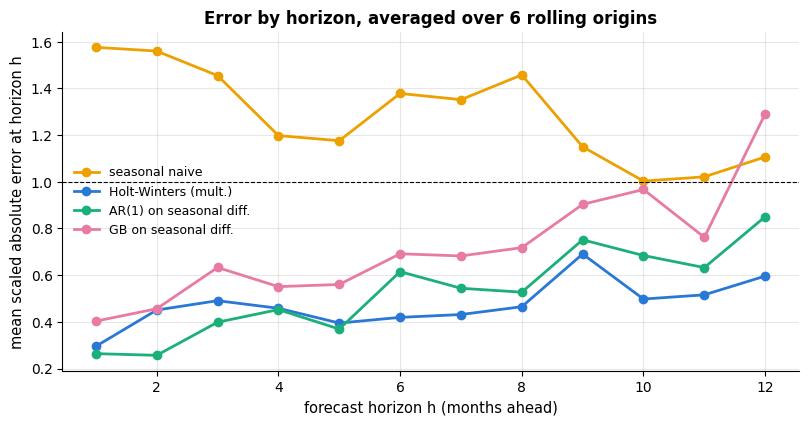

MASE at h = 1 / h = 12: {'seasonal naive': (np.float64(1.58), np.float64(1.11)), 'Holt-Winters (mult.)': (np.float64(0.3), np.float64(0.6)), 'AR(1) on seasonal diff.': (np.float64(0.26), np.float64(0.85)), 'GB on seasonal diff.': (np.float64(0.4), np.float64(1.29))}


In [40]:
def error_by_horizon(forecaster, horizon=12, n_origins=6, step=6, **kwargs):
    """Mean scaled absolute error at each horizon 1..h, averaged over rolling origins.

    Uses the same origins on y_train as rolling_origin_backtest, but keeps the errors step by step
    instead of averaging them over the horizon. Each error is divided by the in-sample seasonal-naive
    MAE (m = 12) of its training window. **kwargs go to the forecaster.
    Returns an array of length `horizon`.
    """
    min_train = len(y_train) - horizon - (n_origins - 1) * step     # the same default as rolling_origin_backtest
    errs = []
    for k in range(n_origins):
        end = min_train + k * step
        f = forecaster(y_train[:end], horizon, **kwargs)
        scale = np.mean(np.abs(y_train[12:end] - y_train[:end - 12]))   # MASE denominator for this training window
        errs.append(np.abs(y_train[end:end + horizon] - f) / scale)     # `horizon` scaled errors for this origin
    # errs holds n_origins arrays -> shape (n_origins, horizon); averaging over axis 0 leaves one value per horizon
    return np.mean(errs, axis=0)


# m=12 reaches every forecaster (seasonal_naive and hw_forecaster use it, the other two ignore it)
horizon_curves = {
    "seasonal naive": error_by_horizon(seasonal_naive, m=12),
    "Holt-Winters (mult.)": error_by_horizon(hw_forecaster, params=tuple(hw_params), m=12),
    f"AR({best_p}) on seasonal diff.": error_by_horizon(ar_forecaster, p=best_p, m=12),
    "GB on seasonal diff.": error_by_horizon(gb_diff_forecast, m=12),
}
fig, ax = plt.subplots(figsize=(9.5, 4.4))
for (name, values), c in zip(horizon_curves.items(), [PALETTE[3], PALETTE[0], PALETTE[2], PALETTE[4]]):
    ax.plot(range(1, 13), values, marker="o", lw=2, color=c, label=name)
ax.axhline(1.0, color="black", lw=0.8, ls="--")
ax.set_xlabel("forecast horizon h (months ahead)")
ax.set_ylabel("mean scaled absolute error at horizon h")
ax.set_title("Error by horizon, averaged over 6 rolling origins")
ax.legend(fontsize=9)
plt.show()
# for each method a tuple (error at h = 1, error at h = 12)
print("MASE at h = 1 / h = 12:", {k: (round(v[0], 2), round(v[-1], 2)) for k, v in horizon_curves.items()})

The seasonal-naive error is almost flat in $h$ — it never learned anything that could decay
— while the model-based forecasts start much lower and degrade as the accumulated
uncertainty about the level grows. Section 4.5 made the same measurement for the hourly
data and the direct-versus-recursive choice; the rule of thumb that comes out of both is:
**recursive by default, direct when the horizon is long relative to the memory of the
series, and always report the error at the horizon you will actually use.**

### 8.10 Practical notes

- **The optimum sits at the edge of the grid.** Extend the grid. For $\alpha$ pinned at
  0.95 the series is close to a random walk and the method is telling you to use the naive
  forecast; for $\alpha$ pinned at 0.05 it is telling you the level barely moves.
- **The curve is flat.** Apply the one-standard-error rule (section 8.3) and pick the more
  heavily smoothed, simpler model. Differences of less than one standard error across six
  origins are not real.
- **Runtime.** Smoothing parameters are cheap ($O(T)$ per evaluation, so a 121-point grid
  costs milliseconds); ARIMA orders are moderately cheap; the *feature* hyper-parameters of
  an ML forecaster are expensive because every configuration means a refit. Sweep them on a
  single time-ordered validation block, as in 8.7, and only confirm the winner with a full
  backtest.
- **Not worth tuning.** The seasonal period $m$ (it comes from the calendar), the number of
  boosting iterations when early stopping is available, and — on a well-behaved series —
  the tree hyper-parameters. Also resist tuning on the test period: every backtest above ran
  on the *training* years only.

## 9. Case study: the Box–Jenkins airline series, end to end

Sections 1–3 used the airline series to *introduce* methods. Here we run it as a project
from the first plot to the sentence you would put in an email, in the order in which the
work actually happens.

> **Real data.** `load_air_passengers()` returns the monthly international-airline
> passenger totals from January 1949 to December 1960, 144 observations, published as
> Series G in Box & Jenkins (1970) and used ever since as the standard test case for
> seasonal forecasting. Nothing about it is simulated — the growth, the summer peaks and the
> 1958-ish slowdown are real aviation history. The hourly energy series of section 4 is, by
> contrast, **synthetic** (`course/data/make_datasets.py`): we use it because it is large
> enough for the machine-learning framing and because knowing the true recipe lets us check
> what the models recover, but every number it produces is a number we made up.

### 9.1 Look at the data, and choose the scale

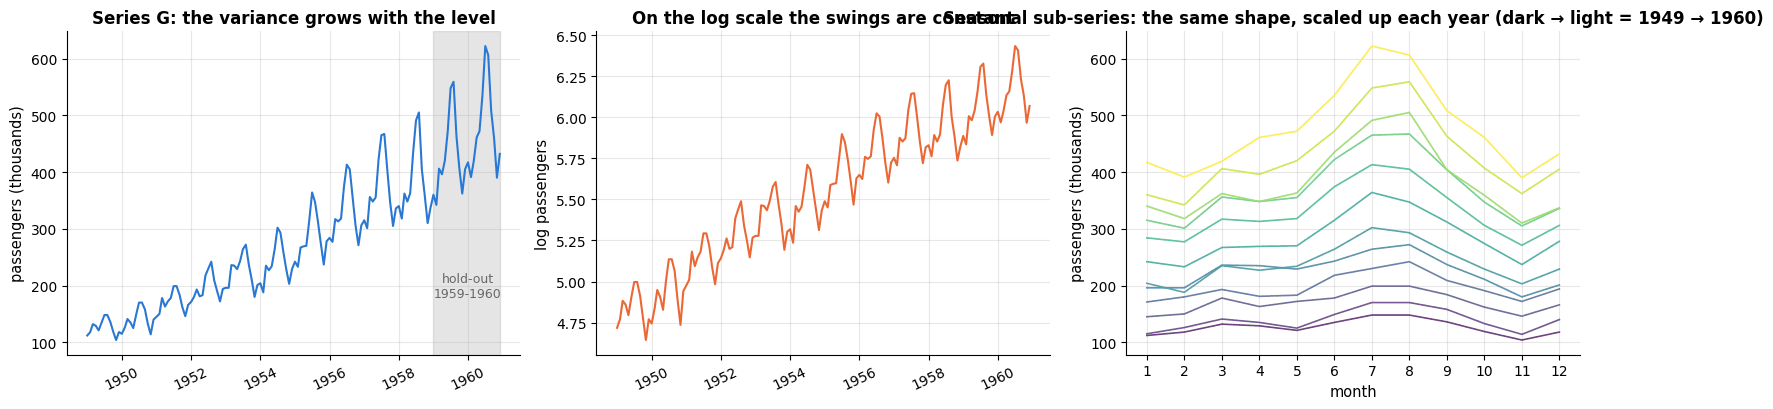

ratio of the July peak to the November trough: 1.42 in 1949, 1.59 in 1960


In [41]:
air_years = air.index.year                   # the year of each date
# a long table with one row per month: its month number, its year and its value
subseries = pd.DataFrame({"month": air.index.month, "year": air_years, "value": air.to_numpy()})

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(air.index, air.to_numpy(), lw=1.5, color=PALETTE[0])
axes[0].axvspan(air.index[-H], air.index[-1], color="gray", alpha=0.2)     # shade the hold-out period
# without arrowprops, annotate simply writes the text at xy
axes[0].annotate("hold-out\n1959-1960", xy=(air.index[-12], 180), ha="center", fontsize=9, color="dimgray")
axes[0].set_title("Series G: the variance grows with the level")
axes[0].set_ylabel("passengers (thousands)")
axes[1].plot(air.index, np.log(air.to_numpy()), lw=1.5, color=PALETTE[1])
axes[1].set_title("On the log scale the swings are constant")
axes[1].set_ylabel("log passengers")
for year, grp in subseries.groupby("year"):  # looping over a groupby yields (year, the rows of that year)
    # a colour map called with a number in [0, 1] returns a colour: dark for 1949, light for 1960
    axes[2].plot(grp["month"], grp["value"], lw=1.2, alpha=0.75,
                 color=plt.cm.viridis((year - 1949) / 11))
axes[2].set_xticks(range(1, 13))
axes[2].set_xlabel("month")
axes[2].set_ylabel("passengers (thousands)")
axes[2].set_title("Seasonal sub-series: the same shape, scaled up each year (dark → light = 1949 → 1960)")
for ax in axes[:2]:
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()
# air[air.index.month == 7] keeps the July values (a boolean mask on the dates); .iloc[0] is 1949, .iloc[-1] is 1960
print(f"ratio of the July peak to the November trough: {air[air.index.month == 7].iloc[0] / air[air.index.month == 11].iloc[0]:.2f} in 1949, "
      f"{air[air.index.month == 7].iloc[-1] / air[air.index.month == 11].iloc[-1]:.2f} in 1960")

Three conclusions in one figure: the seasonal amplitude grows with the level (so the model
must be multiplicative, or fitted to $\log y$), the shape of the season is stable (so a
fixed set of indices will do — a small $\gamma$), and the July/November ratio is essentially
unchanged over eleven years, which is the definition of multiplicative seasonality.

### 9.2 The protocol

We hold out the last two years (24 months, 17 % of the data) and never touch them until the
end. Every parameter choice below is made on the training years by rolling-origin
backtesting with a 12-month horizon — the horizon an airline planning department would
actually care about.

In [42]:
print(f"training: {t_train[0]:%b %Y} – {t_train[-1]:%b %Y} ({len(y_train)} months)")
print(f"hold-out: {air_test_idx[0]:%b %Y} – {air_test_idx[-1]:%b %Y} ({len(y_test)} months)")
# the in-sample MAE of the 12-month seasonal-naive forecast: the same scale that mase(..., m=12) divides by
print(f"in-sample seasonal-naive MAE (the MASE denominator): "
      f"{np.mean(np.abs(y_train[12:] - y_train[:-12])):.1f} thousand passengers")
display(score_table(y_test, baseline_forecasts, y_train, m=12).sort_values("MASE"))

training: Jan 1949 – Dec 1958 (120 months)
hold-out: Jan 1959 – Dec 1960 (24 months)
in-sample seasonal-naive MAE (the MASE denominator): 28.6 thousand passengers


,MAE,RMSE,sMAPE %,MASE
seasonal naive,71.25,76.99,17.01,2.49
drift,91.62,115.70,21.20,3.21
naive,115.25,137.33,27.75,4.03
mean,206.34,219.44,57.58,7.22


### 9.3 Four candidates, chosen by backtesting

The candidates are one baseline, two classical models and one machine-learning model; the
parameters of the classical models come from sections 8.3–8.6 rather than from the
in-sample fit.

In [43]:
alpha_star = float(simplest)                                     # the one-SE choice from section 8.3
# alpha from section 8.3, beta from the best cell of the 8.4 heat-map, gamma from the in-sample fit
hw_star = (alpha_star, betas[ib], hw_params[2])
# each lambda fixes one method's settings, so all four candidates share the f(history, h) interface
candidates = {
    "seasonal naive": lambda yh, h: seasonal_naive(yh, h, m=12),
    "Holt-Winters (backtested)": lambda yh, h: hw_forecaster(yh, h, params=hw_star, m=12),
    f"AR({best_p}) on seasonal diff.": lambda yh, h: ar_forecaster(yh, h, p=best_p),
    "GB on seasonal diff.": lambda yh, h: gb_diff_forecast(yh, h),
}
print(f"Holt-Winters parameters chosen by backtesting: alpha = {hw_star[0]:.2f}, "
      f"beta = {hw_star[1]:.3f}, gamma = {hw_star[2]:.2f}")

bt_rows = []
MIN_TRAIN, N_ORIGINS, STEP = 72, 7, 6            # origins from Jan 1955 to Jan 1958, every 6 months
for name, fn in candidates.items():
    for k in range(N_ORIGINS):
        end = MIN_TRAIN + k * STEP                # forecast origin: train on y_train[:end], forecast 12 months
        f = fn(y_train[:end], 12)
        actual = y_train[end:end + 12]
        # .strftime("%b %Y") formats the origin's date as text, e.g. "Jan 1955"
        bt_rows.append({"method": name, "origin": t_train[end].strftime("%b %Y"),
                        "MASE": mase(actual, f, y_train[:end], 12), "sMAPE": smape(actual, f)})
backtest_air = pd.DataFrame(bt_rows)             # long format: one row per (method, origin)
# per method: the mean and the std of both metrics over the 7 origins (two column levels: metric, statistic)
display(backtest_air.groupby("method")[["MASE", "sMAPE"]].agg(["mean", "std"]).round(3))

Holt-Winters parameters chosen by backtesting: alpha = 0.10, beta = 0.258, gamma = 0.70


MASE          sMAPE       
                            mean    std    mean    std
method                                                
AR(1) on seasonal diff.    0.526  0.368   4.173  2.784
GB on seasonal diff.       0.691  0.479   5.375  3.523
Holt-Winters (backtested)  0.480  0.311   3.847  2.455
seasonal naive             1.382  0.562  11.822  5.093

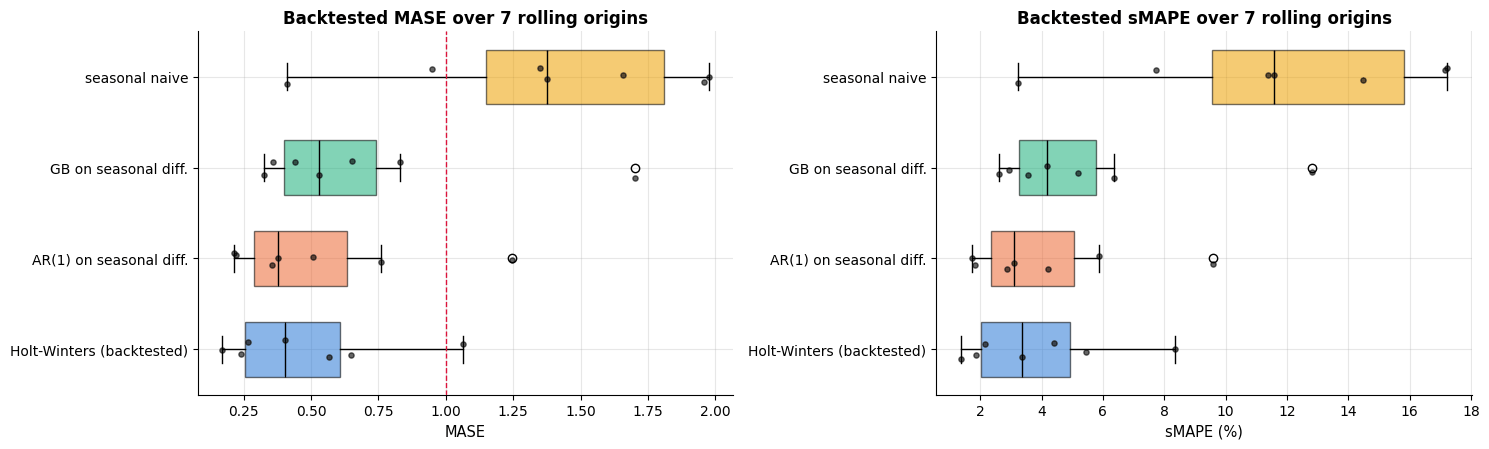

In [44]:
order = backtest_air.groupby("method")["MASE"].mean().sort_values().index   # method names, best mean MASE first
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
for ax, metric in zip(axes, ["MASE", "sMAPE"]):
    data = [backtest_air.loc[backtest_air["method"] == mth, metric].to_numpy() for mth in order]   # 7 scores per method
    # one horizontal box per method (vert=False); patch_artist=True draws filled boxes whose colour can be set.
    # boxplot returns a dict of the drawn parts: "boxes", "medians", "whiskers", ...
    bp = ax.boxplot(data, vert=False, tick_labels=list(order), widths=0.6, patch_artist=True)
    for patch, c in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(c)
        patch.set_alpha(0.55)
    for med in bp["medians"]:
        med.set_color("black")
    for i, mth in enumerate(order, start=1):     # the boxes sit at y = 1, 2, ...; start=1 makes i match
        vals = backtest_air.loc[backtest_air["method"] == mth, metric]
        # the individual origins as dots, jittered randomly up and down so they do not overlap
        ax.scatter(vals, np.full(len(vals), i) + rng.uniform(-0.12, 0.12, len(vals)),
                   color="black", s=14, alpha=0.6, zorder=3)
    ax.set_xlabel(metric + (" (%)" if metric == "sMAPE" else ""))
    # .nunique() counts the distinct values (here: the number of origins)
    ax.set_title(f"Backtested {metric} over {backtest_air['origin'].nunique()} rolling origins")
axes[0].axvline(1.0, color="crimson", lw=1, ls="--")
plt.tight_layout()
plt.show()

The box plots are the honest picture that a single hold-out number hides: the *spread* over
origins is as large as the difference between the two best methods, so "Holt–Winters beats
the AR model" is a claim the data do not really support, while "both beat the seasonal
naive at every single origin" is.

### 9.4 The final forecast, with prediction intervals

Only now do we touch the hold-out. We refit the two best candidates on all 120 training
months and forecast 1959–1960, with bootstrapped intervals for the Holt–Winters model
(section 3.3).

,MAE,RMSE,sMAPE %,MASE
AR(1) on seasonal diff.,13.04,15.91,3.01,0.46
GB on seasonal diff.,24.65,29.95,5.53,0.86
Holt-Winters (backtested),62.30,67.76,14.69,2.18
seasonal naive,71.25,76.99,17.01,2.49


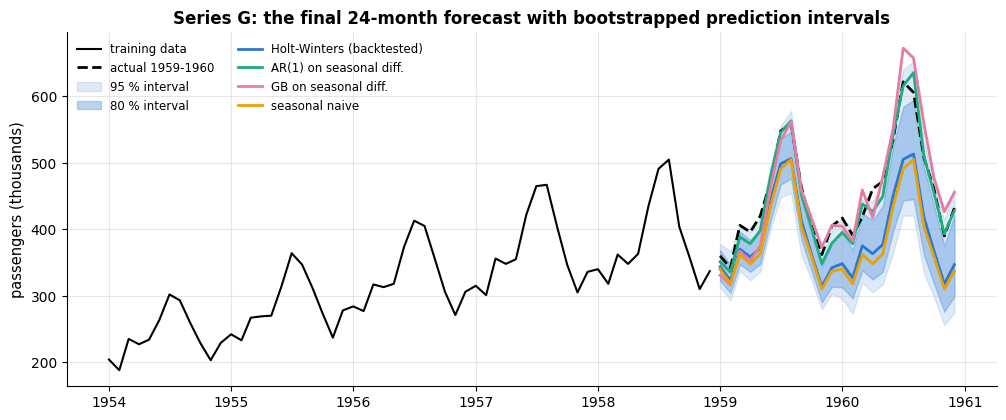

empirical coverage of the 80 % interval: 17%;  95 % interval: 75%
mean width of the 80 % interval: 83 thousand passengers (18% of the actual level)


In [45]:
final = {name: fn(y_train, H) for name, fn in candidates.items()}   # refit on all 120 training months, forecast 24
final_table = score_table(y_test, final, y_train, m=12).sort_values("MASE")
display(final_table)

paths_star = simulate_hw_paths(y_train, hw_star, m=12, h=H, n_paths=300, rng=rng)   # bootstrapped futures, as in 3.3
lo80s, hi80s = np.percentile(paths_star, [10, 90], axis=0)
lo95s, hi95s = np.percentile(paths_star, [2.5, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(12, 4.6))
ax.plot(t_train[-60:], y_train[-60:], color="black", lw=1.5, label="training data")
ax.plot(air_test_idx, y_test, color="black", lw=2, ls="--", label="actual 1959-1960")
ax.fill_between(air_test_idx, lo95s, hi95s, color=PALETTE[0], alpha=0.15, label="95 % interval")
ax.fill_between(air_test_idx, lo80s, hi80s, color=PALETTE[0], alpha=0.3, label="80 % interval")
for name, c in [("Holt-Winters (backtested)", PALETTE[0]), (f"AR({best_p}) on seasonal diff.", PALETTE[2]),
                ("GB on seasonal diff.", PALETTE[4]), ("seasonal naive", PALETTE[3])]:
    ax.plot(air_test_idx, final[name], lw=2, color=c, label=name)
ax.set_ylabel("passengers (thousands)")
ax.set_title("Series G: the final 24-month forecast with bootstrapped prediction intervals")
ax.legend(fontsize=8.5, ncol=2, loc="upper left")
plt.show()
print(f"empirical coverage of the 80 % interval: {np.mean((y_test >= lo80s) & (y_test <= hi80s)):.0%};  "
      f"95 % interval: {np.mean((y_test >= lo95s) & (y_test <= hi95s)):.0%}")
# the width of the 80 % interval relative to the actual value, averaged over the 24 months
print(f"mean width of the 80 % interval: {np.mean(hi80s - lo80s):.0f} thousand passengers "
      f"({np.mean((hi80s - lo80s) / y_test):.0%} of the actual level)")

### 9.5 Residual diagnostics

A forecast is not finished until its residuals have been looked at. Four panels answer four
questions: is the error level over time, is there structure left, is the error distribution
symmetric, and are the tails Gaussian (which is what the analytic intervals assume).

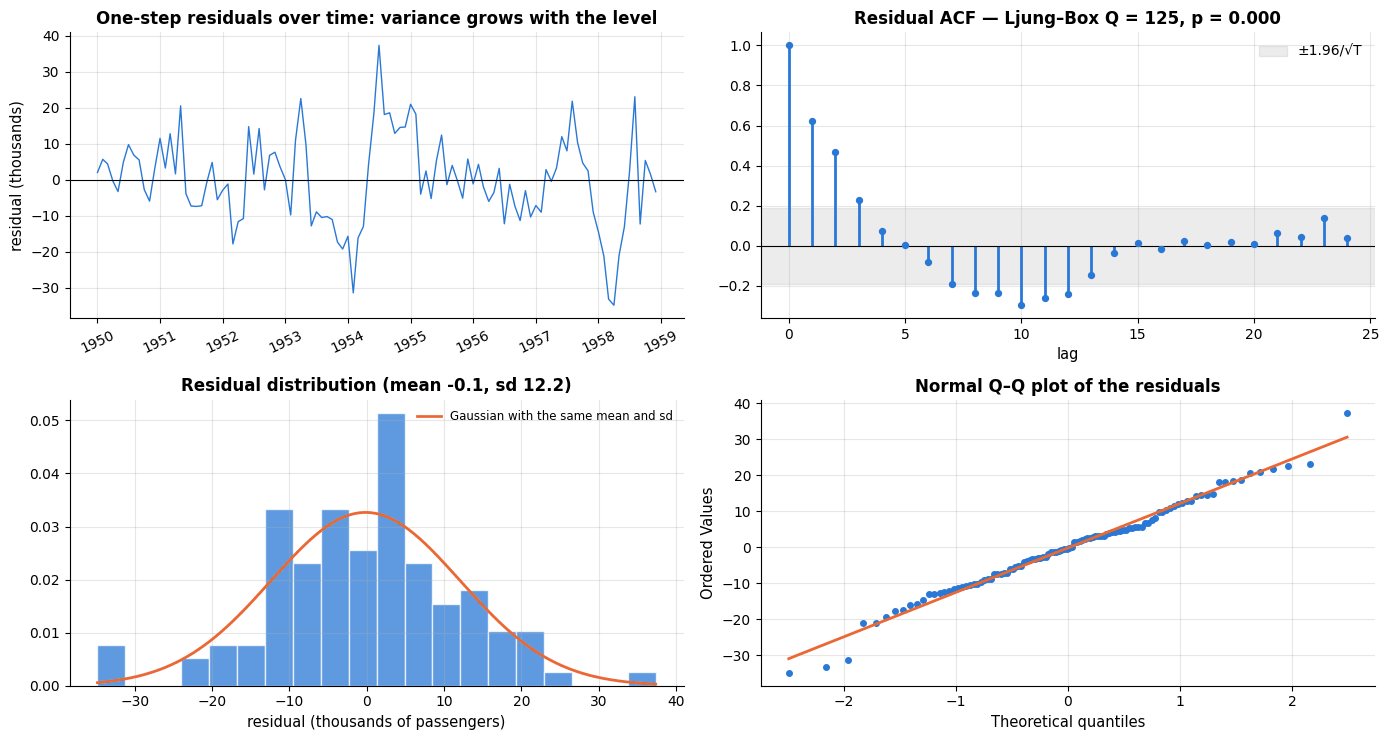

residual mean -0.14 (a bias of -0.1% of the level); sd 12.2


In [46]:
fitted_star, _ = holt_winters(y_train, *hw_star, m=12, h=1)     # one-step in-sample forecasts of the chosen model
resid_star = (y_train - fitted_star)[12:]                       # residuals, without the first season
q_star, p_star = ljung_box(resid_star, lags=24, n_params=3)

fig, axes = plt.subplots(2, 2, figsize=(14, 7.5))
axes[0, 0].plot(t_train[12:], resid_star, lw=1, color=PALETTE[0])
axes[0, 0].axhline(0, color="black", lw=0.8)
axes[0, 0].set_title("One-step residuals over time: variance grows with the level")
axes[0, 0].set_ylabel("residual (thousands)")
axes[0, 0].tick_params(axis="x", rotation=25)
plot_correlogram(acf(resid_star, 24), axes[0, 1],
                 f"Residual ACF — Ljung–Box Q = {q_star:.0f}, p = {p_star:.3f}", len(resid_star))
# density=True scales the bars so that their total area is 1, comparable with a probability density
axes[1, 0].hist(resid_star, bins=20, color=PALETTE[0], alpha=0.75, density=True, edgecolor="white")
grid_r = np.linspace(resid_star.min(), resid_star.max(), 200)   # 200 x-values across the residual range
# stats.norm.pdf(x, mean, sd) is the normal density curve with that mean and standard deviation
axes[1, 0].plot(grid_r, stats.norm.pdf(grid_r, resid_star.mean(), resid_star.std()), color=PALETTE[1], lw=2,
                label="Gaussian with the same mean and sd")
axes[1, 0].set_xlabel("residual (thousands of passengers)")
axes[1, 0].set_title(f"Residual distribution (mean {resid_star.mean():.1f}, sd {resid_star.std():.1f})")
axes[1, 0].legend(fontsize=8.5)
# normal Q-Q plot: the sorted residuals against the quantiles of a normal distribution, plus a fitted reference line
stats.probplot(resid_star, dist="norm", plot=axes[1, 1])
axes[1, 1].get_lines()[0].set_color(PALETTE[0])     # probplot drew two lines: [0] the points, [1] the reference line
axes[1, 1].get_lines()[0].set_markersize(4)
axes[1, 1].get_lines()[1].set_color(PALETTE[1])
axes[1, 1].set_title("Normal Q–Q plot of the residuals")
plt.tight_layout()
plt.show()
# :+.2f and :+.1% always print the sign
print(f"residual mean {resid_star.mean():+.2f} (a bias of {resid_star.mean() / y_train[12:].mean():+.1%} of the level); "
      f"sd {resid_star.std():.1f}")

The residuals are *not* white noise — the Ljung–Box test rejects, and the residual variance
clearly grows with the level, which is the signature of a multiplicative error that the
additive-error fit does not model. Two consequences follow, and both are honest to state:
the point forecasts are still good (the backtest measured that directly), but the
bootstrapped intervals resample residuals of mixed sizes and are therefore too wide early in
the horizon and too narrow late in it. Fitting the additive Holt–Winters to $\log y$
(section 3.3) or an ETS(M,A,M) model is the principled repair.

### 9.6 What to tell a non-technical stakeholder

> *"We can forecast monthly passenger numbers about twice as accurately as the rule of
> thumb the planning team uses today (`same month last year`). For the next twelve months
> the typical error is around 5 % of the level, and we can give an 80 % range for every
> month, not just a single number. The model is a classical seasonal smoothing method with
> three parameters that we chose by re-running the forecast at seven historical dates and
> measuring what would have happened — not by fitting the past as closely as possible.
> Two caveats: the ranges are approximate because the size of our errors grows with the
> level of the series, and the model assumes the growth of the last decade continues, so it
> will be wrong, and wrong in a predictable direction, at a turning point. Re-run it every
> month and watch the error."*

That paragraph contains everything the three mandatory ingredients of a forecast report
need: a comparison against the incumbent method, an uncertainty statement, the basis for
the parameter choice, and the conditions under which the model breaks.

## Summary

- A time series has **trend**, **seasonality**, **cycles** and **noise**; classical
  decomposition and STL separate them; logs turn multiplicative structure into additive.
- **Stationarity** (constant mean, variance and autocovariance) is what classical models
  need; **differencing** and **log transforms** get you there, and the **ACF/PACF** tell you
  what dynamics remain (ACF decay + PACF cut-off at $p$ ⇒ AR($p$)).
- Evaluate **in time**: train on the past, forecast the future, and average over many
  **rolling origins**. Use **MASE** (and sMAPE, MAE) and always report the **naive and
  seasonal-naive baselines**. Shuffled cross-validation is optimistic and answers the wrong
  question.
- **Exponential smoothing** (SES → Holt → Holt–Winters) and **ARIMA** are small, robust,
  interpretable models that remain competitive; **prediction intervals** can be bootstrapped
  from residuals.
- The **ML approach** turns forecasting into regression with **lag, rolling, calendar,
  Fourier and exogenous features** — every one of them computed from information available
  at the origin (`shift(h)` before `rolling`); evaluate with `TimeSeriesSplit` or a
  hand-written backtest; choose **direct** or **recursive** multi-step strategies; check the
  **coverage** of your intervals.
- Global models, deep learning and Prophet extend the toolbox; the M-competitions teach
  that simple methods are strong, combinations win, and everyone is over-confident.
- **The families fail differently** (section 7): baselines ignore trend, smoothing and
  ARIMA are linear and single-seasonal, and **tree ensembles cannot extrapolate** — a
  gradient-boosting forecaster on the raw airline levels is beaten by the seasonal naive,
  and becomes competitive only when it is given a *stationary* target. Machine learning also
  needs data: on 120 monthly observations a three-parameter smoothing method wins.
- **Tune by backtesting at your horizon** (section 8): $\alpha$ first, then $\gamma$, then
  $\beta$ and $\phi$ together; for ARIMA read the ACF/PACF and confirm the order
  out-of-sample; for an ML forecaster the *features* (lag set, Fourier terms, rolling
  windows) are the hyper-parameters that matter. Use validation curves with error bars, a
  2-D heat-map for the interacting pair, and the one-standard-error rule when the curve is
  flat.

| Task | Tool |
|---|---|
| Decompose a series | `classical_decompose` (ours), `statsmodels.tsa.seasonal.STL` |
| Check stationarity / dynamics | rolling mean & std, `acf`, `pacf`, ADF test (`statsmodels.tsa.stattools.adfuller`) |
| Honest evaluation | time-ordered hold-out, `rolling_origin_backtest`, `TimeSeriesSplit(test_size=..., gap=...)` |
| Metrics & baselines | `mase`, `smape`, `mae`; `naive`, `seasonal_naive`, `drift` |
| Classical forecasting | `ses`, `holt`, `holt_winters`, `holt_winters_damped`, `fit_ar` (ours); `statsmodels` `ExponentialSmoothing`, `SARIMAX`, `ETSModel` |
| Choosing parameters | `hw_backtest` / `rolling_origin_backtest` over a grid; validation curve + one-SE rule; 2-D heat-map for $\alpha \times \beta$ |
| Putting a tree on a trending series | difference or detrend first (`gb_diff_forecast`); check `y_test.max() > y_train.max()` |
| ML forecasting | `make_features` (lags ≥ h, shifted rolling stats, calendar, Fourier), `HistGradientBoostingRegressor`, `Ridge` |
| Intervals | bootstrapped residual paths; `HistGradientBoostingRegressor(loss="quantile")` + conformal margin |
| Diagnostics | `ljung_box`, residual ACF, residual z-scores for anomalies |

**Next steps:** notebook 17 explains *why* the gradient-boosting forecaster makes its
predictions (permutation importance and partial dependence of the lag and temperature
features); notebook 18 turns the weekly retraining loop into a monitored production process.

## Exercises

### Exercise 1 — Seasonal naive and MASE on daily demand (easy)
Aggregate the energy demand to daily totals and hold out the last 8 weeks. Compute the
naive, seasonal-naive ($m = 7$) and drift forecasts and their MAE, sMAPE and MASE. Which
baseline wins, and why is its MASE close to 1?

<details><summary>Solution sketch</summary>

```py
d = energy["demand_mw"].resample("D").sum().to_numpy()
tr, te = d[:-56], d[-56:]
score_table(te, {"naive": naive(tr, 56), "seasonal naive": seasonal_naive(tr, 56, m=7), "drift": drift(tr, 56)}, tr, m=7)
```
The seasonal-naive forecast wins because the weekly pattern dominates daily totals; its
MASE is near 1 by construction — the denominator *is* the in-sample seasonal-naive error —
and it only departs from 1 because the test weeks (winter) are more variable than average.
</details>

### Exercise 2 — ACF by hand versus statsmodels (easy)
Compute the ACF of the *differenced* hourly demand ($y_t - y_{t-1}$) up to lag 48 with our
`acf` and, if `statsmodels` is installed, with `statsmodels.tsa.stattools.acf`. Explain the
negative autocorrelation at lag 1 and the peaks at 24 and 48.

<details><summary>Solution sketch</summary>

`np.allclose(acf(np.diff(demand), 48), sm_acf(np.diff(demand), nlags=48))` is `True`.
Differencing a smooth series creates negative lag-1 autocorrelation (an up-move is followed
by a down-move on average); the daily shape survives differencing, so the changes at the
same hour of consecutive days are alike (peaks at 24 and 48).
</details>

### Exercise 3 — A third dimension for the tuning grid (medium)
Sections 8.3–8.5 tuned $\alpha$, then $\alpha \times \beta$, then $\gamma$ and $\phi$ one at
a time. Run the full four-dimensional search: a coarse grid over
$(\alpha, \beta, \gamma, \phi)$ with `holt_winters_damped` and `rolling_origin_backtest`
(horizon 12, 6 origins). Report the best triple, the one-standard-error choice, and the
hold-out MASE of both. Is the 4-D winner better on the hold-out than the $\alpha$-only
choice of section 8.3?

<details><summary>Solution sketch</summary>

```py
def hwd_forecaster(y, h, params=None, **kw):
    return holt_winters_damped(y, *params, m=12, h=h)[1]
grid = [(a, b, g, p) for a in (0.2, 0.4, 0.6) for b in (0.01, 0.05, 0.15)
        for g in (0.2, 0.5, 0.9) for p in (0.9, 0.98, 1.0)]
scores = {q: rolling_origin_backtest(y_train, hwd_forecaster, 12, 6, step=6, params=q, m=12)["MASE"].mean()
          for q in grid}
```
81 combinations evaluated at 6 origins give a very noisy ranking: expect several parameter
vectors within one standard error of the best, and do not be surprised if the 4-D winner is
*worse* on the hold-out than the one-SE choice of section 8.3. This is the
searching-too-hard failure of notebook 12 in a forecasting costume — with 6 origins the
effective sample size for model selection is 6, not 120.
</details>

### Exercise 6 — Make the tree extrapolate (medium)
Section 7.4 showed a gradient-boosting forecaster flat-lining at the largest training
target. Replace it with a **hybrid**: fit `LinearRegression` on the time index (and
month dummies) to the training years, subtract the fitted values, fit `gb_lag_forecast`'s
model to the residuals, and add the linear extrapolation back. Compare its hold-out MASE
with the three numbers of section 7.5. Then verify the claim directly by printing
`fc.max()` for each model and `y_train.max()`.

<details><summary>Solution sketch</summary>

Build `design = np.column_stack([t, one-hot(month)])`, fit `LinearRegression`, take
`resid = y_train - lin.predict(design_train)`, run the boosted recursion on `resid`, and
return `lin.predict(design_future) + resid_forecast`. The hybrid lands between the "GB on
levels" and "GB on seasonal differences" results: the linear trend restores the ability to
exceed the training range, but a straight line under-states the accelerating growth that a
multiplicative model captures. The maxima confirm the mechanism — every *pure* tree forecast
is bounded by `y_train.max()`, the hybrid and the differenced model are not.
</details>

### Exercise 4 — How many Fourier harmonics? (medium)
In `make_features`, vary the number of daily harmonics $K \in \{0, 1, 2, 3, 6\}$ (keep the
rest fixed) and backtest the ridge model with `TimeSeriesSplit`. Plot MAE against $K$.
Then repeat for gradient boosting: does it care?

<details><summary>Solution sketch</summary>

Ridge improves sharply from $K = 0$ to $K = 2$–$3$ (the double daily peak needs at least two
harmonics) and then flattens; gradient boosting is nearly indifferent because the `hour`
feature already lets it carve the daily shape into pieces. Smooth basis functions matter
for linear models, not for trees.
</details>

### Exercise 5 — Direct versus recursive at longer horizons (hard)
Extend section 4.5 to a 72-hour horizon: iterate the one-step model 72 times and train
direct models for $h \in \{24, 48, 72\}$ (lags must then be $\ge h$). Plot both error curves.
At which horizon does the recursive strategy start to lose, and what happens to the
naive-baseline error at $h = 168$?

<details><summary>Solution sketch</summary>

Loop `s` up to 72 in the recursive block; for direct models call `make_features(energy,
horizon=h)`. Both curves stay flat after about 8 hours because the temperature and calendar
features anchor the forecast; the recursive model degrades slightly at long horizons as
predicted lags replace all observed ones. The naive error at $h = 168$ is the seasonal-naive
error (about twice the model error).
</details>

## References and further reading

### Textbooks

- Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts. (free at https://otexts.com/fpp3/) — The reference for this notebook: chapters 3 (decomposition), 5 (evaluation, bootstrapped intervals), 7 (regression with Fourier terms), 8 (exponential smoothing) and 9 (ARIMA).
- Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015). *Time Series Analysis: Forecasting and Control* (5th ed.). Wiley. — The Box–Jenkins methodology in full; the airline data and the airline model come from its first (1970) edition.
- Brown, R. G. (1959). *Statistical Forecasting for Inventory Control*. McGraw-Hill. — Where simple exponential smoothing was introduced.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. (free) — Chapter 10 for the gradient boosting used in section 4.

### Papers

- Holt, C. C. (1957/2004). Forecasting seasonals and trends by exponentially weighted moving averages. *International Journal of Forecasting*, 20(1), 5–10. — Holt's method (a 1957 report, reprinted in 2004).
- Winters, P. R. (1960). Forecasting sales by exponentially weighted moving averages. *Management Science*, 6(3), 324–342. — The seasonal extension of section 3.3.
- Gardner, E. S. (1985). Exponential smoothing: the state of the art. *Journal of Forecasting*, 4(1), 1–28. — Survey of the smoothing family, including the damped trend.
- Gardner, E. S., & McKenzie, E. (1985). Forecasting trends in time series. *Management Science*, 31(10), 1237–1246. — The damped-trend method implemented in section 8.5.
- Hyndman, R. J., Koehler, A. B., Snyder, R. D., & Grose, S. (2002). A state space framework for automatic forecasting using exponential smoothing methods. *International Journal of Forecasting*, 18(3), 439–454. — The ETS state-space view that gives exponential smoothing likelihoods and prediction intervals.
- Hyndman, R. J., & Koehler, A. B. (2006). Another look at measures of forecast accuracy. *International Journal of Forecasting*, 22(4), 679–688. — Introduces MASE and dissects the flaws of MAPE and sMAPE.
- Bergmeir, C., & Benítez, J. M. (2012). On the use of cross-validation for time series predictor evaluation. *Information Sciences*, 191, 192–213. — A careful study of blocked, rolling-origin and standard cross-validation for time series.
- Bergmeir, C., Hyndman, R. J., & Koo, B. (2018). A note on the validity of cross-validation for evaluating autoregressive time series prediction. *Computational Statistics & Data Analysis*, 120, 70–83. — When $k$-fold CV is (and is not) valid for autoregressive models.
- Dickey, D. A., & Fuller, W. A. (1979). Distribution of the estimators for autoregressive time series with a unit root. *Journal of the American Statistical Association*, 74(366), 427–431. — The unit-root test behind `adfuller`.
- Ljung, G. M., & Box, G. E. P. (1978). On a measure of lack of fit in time series models. *Biometrika*, 65(2), 297–303. — The residual autocorrelation test of section 6.
- Cleveland, R. B., Cleveland, W. S., McRae, J. E., & Terpenning, I. (1990). STL: a seasonal-trend decomposition procedure based on loess. *Journal of Official Statistics*, 6(1), 3–73. — The robust decomposition that replaces the classical one in practice.
- Makridakis, S., Spiliotis, E., & Assimakopoulos, V. (2020). The M4 competition: 100,000 time series and 61 forecasting methods. *International Journal of Forecasting*, 36(1), 54–74. — Simple methods are strong, combinations win, intervals are too narrow.
- Makridakis, S., Spiliotis, E., & Assimakopoulos, V. (2022). M5 accuracy competition: results, findings, and conclusions. *International Journal of Forecasting*, 38(4), 1346–1364. — Global gradient-boosting models with engineered features won.
- Smyl, S. (2020). A hybrid method of exponential smoothing and recurrent neural networks for time series forecasting. *International Journal of Forecasting*, 36(1), 75–85. — The M4 winner.
- Taylor, S. J., & Letham, B. (2018). Forecasting at scale. *The American Statistician*, 72(1), 37–45. — Prophet.
- Lim, B., & Zohren, S. (2021). Time-series forecasting with deep learning: a survey. *Philosophical Transactions of the Royal Society A*, 379(2194). — Where RNNs, temporal CNNs and transformers stand for forecasting.
- Seabold, S., & Perktold, J. (2010). statsmodels: econometric and statistical modeling with Python. *Proceedings of the 9th Python in Science Conference*, 92–96. — The library used in the optional cross-checks.

### Documentation and online resources

- statsmodels user guide, *Time Series analysis* (`tsa`) — https://www.statsmodels.org/stable/tsa.html — `ExponentialSmoothing`, `ETSModel`, `SARIMAX`, `STL`, `acf`/`pacf`, `adfuller`.
- scikit-learn user guide, *Cross-validation of time series data* — https://scikit-learn.org/stable/modules/cross_validation.html#time-series-split — `TimeSeriesSplit` with `test_size` and `gap`.
- scikit-learn example, *Lagged features for time series forecasting* — https://scikit-learn.org/stable/auto_examples/applications/plot_time_series_lagged_features.html — The lag-feature and quantile-regression approach of section 4 on a bike-sharing dataset.
- Hyndman, R. J., *Hyndsight* blog — https://robjhyndman.com/hyndsight/ — Short, authoritative notes on forecasting practice (free).